# Notebook 10 - Event Frequency and Schedule Robustness

This foundation constructs and validates dense periodic, sparse periodic, and sparse irregular event calendars under the frozen n=1 benchmark. It does not yet run GC, TDMI, profile estimation, forecasting, calibration, or repeated-seed inference.

## 1. Scope and scientific question

The eventual question is whether methods identify a genuine event response or partly exploit a dense deterministic calendar. This first stage changes only the event schedule while holding the frozen stochastic-volatility model and within-event response mechanism fixed. Timing remains $E_i\longrightarrow\omega_{i+1}\longrightarrow X_{i+1}$, with ages $0,\ldots,12$ aligned to state lags $+1,\ldots,+13$.

## 2. Load the frozen workflow

Notebook 06 provides the frozen benchmark simulator and timing interfaces. Helper self-tests are disabled because this notebook only consumes the existing implementation.

In [1]:
RUN_HELPER_SELF_TESTS=False
%run "./06_experiment_workflow_helpers.ipynb"

import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

required_objects=['reference_config','make_case_config','derive_timing','make_shock_bank','simulate_case','build_transition_table','create_chronological_split','periodic_event_times']
for name in required_objects: assert name in globals() and callable(globals()[name]) if name!='reference_config' else name in globals()
print('Frozen workflow helpers loaded.')

Helper self-tests skipped for downstream use.
Frozen workflow helpers loaded.


## 3. Frozen benchmark and schedule constants

The dense n=1 benchmark is copied unchanged. Step counts are converted to years only through the inherited 252 trading steps per year, so the calendar design contains no unexplained timing fractions.

In [2]:
dense_periodic_case = make_case_config(reference_config, label="dense_periodic")
dense_periodic_snapshot = copy.deepcopy(dense_periodic_case)
dense_timing = derive_timing(dense_periodic_case)

DENSE_PERIOD_STEPS = 21
SPARSE_PERIOD_STEPS = 42
FIRST_EVENT_STEP = 21
RESPONSE_HORIZON_STEPS = 12
MIN_EVENT_GAP_STEPS = RESPONSE_HORIZON_STEPS + 1
IRREGULAR_JITTER_BOUND_STEPS = 18
EVENT_CALENDAR_SEED = 20260726
SMOKE_SEED = 20260721
EVENT_WEIGHT_TOLERANCE = 1e-12

STEPS_PER_YEAR = dense_timing['steps_per_year']
N_TRANSITIONS = int(dense_periodic_case['simulation']['years'] * STEPS_PER_YEAR)
assert dense_periodic_case['model']['n'] == 1
assert STEPS_PER_YEAR == 252
assert dense_periodic_case['simulation']['years'] == 2
assert N_TRANSITIONS == 504
assert dense_timing['event_period_steps'] == DENSE_PERIOD_STEPS
assert dense_timing['response_horizon_steps'] == RESPONSE_HORIZON_STEPS
assert tuple(dense_timing['event_transition_ages']) == tuple(range(13))
assert not dense_timing['event_responses_overlap']
assert dense_periodic_case == dense_periodic_snapshot

## 4. Construct the three event calendars

The dense calendar uses the inherited periodic interface unchanged. Sparse periodic retains the same first event and uses every second dense event. Sparse irregular begins from sparse anchors and applies seeded interior jitter subject only to calendar constraints; no simulated state or outcome enters its construction.

In [3]:
valid_transition_end_time = (N_TRANSITIONS - 1) / STEPS_PER_YEAR

dense_event_times = periodic_event_times(
    0.0,
    valid_transition_end_time,
    dense_periodic_case['events'],
)
dense_event_steps = np.rint(dense_event_times * STEPS_PER_YEAR).astype(int)

sparse_periodic_case = make_case_config(
    dense_periodic_case,
    {'events.period': SPARSE_PERIOD_STEPS / STEPS_PER_YEAR},
    label='sparse_periodic',
)
sparse_periodic_snapshot = copy.deepcopy(sparse_periodic_case)
sparse_timing = derive_timing(sparse_periodic_case)
assert sparse_periodic_case['events']['first_event_time'] == FIRST_EVENT_STEP / STEPS_PER_YEAR
assert sparse_timing['event_period_steps'] == SPARSE_PERIOD_STEPS

sparse_periodic_times = periodic_event_times(
    0.0,
    valid_transition_end_time,
    sparse_periodic_case['events'],
)
sparse_periodic_steps = np.rint(sparse_periodic_times * STEPS_PER_YEAR).astype(int)
SPARSE_TEST_START_EVENT_STEP = int(sparse_periodic_steps[8])

sparse_irregular_case = make_case_config(sparse_periodic_case, label='sparse_irregular')
sparse_irregular_snapshot = copy.deepcopy(sparse_irregular_case)
assert sparse_irregular_case['events']['period'] == SPARSE_PERIOD_STEPS / STEPS_PER_YEAR
assert sparse_irregular_case['model'] == sparse_periodic_case['model']
assert sparse_irregular_case['events']['amplitude'] == sparse_periodic_case['events']['amplitude']
assert sparse_irregular_case['events']['decay_rate'] == sparse_periodic_case['events']['decay_rate']
assert dense_event_steps.tolist() == list(range(21, 484, 21))
assert len(dense_event_steps) == 23
assert sparse_periodic_steps.tolist() == list(range(21, 484, 42))
assert len(sparse_periodic_steps) == 12
assert set(sparse_periodic_steps).issubset(set(dense_event_steps))
assert dense_periodic_case == dense_periodic_snapshot
assert sparse_periodic_case == sparse_periodic_snapshot
assert sparse_irregular_case == sparse_irregular_snapshot

### Seeded sparse-irregular calendar

The interior sparse anchors are jittered by at most 18 steps. The first and last events remain fixed, gaps remain at least 13 steps, and the deterministic split boundary retains eight training and four test events.

In [4]:
def generate_jittered_event_steps(anchors, seed):
    """Generate a reproducible sparse calendar using timing data only."""
    anchors = np.asarray(anchors, dtype=int)
    rng = np.random.default_rng(seed)
    for attempt in range(10_000):
        candidate = anchors.copy()
        interior_jitter = rng.integers(
            -IRREGULAR_JITTER_BOUND_STEPS,
            IRREGULAR_JITTER_BOUND_STEPS + 1,
            size=len(anchors) - 2,
        )
        candidate[1:-1] += interior_jitter
        gaps = np.diff(candidate)
        has_valid_grid = np.all((candidate >= 0) & (candidate < N_TRANSITIONS))
        retains_sparse_split_counts = (
            (candidate[:8] < SPARSE_TEST_START_EVENT_STEP).all()
            and (candidate[8:] >= SPARSE_TEST_START_EVENT_STEP).all()
        )
        valid = (
            np.all(np.diff(candidate) > 0)
            and has_valid_grid
            and len(candidate) == 12
            and candidate[0] == FIRST_EVENT_STEP
            and candidate[-1] == sparse_periodic_steps[-1]
            and np.all(gaps >= MIN_EVENT_GAP_STEPS)
            and not np.array_equal(candidate, anchors)
            and not np.all(gaps == gaps[0])
            and retains_sparse_split_counts
        )
        if valid:
            return candidate
    raise RuntimeError('No valid sparse-irregular calendar was found within 10,000 jitter draws.')

sparse_irregular_steps = generate_jittered_event_steps(
    sparse_periodic_steps,
    EVENT_CALENDAR_SEED,
)
assert np.array_equal(
    sparse_irregular_steps,
    generate_jittered_event_steps(sparse_periodic_steps, EVENT_CALENDAR_SEED),
)
sparse_irregular_times = sparse_irregular_steps / STEPS_PER_YEAR
assert sparse_irregular_case == sparse_irregular_snapshot

## 5. Validate calendar mechanics

Calendar checks are completed before simulation. Non-overlap is verified directly from realised step gaps for every schedule, including the explicit irregular one.

In [5]:
schedule_records = [
    ('dense_periodic', 'dense periodic', dense_periodic_case, dense_event_steps, dense_event_times, 'not applicable'),
    ('sparse_periodic', 'sparse periodic', sparse_periodic_case, sparse_periodic_steps, sparse_periodic_times, 'not applicable'),
    ('sparse_irregular', 'sparse irregular', sparse_irregular_case, sparse_irregular_steps, sparse_irregular_times, str(EVENT_CALENDAR_SEED)),
]

def schedule_gaps(steps):
    return np.diff(np.asarray(steps, dtype=int))

def windows_do_not_overlap(steps):
    return bool(np.all(schedule_gaps(steps) >= MIN_EVENT_GAP_STEPS))

registry_rows = []
event_rows = []
for case_name, schedule_type, case_config, steps, times, calendar_seed in schedule_records:
    gaps = schedule_gaps(steps)
    registry_rows.append({
        'case_name': case_name,
        'schedule_type': schedule_type,
        'nominal_period_steps': derive_timing(case_config)['event_period_steps'],
        'number_of_events': len(steps),
        'first_event_step': int(steps[0]),
        'last_event_step': int(steps[-1]),
        'minimum_gap_steps': int(gaps.min()),
        'mean_gap_steps': float(gaps.mean()),
        'standard_deviation_gap_steps': float(gaps.std(ddof=1)),
        'response_horizon_steps': RESPONSE_HORIZON_STEPS,
        'overlap_present': not windows_do_not_overlap(steps),
        'calendar_seed': calendar_seed,
    })
    for event_number, (event_step, event_time) in enumerate(zip(steps, times), start=1):
        previous_gap = np.nan if event_number == 1 else int(gaps[event_number - 2])
        event_rows.append({
            'case_name': case_name,
            'event_number': event_number,
            'event_step': int(event_step),
            'event_time': float(event_time),
            'previous_gap_steps': previous_gap,
        })
schedule_registry = pd.DataFrame(registry_rows)
event_calendar_steps = pd.DataFrame(event_rows)
display(schedule_registry)
display(event_calendar_steps)
assert len(dense_event_steps) == 23
assert len(sparse_periodic_steps) == 12
assert len(sparse_irregular_steps) == 12
for steps in [sparse_periodic_steps, sparse_irregular_steps]:
    assert steps[0] == 21 and steps[-1] == 483
    assert np.isclose(schedule_gaps(steps).mean(), 42)
    assert schedule_gaps(steps).min() >= 13
for _, _, _, steps, _, _ in schedule_records:
    assert steps[-1] + RESPONSE_HORIZON_STEPS <= N_TRANSITIONS - 1
    assert windows_do_not_overlap(steps)
assert not schedule_registry.overlap_present.any()

,case_name,schedule_type,nominal_period_steps,number_of_events,first_event_step,last_event_step,minimum_gap_steps,mean_gap_steps,standard_deviation_gap_steps,response_horizon_steps,overlap_present,calendar_seed
0,dense_periodic,dense periodic,21,23,21,483,21,21.0,0.000000,12,False,not applicable
1,sparse_periodic,sparse periodic,42,12,21,483,42,42.0,0.000000,12,False,not applicable
2,sparse_irregular,sparse irregular,42,12,21,483,21,42.0,16.834488,12,False,20260726


,case_name,event_number,event_step,event_time,previous_gap_steps
0,dense_periodic,1,21,0.083333,NaN
1,dense_periodic,2,42,0.166667,21.0
2,dense_periodic,3,63,0.250000,21.0
3,dense_periodic,4,84,0.333333,21.0
4,dense_periodic,5,105,0.416667,21.0
5,dense_periodic,6,126,0.500000,21.0
6,dense_periodic,7,147,0.583333,21.0
7,dense_periodic,8,168,0.666667,21.0
8,dense_periodic,9,189,0.750000,21.0
9,dense_periodic,10,210,0.833333,21.0


## 6. One-seed common-shock simulations

A single market-shock bank is passed unchanged to all three n=1 simulations. Dense and sparse periodic cases use their native periodic schedules; only sparse irregular supplies the validated explicit event-time array.

In [6]:
common_shock_bank=make_shock_bank(dense_periodic_case,seed=SMOKE_SEED)
dense_smoke=simulate_case(dense_periodic_case,shock_bank=common_shock_bank)
sparse_periodic_smoke=simulate_case(sparse_periodic_case,shock_bank=common_shock_bank)
sparse_irregular_smoke=simulate_case(sparse_irregular_case,shock_bank=common_shock_bank,event_schedule=sparse_irregular_times)
smoke_results={'dense_periodic':dense_smoke,'sparse_periodic':sparse_periodic_smoke,'sparse_irregular':sparse_irregular_smoke}
assert dense_periodic_case==dense_periodic_snapshot and sparse_periodic_case==sparse_periodic_snapshot and sparse_irregular_case==sparse_irregular_snapshot

## 7. Validate timing, event weights and common shocks

These checks are simulator mechanics only. Hidden innovations and true event weights are inspected solely to validate common shocks and unchanged response shape; they do not enter any fitted model or forecast.

In [7]:
schedule_steps = {
    'dense_periodic': dense_event_steps,
    'sparse_periodic': sparse_periodic_steps,
    'sparse_irregular': sparse_irregular_steps,
}
schedule_cases = {
    'dense_periodic': dense_periodic_case,
    'sparse_periodic': sparse_periodic_case,
    'sparse_irregular': sparse_irregular_case,
}

def event_age_from_steps(indices, steps):
    ages = np.full(len(indices), -1, dtype=int)
    for event_step in steps:
        in_response_window = (indices >= event_step) & (indices <= event_step + RESPONSE_HORIZON_STEPS)
        ages[in_response_window] = indices[in_response_window] - event_step
    return ages

transition_tables = {}
splits = {}
truth_profiles = {}
simulation_rows = []
benchmark_transitions = dense_smoke['simulation']['transitions']
for name, result in smoke_results.items():
    simulation = result['simulation']
    states = simulation['states']
    tr = simulation['transitions']
    steps = schedule_steps[name]
    config = schedule_cases[name]
    timing = result['timing']

    event_indicator_matches = np.array_equal(tr.loc[tr.event.eq(1), 'i'].to_numpy(), steps)
    all_finite = np.isfinite(states[['S', 'sigma', 'x']].to_numpy()).all() and np.isfinite(tr[['F', 'x_next', 'sigma_next', 'omega_next']].to_numpy()).all()
    all_positive = states[['S', 'sigma', 'x']].gt(0).all().all() and tr[['F', 'x_next', 'sigma_next', 'omega_next']].gt(0).all().all()
    ages = event_age_from_steps(tr.i.to_numpy(dtype=int), steps)
    expected_active = ages >= 0
    actual_active = tr['omega_next'].to_numpy(dtype=float) > 1.0 + EVENT_WEIGHT_TOLERANCE
    active_mask_matches = np.array_equal(actual_active, expected_active)
    inactive_weights_equal_one = np.allclose(tr.loc[~actual_active, 'omega_next'].to_numpy(dtype=float), 1.0, rtol=0.0, atol=EVENT_WEIGHT_TOLERANCE)
    no_overlap = windows_do_not_overlap(steps)

    assert len(tr) == N_TRANSITIONS
    assert all_finite and all_positive and event_indicator_matches
    assert np.array_equal(actual_active, expected_active)
    assert actual_active.sum() == 13 * len(steps)
    assert inactive_weights_equal_one
    assert np.allclose(states.x, states.sigma, rtol=0.0, atol=1e-12)

    table, features = build_transition_table(simulation, config, timing)
    transition_tables[name] = table
    split = create_chronological_split(table, timing)
    splits[name] = split
    all_ages_present = table.event_active_i.max() <= 1 and set(table.loc[table.event_active_i.eq(1), 'event_age_i']) == set(range(13))
    assert all_ages_present

    expected_omega = 1 + config['events']['amplitude'] * np.exp(-config['events']['decay_rate'] * ages[actual_active] / STEPS_PER_YEAR)
    assert np.allclose(tr.loc[actual_active, 'omega_next'].to_numpy(dtype=float), expected_omega, rtol=0.0, atol=1e-12)
    truth_profiles[name] = pd.DataFrame({'event_age': ages[actual_active], 'omega': tr.loc[actual_active, 'omega_next'].to_numpy(dtype=float)}).groupby('event_age').omega.mean().reindex(range(13))
    common_epsilon = np.array_equal(tr.epsilon.to_numpy(), benchmark_transitions.epsilon.to_numpy())
    common_eta = np.array_equal(tr.eta.to_numpy(), benchmark_transitions.eta.to_numpy())
    assert common_epsilon and common_eta and no_overlap

    gaps = schedule_gaps(steps)
    active_weights = tr.loc[actual_active, 'omega_next']
    simulation_rows.append({
        'case_name': name,
        'simulation_success': all_finite and all_positive and event_indicator_matches and active_mask_matches and inactive_weights_equal_one,
        'number_of_events': int(tr.event.sum()),
        'active_transition_count': int(actual_active.sum()),
        'train_event_count': int(split['train'].event_lag_0.sum()),
        'test_event_count': int(split['test'].event_lag_0.sum()),
        'minimum_sigma': states.sigma.min(),
        'maximum_sigma': states.sigma.max(),
        'minimum_F': tr.F.min(),
        'minimum_omega': active_weights.min(),
        'maximum_omega': active_weights.max(),
        'minimum_event_gap': int(gaps.min()),
        'mean_event_gap': float(gaps.mean()),
        'all_finite': all_finite,
        'all_positive': all_positive,
        'common_epsilon': common_epsilon,
        'common_eta': common_eta,
        'all_ages_present': all_ages_present,
        'no_overlap': no_overlap,
        'event_indicator_matches': event_indicator_matches,
        'active_mask_matches': active_mask_matches,
        'inactive_weights_equal_one': inactive_weights_equal_one,
    })

summary_index = {row['case_name']: row for row in simulation_rows}
assert summary_index['sparse_periodic']['train_event_count'] == 8
assert summary_index['sparse_irregular']['train_event_count'] == 8
assert summary_index['sparse_periodic']['test_event_count'] == 4
assert summary_index['sparse_irregular']['test_event_count'] == 4
for column in ['epsilon', 'eta', 'i', 'target_i', 'dt']:
    assert all(np.array_equal(result['simulation']['transitions'][column].to_numpy(), benchmark_transitions[column].to_numpy()) for result in smoke_results.values())
for profile in truth_profiles.values():
    assert np.allclose(profile.to_numpy(), truth_profiles['dense_periodic'].to_numpy(), rtol=0.0, atol=1e-12)
smoke_test_summary = pd.DataFrame(simulation_rows)
assert smoke_test_summary.simulation_success.all()
assert smoke_test_summary.common_epsilon.all()
assert smoke_test_summary.common_eta.all()
assert smoke_test_summary.all_ages_present.all()
assert smoke_test_summary.no_overlap.all()
assert smoke_test_summary.active_mask_matches.all()
assert smoke_test_summary.inactive_weights_equal_one.all()
assert smoke_test_summary.set_index('case_name').active_transition_count.to_dict() == {'dense_periodic':299, 'sparse_periodic':156, 'sparse_irregular':156}

## 8. Compact smoke-test tables and figures

Only compact schedule and simulation-validation outputs are retained. The checkpoint contains the schedule registry, event calendar steps, and smoke-test summary; complete simulations, state paths, and hidden shocks remain in memory only for this smoke test.

,case_name,simulation_success,number_of_events,active_transition_count,train_event_count,test_event_count,minimum_sigma,maximum_sigma,minimum_F,minimum_omega,...,mean_event_gap,all_finite,all_positive,common_epsilon,common_eta,all_ages_present,no_overlap,event_indicator_matches,active_mask_matches,inactive_weights_equal_one
0,dense_periodic,True,23,299,16,7,0.1941,0.263888,0.1941,1.001889,...,21.0,True,True,True,True,True,True,True,True,True
1,sparse_periodic,True,12,156,8,4,0.1941,0.231727,0.1941,1.001889,...,42.0,True,True,True,True,True,True,True,True,True
2,sparse_irregular,True,12,156,8,4,0.1941,0.232147,0.1941,1.001889,...,42.0,True,True,True,True,True,True,True,True,True


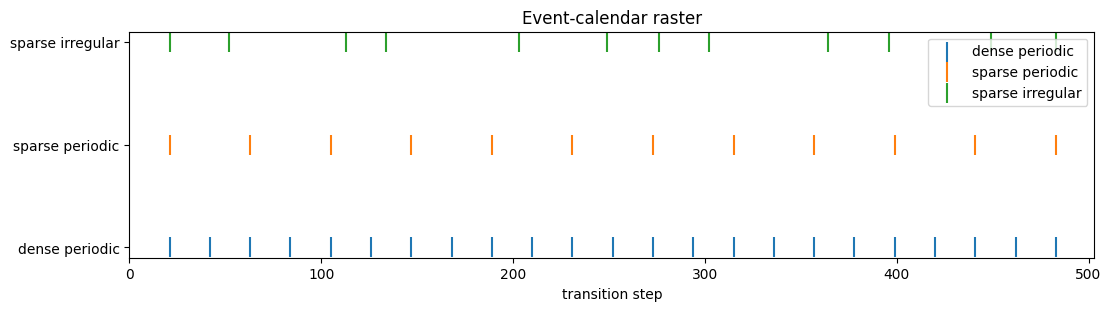

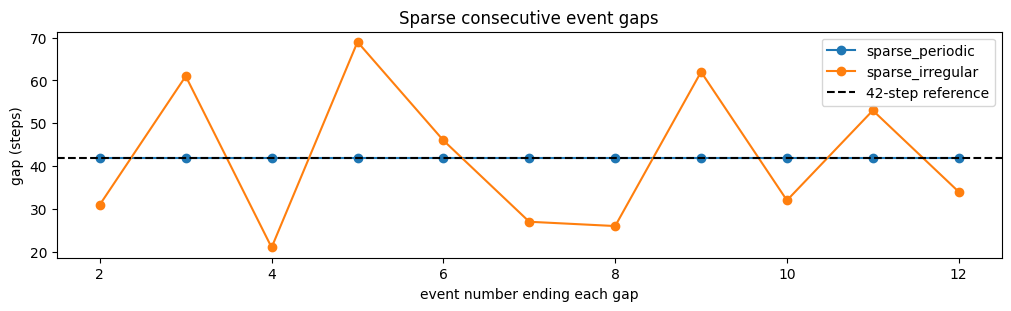

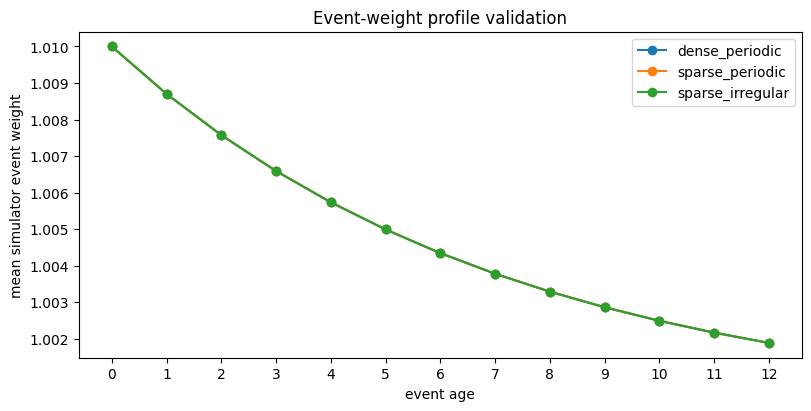

In [8]:
RESULTS_DIR_10 = 'notebook10_results'
from pathlib import Path

results_dir_10 = Path(RESULTS_DIR_10)
results_dir_10.mkdir(exist_ok=True)
schedule_registry.to_csv(results_dir_10 / 'schedule_registry.csv', index=False)
event_calendar_steps.to_csv(results_dir_10 / 'event_calendar_steps.csv', index=False)
smoke_test_summary.to_csv(results_dir_10 / 'smoke_test_summary.csv', index=False)
display(smoke_test_summary)

fig, ax = plt.subplots(figsize=(11, 3), constrained_layout=True)
for row, (_, schedule_type, _, steps, _, _) in enumerate(schedule_records):
    ax.scatter(steps, np.full(len(steps), row), marker='|', s=220, label=schedule_type)
ax.set(yticks=range(3), yticklabels=[record[1] for record in schedule_records], xlabel='transition step', title='Event-calendar raster', xlim=(0, N_TRANSITIONS - 1))
ax.legend(loc='upper right')
plt.show()

fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)
for name, steps, color in [('sparse_periodic', sparse_periodic_steps, 'tab:blue'), ('sparse_irregular', sparse_irregular_steps, 'tab:orange')]:
    ax.plot(np.arange(2, len(steps) + 1), schedule_gaps(steps), marker='o', label=name, color=color)
ax.axhline(SPARSE_PERIOD_STEPS, color='black', linestyle='--', label='42-step reference')
ax.set(xlabel='event number ending each gap', ylabel='gap (steps)', title='Sparse consecutive event gaps')
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
for name, profile in truth_profiles.items():
    ax.plot(profile.index, profile.to_numpy(), marker='o', label=name)
ax.set(xlabel='event age', ylabel='mean simulator event weight', title='Event-weight profile validation', xticks=range(13))
ax.legend()
plt.show()

## 9. First-stage findings

The dense benchmark calendar is reproduced unchanged. Sparse periodic uses every second dense event, while seeded sparse irregular preserves 12 events, the same endpoints and mean 42-step frequency, but breaks exact periodicity. Direct gap checks confirm that response windows do not overlap. All three schedules use the same market shocks, and the simulator realised active-weight mask exactly matches the calendar-implied response windows while retaining the identical within-event weight shape, and the sparse cases retain eight train and four test age-zero events. The frozen simulator accepts the explicit irregular schedule correctly.

This stage records schedule mechanics only; the later checkpoint analyses provide the predictive, recovery, forecasting, and calibration evidence.

## 10. Stage 2 scope: schedule-aware full-pipeline prototype

This one-seed prototype applies the complete frozen Notebook 06 workflow to the validated dense-periodic, sparse-periodic and sparse-irregular calendars. The local adapter differs from `run_full_pipeline` only by passing an explicit event schedule into the inherited `simulate_case` helper. It is an implementation and information-set check, not Monte Carlo evidence or a final schedule comparison.

In [9]:
required_stage1_objects = [
    'dense_periodic_case', 'sparse_periodic_case', 'sparse_irregular_case',
    'dense_event_steps', 'sparse_periodic_steps', 'sparse_irregular_steps',
    'dense_event_times', 'sparse_periodic_times', 'sparse_irregular_times',
    'schedule_cases', 'schedule_steps', 'schedule_registry',
    'event_calendar_steps', 'results_dir_10',
]
missing_stage1_objects = [name for name in required_stage1_objects if name not in globals()]
assert not missing_stage1_objects, f'Missing Stage 1 objects: {missing_stage1_objects}'

PROTOTYPE_MARKET_SEED = 20260722
prototype_shock_bank = make_shock_bank(dense_periodic_case, seed=PROTOTYPE_MARKET_SEED)
assert prototype_shock_bank is not common_shock_bank
assert dense_periodic_case == dense_periodic_snapshot
print('Stage 2 uses one common prototype shock bank and the frozen Stage 1 calendars.')

Stage 2 uses one common prototype shock bank and the frozen Stage 1 calendars.


## 11. Local schedule-aware pipeline adapter

The adapter reproduces the frozen orchestration step for step. It derives timing once and calls inherited functions unchanged; the sole methodological addition is the explicit `event_schedule` argument passed to `simulate_case`. Truth is constructed only after fitted forecasts and implementable intervals have been frozen.

In [10]:
def run_schedule_aware_pipeline(
    case_config,
    event_schedule=None,
    shock_bank=None,
    seed=None,
    baseline_feature_builder=None,
    include_causality=True,
    include_intervals=True,
    include_truth=False,
    functions=None,
):
    """Notebook 10 adapter: frozen workflow orchestration with an explicit event schedule."""
    timing = derive_timing(case_config)
    simpack = simulate_case(
        case_config,
        shock_bank,
        seed,
        functions=functions,
        event_schedule=event_schedule,
        _timing=timing,
    )
    simulation = simpack['simulation']
    transition_table, event_features = build_transition_table(simulation, case_config, timing)
    split = create_chronological_split(transition_table, timing)
    feature_builder = baseline_feature_builder or build_baseline_features
    baseline = fit_event_free_baseline(split['train'], case_config, feature_builder)
    profiles = estimate_event_profiles(split['train'], baseline, case_config, timing, feature_builder)
    forecast_inputs = split['test'].drop(
        columns=['state_next', 'sigma_next', 'delta_state_next'], errors='ignore'
    ).copy()
    forecasts = construct_forecasts(split['test'], baseline, profiles, case_config, timing, feature_builder)
    evaluation = evaluate_forecasts(forecasts, split['test'], case_config)
    intervals = (
        construct_prediction_intervals(forecasts, split['test'], baseline, case_config)
        if include_intervals else None
    )
    evaluation['intervals'] = None if intervals is None else intervals['table']
    evaluation['interval_summary'] = None if intervals is None else intervals['summary']

    causality = {
        'gc': pd.DataFrame(), 'conditional_structure': pd.DataFrame(),
        'tdmi_level_curve': pd.DataFrame(), 'tdmi_change_curve': pd.DataFrame(),
        'tdmi_summary': pd.DataFrame(),
    }
    if include_causality:
        lag_grid = range(-timing['event_period_steps'], timing['event_period_steps'] + 1)
        level_curve = compute_tdmi_curve(
            transition_table.event_i, transition_table.state_i, lag_grid,
            source_name='event_i', target_name='state_i',
            alignment='event_i paired with state_i',
        )
        change_curve = compute_tdmi_curve(
            transition_table.event_i.iloc[1:], np.diff(transition_table.state_i.to_numpy()), lag_grid,
            source_name='event_i', target_name='delta_state_i',
            alignment='event_i[1:] paired with diff(state_i), matching Notebook 01 change alignment',
        )
        causality = {
            'gc': run_gc_summary(transition_table, timing),
            'conditional_structure': run_conditional_structure_summary(split['train'], timing),
            'tdmi_level_curve': level_curve,
            'tdmi_change_curve': change_curve,
            'tdmi_summary': compute_tdmi_summary(level_curve, change_curve, timing),
        }

    pipeline_stages = [
        'simulation', 'transition_table', 'split', 'baseline_fit', 'profile_fit',
        'forecasts_frozen', 'implementable_intervals',
    ]
    result = {
        'config': case_config, 'timing': simpack['timing'],
        'function_metadata': simpack['function_metadata'], 'simulation': simulation,
        'transition_table': transition_table, 'event_features': event_features,
        'split': split, 'causality': causality, 'baseline': baseline,
        'profiles': profiles, 'forecast_inputs': forecast_inputs, 'forecasts': forecasts,
        'evaluation': evaluation, 'intervals': intervals, 'truth': None,
        'pipeline_stages': pipeline_stages,
    }
    if include_truth:
        result['truth'] = build_known_dgp_reference(result)
        result['pipeline_stages'].append('known_dgp_synthetic_reference')
    return result

assert 'event_schedule' in inspect.signature(run_schedule_aware_pipeline).parameters
print('Local schedule-aware adapter defined; inherited estimators remain unchanged.')

Local schedule-aware adapter defined; inherited estimators remain unchanged.


## 12. Adapter equivalence against the frozen dense pipeline

Before using the irregular schedule, the adapter is tested against the frozen dense-periodic path using the identical prototype shock bank. Scientifically relevant data frames, numeric fitted quantities and structural metadata are compared at tight tolerances; fitted Python objects themselves are deliberately not compared.

In [11]:
EQUIVALENCE_RTOL = 1e-10
EQUIVALENCE_ATOL = 1e-12

def _maximum_numeric_difference(left, right):
    shared = [c for c in left.columns if c in right.columns and pd.api.types.is_numeric_dtype(left[c]) and pd.api.types.is_numeric_dtype(right[c])]
    if not shared:
        return np.nan
    values = [np.nanmax(np.abs(left[c].to_numpy(dtype=float) - right[c].to_numpy(dtype=float))) for c in shared if len(left)]
    return float(np.nanmax(values)) if values else 0.0

def compare_schedule_adapter(native, adapter):
    rows = []
    def add_exact(component, left, right, note='exact structural comparison'):
        passed = left == right
        rows.append({'component': component, 'comparison_type': 'exact', 'passed': bool(passed), 'maximum_absolute_difference': np.nan, 'note': note})
    def add_frame(component, left, right):
        try:
            pd.testing.assert_frame_equal(left, right, check_exact=False, rtol=EQUIVALENCE_RTOL, atol=EQUIVALENCE_ATOL, check_dtype=True)
            passed, note = True, 'frame equal within tight tolerance'
        except AssertionError as exc:
            passed, note = False, str(exc).splitlines()[0]
        rows.append({'component': component, 'comparison_type': 'frame', 'passed': passed, 'maximum_absolute_difference': _maximum_numeric_difference(left, right), 'note': note})
    def add_numeric(component, left, right):
        maximum = float(np.max(np.abs(np.asarray(left, dtype=float) - np.asarray(right, dtype=float))))
        rows.append({'component': component, 'comparison_type': 'numeric', 'passed': bool(np.allclose(left, right, rtol=EQUIVALENCE_RTOL, atol=EQUIVALENCE_ATOL)), 'maximum_absolute_difference': maximum, 'note': 'allclose at specified tolerance'})

    add_exact('result dictionary keys', set(native), set(adapter))
    add_exact('timing dictionary', native['timing'], adapter['timing'])
    add_exact('function metadata', native['function_metadata'], adapter['function_metadata'])
    add_exact('event feature names', native['event_features'], adapter['event_features'])
    add_exact('pipeline stage sequence', native['pipeline_stages'], adapter['pipeline_stages'])
    for component, left, right in [
        ('simulation states', native['simulation']['states'], adapter['simulation']['states']),
        ('simulation transitions', native['simulation']['transitions'], adapter['simulation']['transitions']),
        ('transition table', native['transition_table'], adapter['transition_table']),
        ('training split', native['split']['train'], adapter['split']['train']),
        ('testing split', native['split']['test'], adapter['split']['test']),
        ('baseline fit-row identifiers', native['baseline']['fit_row_ids'], adapter['baseline']['fit_row_ids']),
        ('profile table', native['profiles']['profile_table'], adapter['profiles']['profile_table']),
        ('parametric profile fit-row identifiers', native['profiles']['parametric_fit_row_ids'], adapter['profiles']['parametric_fit_row_ids']),
        ('non-parametric profile fit-row identifiers', native['profiles']['nonparametric_fit_row_ids'], adapter['profiles']['nonparametric_fit_row_ids']),
        ('forecast inputs', native['forecast_inputs'], adapter['forecast_inputs']),
        ('forecast table', native['forecasts'], adapter['forecasts']),
        ('evaluation table', native['evaluation']['evaluation'], adapter['evaluation']['evaluation']),
        ('accuracy table', native['evaluation']['accuracy'], adapter['evaluation']['accuracy']),
        ('relative-gain table', native['evaluation']['relative_gains'], adapter['evaluation']['relative_gains']),
        ('interval table', native['intervals']['table'], adapter['intervals']['table']),
        ('interval summary', native['intervals']['summary'], adapter['intervals']['summary']),
        ('GC table', native['causality']['gc'], adapter['causality']['gc']),
        ('conditional-structure table', native['causality']['conditional_structure'], adapter['causality']['conditional_structure']),
        ('TDMI level curve', native['causality']['tdmi_level_curve'], adapter['causality']['tdmi_level_curve']),
        ('TDMI change curve', native['causality']['tdmi_change_curve'], adapter['causality']['tdmi_change_curve']),
        ('TDMI summary', native['causality']['tdmi_summary'], adapter['causality']['tdmi_summary']),
        ('Known-DGP reference table', native['truth']['table'], adapter['truth']['table']),
        ('Known-DGP accuracy table', native['truth']['accuracy'], adapter['truth']['accuracy']),
        ('Known-DGP interval summary', native['truth']['interval_summary'], adapter['truth']['interval_summary']),
    ]:
        add_frame(component, left, right)
    add_numeric('baseline fitted parameters', native['baseline']['model'].params, adapter['baseline']['model'].params)
    add_numeric('baseline fitted values', native['baseline']['fitted_values'], adapter['baseline']['fitted_values'])
    add_numeric('baseline residual variance', [native['baseline']['residual_variance']], [adapter['baseline']['residual_variance']])
    add_numeric('A_hat', [native['profiles']['A_hat']], [adapter['profiles']['A_hat']])
    add_numeric('lambda_hat', [native['profiles']['lambda_hat']], [adapter['profiles']['lambda_hat']])
    ages = np.asarray(native['timing']['event_transition_ages'])
    add_numeric('parametric multiplier ages 0-12', native['profiles']['parametric_multiplier'](ages), adapter['profiles']['parametric_multiplier'](ages))
    add_numeric('non-parametric multiplier ages 0-12', native['profiles']['nonparametric'].reindex(ages), adapter['profiles']['nonparametric'].reindex(ages))
    for metric in ['parametric_multiplier', 'nonparametric_multiplier']:
        add_numeric(f'Known-DGP profile metrics: {metric}', list(native['truth']['profile_metrics'][metric].values()), list(adapter['truth']['profile_metrics'][metric].values()))
    add_numeric('split index', [native['split']['split_i']], [adapter['split']['split_i']])
    add_numeric('training active count', [native['split']['train_active']], [adapter['split']['train_active']])
    add_numeric('testing active count', [native['split']['test_active']], [adapter['split']['test_active']])
    return pd.DataFrame(rows)

dense_native_result = run_full_pipeline(dense_periodic_case, shock_bank=prototype_shock_bank, include_causality=True, include_intervals=True, include_truth=True)
dense_adapter_result = run_schedule_aware_pipeline(dense_periodic_case, event_schedule=dense_event_times, shock_bank=prototype_shock_bank, include_causality=True, include_intervals=True, include_truth=True)
adapter_equivalence_summary = compare_schedule_adapter(dense_native_result, dense_adapter_result)
display(adapter_equivalence_summary)
assert adapter_equivalence_summary['passed'].all()
print('Adapter equivalence against the frozen dense-periodic pipeline passed.')

,component,comparison_type,passed,maximum_absolute_difference,note
0,result dictionary keys,exact,True,NaN,exact structural comparison
1,timing dictionary,exact,True,NaN,exact structural comparison
2,function metadata,exact,True,NaN,exact structural comparison
3,event feature names,exact,True,NaN,exact structural comparison
4,pipeline stage sequence,exact,True,NaN,exact structural comparison
5,simulation states,frame,True,0.0,frame equal within tight tolerance
6,simulation transitions,frame,True,0.0,frame equal within tight tolerance
7,transition table,frame,True,0.0,frame equal within tight tolerance
8,training split,frame,True,0.0,frame equal within tight tolerance
9,testing split,frame,True,0.0,frame equal within tight tolerance


Adapter equivalence against the frozen dense-periodic pipeline passed.


## 13. One-seed full-pipeline execution

The three explicit Stage 1 schedules are now run once through the adapter with the same market-shock bank. Failures are recorded with their exception details and are never repaired by changing a parameter or seed.

In [12]:
prototype_event_schedules = {
    'dense_periodic': dense_event_times,
    'sparse_periodic': sparse_periodic_times,
    'sparse_irregular': sparse_irregular_times,
}
expected_counts = dict(zip(schedule_registry.case_name, schedule_registry.number_of_events))
for case_name in ['dense_periodic', 'sparse_periodic', 'sparse_irregular']:
    schedule = np.asarray(prototype_event_schedules[case_name], dtype=float)
    steps = np.asarray(schedule_steps[case_name], dtype=int)
    assert schedule.ndim == 1 and len(schedule) == expected_counts[case_name]
    assert np.all(np.diff(schedule) > 0)
    assert np.allclose(schedule * STEPS_PER_YEAR, steps, rtol=0.0, atol=1e-12)
    assert np.array_equal(np.rint(schedule * STEPS_PER_YEAR).astype(int), steps)
    assert windows_do_not_overlap(steps)

prototype_results = {}
prototype_failure_rows = []
for case_name in ['dense_periodic', 'sparse_periodic', 'sparse_irregular']:
    try:
        prototype_results[case_name] = run_schedule_aware_pipeline(
            schedule_cases[case_name],
            event_schedule=prototype_event_schedules[case_name],
            shock_bank=prototype_shock_bank,
            include_causality=True,
            include_intervals=True,
            include_truth=True,
        )
    except Exception as exc:
        prototype_failure_rows.append({
            'case_name': case_name,
            'prototype_market_seed': PROTOTYPE_MARKET_SEED,
            'exception_type': type(exc).__name__,
            'exception_message': str(exc),
            'pipeline_success': False,
        })
prototype_failure_log = pd.DataFrame(prototype_failure_rows, columns=['case_name', 'prototype_market_seed', 'exception_type', 'exception_message', 'pipeline_success'])
display(prototype_failure_log)
prototype_failure_log.to_csv(results_dir_10 / 'prototype_failure_log.csv', index=False)
if not prototype_failure_log.empty:
    raise RuntimeError(f'One-seed schedule prototype failed: {prototype_failure_log.to_dict(orient="records")}')
assert set(prototype_results) == set(prototype_event_schedules)
print('All three one-seed schedule-aware pipelines completed.')

,case_name,prototype_market_seed,exception_type,exception_message,pipeline_success


All three one-seed schedule-aware pipelines completed.


## 14. Information-set and workflow validation

These assertions validate schedule preservation, common innovations, the frozen information set and the required full-pipeline outputs. The hidden $eta$ innovation is inspected only to confirm paired simulator control; it is excluded from all observable fitting and forecasting objects.

In [13]:
forbidden_forecast_columns = {'state_next', 'sigma_next', 'delta_state_next', 'eta', 'F', 'omega', 'omega_next', 'true_omega', 'alpha', 'nu', 'rho'}
forbidden_transition_columns = {'eta', 'F', 'omega_next', 'alpha', 'nu', 'rho'}
reference_transitions = prototype_results['dense_periodic']['simulation']['transitions']
workflow_validation_rows = []
for case_name, result in prototype_results.items():
    simulation, transitions = result['simulation'], result['simulation']['transitions']
    split, profiles, baseline = result['split'], result['profiles'], result['baseline']
    steps = np.asarray(schedule_steps[case_name], dtype=int)
    actual_steps = transitions.loc[transitions.event.eq(1), 'i'].to_numpy(dtype=int)
    active = transitions.omega_next.to_numpy(dtype=float) > 1.0 + EVENT_WEIGHT_TOLERANCE
    ages = event_age_from_steps(transitions.i.to_numpy(dtype=int), steps)
    forecast_inputs = result['forecast_inputs']
    profile_rows = pd.concat([profiles['parametric_fit_row_ids'], profiles['nonparametric_fit_row_ids']], ignore_index=True)
    stages = result['pipeline_stages']
    checks = {
        'event schedule preserved': np.array_equal(actual_steps, steps) and int(transitions.event.sum()) == len(steps),
        'active weights and ages preserved': np.array_equal(active, ages >= 0) and int(active.sum()) == 13 * len(steps) and set(ages[active]) == set(range(13)),
        'no overlapping active ages': np.all(ages[active] >= 0) and not result['transition_table'].event_active_i.gt(1).any(),
        'inactive simulator weights equal one': np.allclose(transitions.loc[~active, 'omega_next'], 1.0, rtol=0.0, atol=EVENT_WEIGHT_TOLERANCE),
        'common epsilon': np.array_equal(transitions.epsilon.to_numpy(), reference_transitions.epsilon.to_numpy()),
        'common eta simulator control only': np.array_equal(transitions.eta.to_numpy(), reference_transitions.eta.to_numpy()),
        'common indices and increments': all(np.array_equal(transitions[column].to_numpy(), reference_transitions[column].to_numpy()) for column in ['i', 'target_i', 'dt']),
        'forecast inputs exclude targets and hidden quantities': forbidden_forecast_columns.isdisjoint(forecast_inputs.columns),
        'observable transition and all split rows exclude hidden quantities': forbidden_transition_columns.isdisjoint(result['transition_table'].columns) and forbidden_transition_columns.isdisjoint(split['train'].columns) and forbidden_transition_columns.isdisjoint(split['test'].columns),
        'event-free baseline fitting rows and features': baseline['fit_row_ids'].event_active_i.eq(0).all() and set(baseline['fit_row_ids'].i).issubset(set(split['train'].i)) and forbidden_forecast_columns.isdisjoint(baseline['feature_names']),
        'active profile fitting rows and inputs': profile_rows.event_active_i.eq(1).all() and set(profile_rows.i).issubset(set(split['train'].i)) and forbidden_transition_columns.isdisjoint(split['train'].columns),
        'profile rows precede split': profile_rows.i.max() < split['test'].i.min(),
        'forecasts exactly match test identifiers': np.array_equal(result['forecasts'][['i', 'target_i']].to_numpy(), split['test'][['i', 'target_i']].to_numpy()),
        'forecast table excludes realised next-state inputs': forbidden_forecast_columns.isdisjoint(result['forecasts'].columns),
        'truth follows frozen implementable objects': result['truth'] is not None and stages.index('forecasts_frozen') < stages.index('implementable_intervals') < stages.index('known_dgp_synthetic_reference'),
        'profile fit converged and non-negative': profiles['converged'] and np.isfinite(profiles['A_hat']) and profiles['A_hat'] >= 0 and np.isfinite(profiles['lambda_hat']) and profiles['lambda_hat'] >= 0,
        'forecasts and variances finite positive': np.isfinite(result['forecasts'].filter(like='forecast').to_numpy()).all() and result['forecasts'].filter(like='forecast').gt(0).all().all() and np.isfinite(result['intervals']['table'].filter(like='variance').to_numpy()).all() and result['intervals']['table'].filter(like='variance').gt(0).all().all(),
        'required evaluation objects populated': all(not obj.empty for obj in [result['evaluation']['accuracy'], result['evaluation']['relative_gains'], result['intervals']['summary'], result['causality']['gc'], result['causality']['conditional_structure'], result['causality']['tdmi_level_curve'], result['causality']['tdmi_change_curve'], result['causality']['tdmi_summary'], result['truth']['table'], result['truth']['accuracy'], result['truth']['interval_summary']]),
    }
    if case_name.startswith('sparse_'):
        checks['sparse split event counts'] = int(split['train'].event_lag_0.sum()) == 8 and int(split['test'].event_lag_0.sum()) == 4
    assert all(checks.values()), f'{case_name} validation failed: {[key for key, value in checks.items() if not value]}'
    workflow_validation_rows.extend({'case_name': case_name, 'check': check, 'passed': passed} for check, passed in checks.items())
workflow_validation_summary = pd.DataFrame(workflow_validation_rows)
display(workflow_validation_summary)
assert workflow_validation_summary.passed.all()
print('Information-set, schedule-preservation and workflow checks passed.')

,case_name,check,passed
0,dense_periodic,event schedule preserved,True
1,dense_periodic,active weights and ages preserved,True
2,dense_periodic,no overlapping active ages,True
3,dense_periodic,inactive simulator weights equal one,True
4,dense_periodic,common epsilon,True
5,dense_periodic,common eta simulator control only,True
6,dense_periodic,common indices and increments,True
7,dense_periodic,forecast inputs exclude targets and hidden qua...,True
8,dense_periodic,observable transition and all split rows exclu...,True
9,dense_periodic,event-free baseline fitting rows and features,True


Information-set, schedule-preservation and workflow checks passed.


## 15. Prototype summaries

The inherited case summary is retained and augmented only with schedule metadata. The long-form profile table is truth-based evaluation output created after all estimators and forecasts have been fitted.

In [14]:
summary_rows = []
profile_rows = []
for case_name, result in prototype_results.items():
    summary = summarise_case(result).to_dict()
    registry = schedule_registry.set_index('case_name').loc[case_name]
    summary.update({
        'case_name': case_name,
        'schedule_type': registry['schedule_type'],
        'prototype_market_seed': PROTOTYPE_MARKET_SEED,
        'number_of_events': int(registry['number_of_events']),
        'minimum_gap_steps': int(registry['minimum_gap_steps']),
        'mean_gap_steps': float(registry['mean_gap_steps']),
        'train_event_count': int(result['split']['train'].event_lag_0.sum()),
        'test_event_count': int(result['split']['test'].event_lag_0.sum()),
        'pipeline_success': True,
    })
    summary_rows.append(summary)
    ages = np.asarray(result['timing']['event_transition_ages'], dtype=int)
    active_truth = result['truth']['table'].query('event_active_i == 1')
    true_profile = active_truth.groupby('event_age_i').m_true.mean().reindex(ages)
    estimated_profiles = {
        'parametric': pd.Series(result['profiles']['parametric_multiplier'](ages), index=ages),
        'nonparametric': result['profiles']['nonparametric'].reindex(ages),
    }
    for estimator, estimate in estimated_profiles.items():
        for age in ages:
            profile_rows.append({
                'case_name': case_name, 'event_age': int(age), 'estimator': estimator,
                'estimated_multiplier': float(estimate.loc[age]), 'true_multiplier': float(true_profile.loc[age]),
                'absolute_error': float(abs(estimate.loc[age] - true_profile.loc[age])),
                'prototype_market_seed': PROTOTYPE_MARKET_SEED,
            })
prototype_case_summary = pd.DataFrame(summary_rows)
prototype_profile_table = pd.DataFrame(profile_rows)
key_columns = [
    'case_name', 'number_of_events', 'train_event_count', 'test_event_count',
    'gc_level_F', 'gc_level_p_value', 'gc_level_partial_r_squared',
    'gc_change_F', 'gc_change_p_value', 'gc_change_partial_r_squared',
    'direct_tdmi_level_peak', 'direct_tdmi_level_lag', 'direct_tdmi_change_peak', 'direct_tdmi_change_lag',
    'A_hat', 'lambda_hat', 'profile_converged',
    'parametric_profile_MAE', 'parametric_profile_RMSE', 'nonparametric_profile_MAE', 'nonparametric_profile_RMSE',
    'active_sigma_parametric_MAE_gain_pct', 'active_sigma_nonparametric_MAE_gain_pct',
    'active_state_parametric_MAE_gain_pct', 'active_state_nonparametric_MAE_gain_pct',
    'active_95_state_unaware_coverage', 'active_95_state_parametric_coverage', 'active_95_state_nonparametric_coverage',
    'active_95_state_unaware_interval_score', 'active_95_state_parametric_interval_score', 'active_95_state_nonparametric_interval_score',
]
missing_summary_columns = [column for column in key_columns if column not in prototype_case_summary.columns]
assert not missing_summary_columns, f'Inherited summary columns missing: {missing_summary_columns}'
prototype_key_metrics = prototype_case_summary[key_columns].copy()
display(prototype_case_summary)
display(prototype_key_metrics)
assert len(prototype_profile_table) == 3 * 2 * 13
assert prototype_profile_table.groupby(['case_name', 'estimator']).size().eq(13).all()
for filename, table in [
    ('adapter_equivalence_summary.csv', adapter_equivalence_summary),
    ('prototype_case_summary.csv', prototype_case_summary),
    ('prototype_key_metrics.csv', prototype_key_metrics),
    ('prototype_profile_table.csv', prototype_profile_table),
]:
    table.to_csv(results_dir_10 / filename, index=False)
print('Compact Stage 2 checkpoint tables saved.')

,case_label,n,event_amplitude,event_decay_rate,event_period,response_horizon,event_period_steps,response_horizon_steps,training_count,testing_count,...,known_dgp_active_transformed_variance_sigma_RMSE,case_name,schedule_type,prototype_market_seed,number_of_events,minimum_gap_steps,mean_gap_steps,train_event_count,test_event_count,pipeline_success
0,dense_periodic,1,0.01,35.0,0.083333,0.047619,21,12,345,147,...,NaN,dense_periodic,dense periodic,20260722,23,21,21.0,16,7,True
1,sparse_periodic,1,0.01,35.0,0.166667,0.047619,42,12,345,147,...,NaN,sparse_periodic,sparse periodic,20260722,12,42,42.0,8,4,True
2,sparse_irregular,1,0.01,35.0,0.166667,0.047619,42,12,352,140,...,NaN,sparse_irregular,sparse irregular,20260722,12,21,42.0,8,4,True


,case_name,number_of_events,train_event_count,test_event_count,gc_level_F,gc_level_p_value,gc_level_partial_r_squared,gc_change_F,gc_change_p_value,gc_change_partial_r_squared,...,active_sigma_parametric_MAE_gain_pct,active_sigma_nonparametric_MAE_gain_pct,active_state_parametric_MAE_gain_pct,active_state_nonparametric_MAE_gain_pct,active_95_state_unaware_coverage,active_95_state_parametric_coverage,active_95_state_nonparametric_coverage,active_95_state_unaware_interval_score,active_95_state_parametric_interval_score,active_95_state_nonparametric_interval_score
0,dense_periodic,23,16,7,5.897028,3.964026e-10,0.145010,5.781786,6.909241e-10,0.142852,...,37.632225,35.597800,37.632225,35.597800,0.769231,0.956044,0.923077,0.008759,0.004060,0.004539
1,sparse_periodic,12,8,4,5.182660,1.204786e-08,0.129723,5.169354,1.287791e-08,0.129682,...,37.079273,36.405102,37.079273,36.405102,0.750000,0.865385,0.865385,0.009823,0.004742,0.005598
2,sparse_irregular,12,8,4,5.295954,7.017722e-09,0.132183,5.123349,1.603410e-08,0.128677,...,43.326764,37.540238,43.326764,37.540238,0.788462,0.923077,0.923077,0.008680,0.003973,0.004388


Compact Stage 2 checkpoint tables saved.


## 16. Lightweight prototype diagnostics

These figures are deliberately diagnostic rather than inferential: they make the paired one-seed profile recovery, direct-window TDMI patterns and active-period sigma-space errors visible without making a final schedule-performance claim.

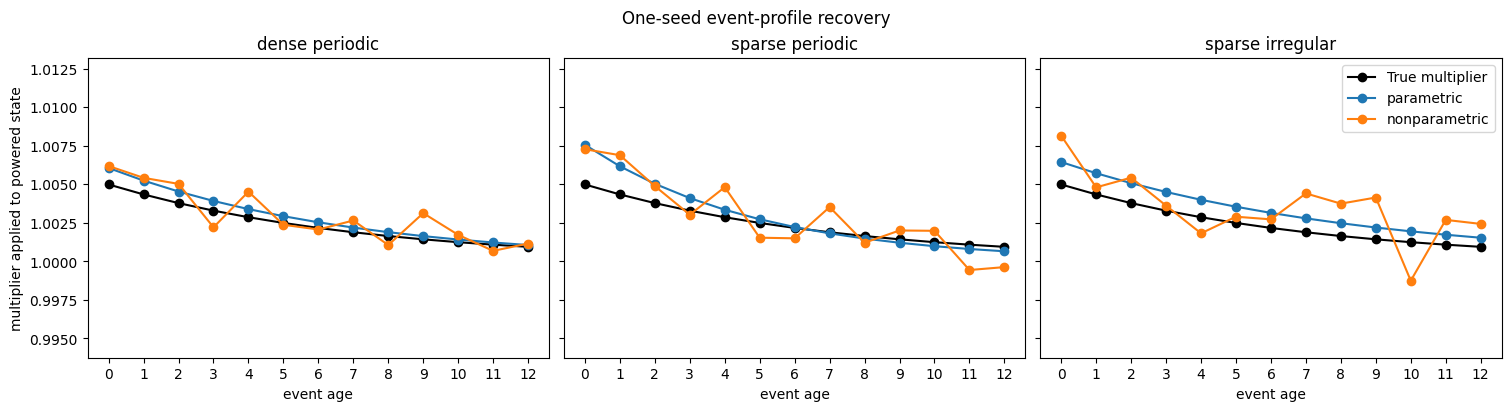

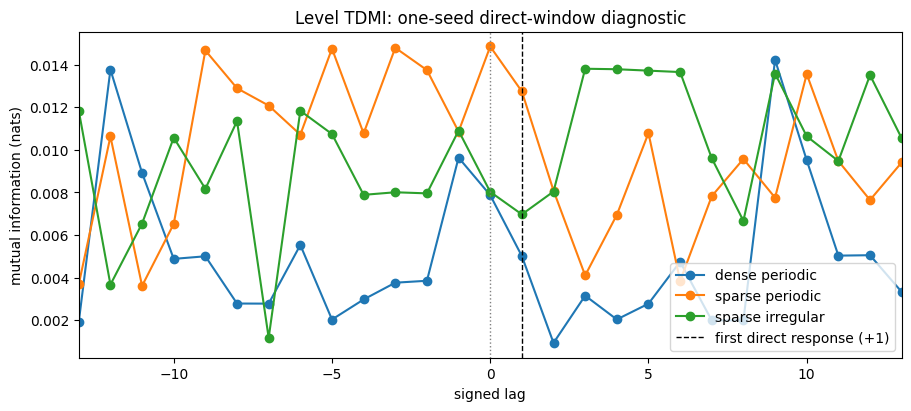

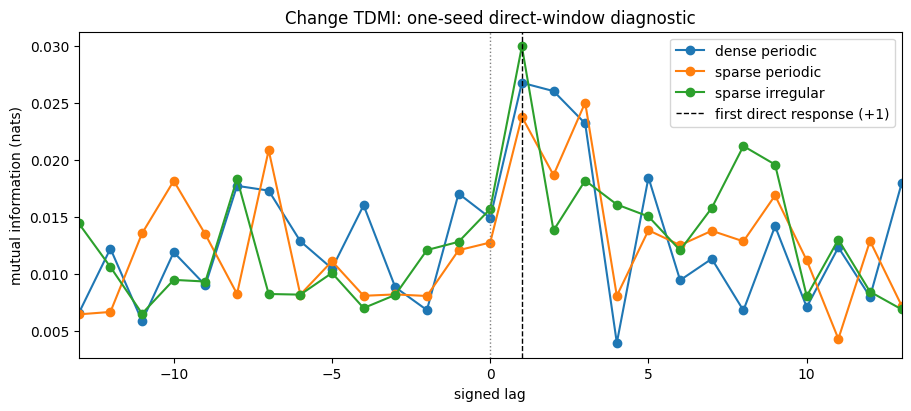

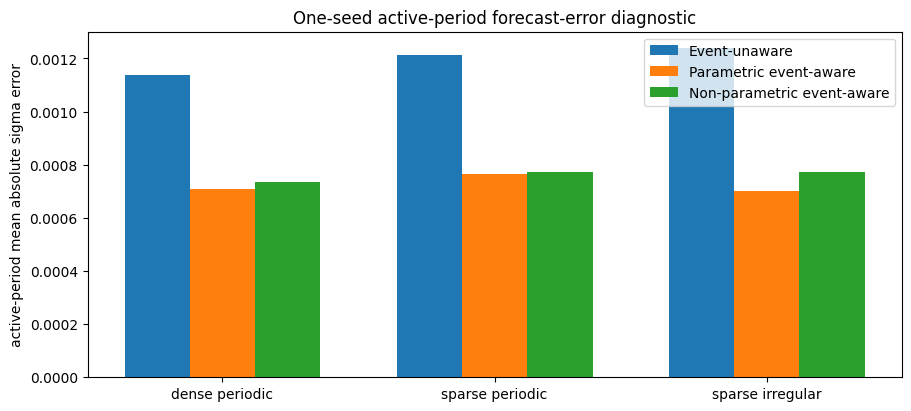

Validation-oriented prototype diagnostics rendered.


In [15]:
case_order = ['dense_periodic', 'sparse_periodic', 'sparse_irregular']
ages = np.arange(RESPONSE_HORIZON_STEPS + 1)
profile_ylim = (
    min(prototype_profile_table[['estimated_multiplier', 'true_multiplier']].min()) * 0.995,
    max(prototype_profile_table[['estimated_multiplier', 'true_multiplier']].max()) * 1.005,
)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True, constrained_layout=True)
for ax, case_name in zip(axes, case_order):
    panel = prototype_profile_table.query('case_name == @case_name')
    truth = panel.groupby('event_age').true_multiplier.first().reindex(ages)
    ax.plot(ages, truth, marker='o', color='black', label='True multiplier')
    for estimator, color in [('parametric', 'tab:blue'), ('nonparametric', 'tab:orange')]:
        fitted = panel.query('estimator == @estimator').set_index('event_age').estimated_multiplier.reindex(ages)
        ax.plot(ages, fitted, marker='o', color=color, label=estimator)
    ax.set(title=case_name.replace('_', ' '), xlabel='event age', xticks=ages, ylim=profile_ylim)
axes[0].set_ylabel('multiplier applied to powered state')
axes[-1].legend(loc='best')
fig.suptitle('One-seed event-profile recovery')
plt.show()

for target_key, label in [('tdmi_level_curve', 'Level TDMI'), ('tdmi_change_curve', 'Change TDMI')]:
    fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
    for case_name in case_order:
        curve = prototype_results[case_name]['causality'][target_key]
        curve = curve.loc[curve.lag.between(-13, 13)]
        ax.plot(curve.lag, curve.mutual_information, marker='o', label=case_name.replace('_', ' '))
    ax.axvline(1, color='black', linestyle='--', linewidth=1, label='first direct response (+1)')
    ax.axvline(0, color='grey', linestyle=':', linewidth=1)
    ax.set(title=f'{label}: one-seed direct-window diagnostic', xlabel='signed lag', ylabel='mutual information (nats)', xlim=(-13, 13))
    ax.legend()
    plt.show()

error_rows = []
for case_name, result in prototype_results.items():
    evaluation = result['evaluation']['evaluation']
    active = evaluation.event_active_i.eq(1)
    for model in MODEL_LABELS:
        error_rows.append({'case_name': case_name, 'model': MODEL_LABELS[model], 'mean_absolute_sigma_error': float(np.abs(evaluation.loc[active, 'sigma_next'] - evaluation.loc[active, f'sigma_forecast_{model}']).mean())})
active_error_table = pd.DataFrame(error_rows)
fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
width = 0.24
for position, model in enumerate(MODEL_LABELS.values()):
    values = active_error_table.query('model == @model').set_index('case_name').reindex(case_order).mean_absolute_sigma_error
    ax.bar(np.arange(len(case_order)) + (position - 1) * width, values, width=width, label=model)
ax.set(xticks=np.arange(len(case_order)), xticklabels=[name.replace('_', ' ') for name in case_order], ylabel='active-period mean absolute sigma error', title='One-seed active-period forecast-error diagnostic')
ax.legend()
plt.show()
print('Validation-oriented prototype diagnostics rendered.')

## 17. Stage 2 findings

The local adapter reproduces the frozen dense-periodic pipeline at the stated tight tolerance, and all three explicit schedules complete the full workflow with the required information-set restrictions intact. The common market shocks remain paired. Event-profile estimation, forecasting, implementable intervals and final truth-based evaluation therefore operate with the explicit irregular schedule; no one-seed failure occurred.

One seed provides no Monte Carlo evidence. Any differences in GC, TDMI, profile recovery, forecast gain or calibration are provisional. Reverse-direction diagnostics and periodic-alias conclusions have not yet been added, and no final schedule comparison should be inferred from this prototype.

This prototype establishes workflow compatibility; its one-seed quantities are retained only as preliminary diagnostics.

## 18. Stage 3 scope and execution controls

Stage 3 creates paired raw checkpoints for 50 market-shock seeds while retaining the fixed sparse-irregular calendar. It performs no aggregation, uncertainty estimation, ranking or substantive comparison. The saved switch is `False`, so the finished notebook only loads checkpoints.

In [16]:
import json

required_stage3_objects = [
    'dense_periodic_case',
    'sparse_periodic_case',
    'sparse_irregular_case',
    'dense_event_steps',
    'sparse_periodic_steps',
    'sparse_irregular_steps',
    'dense_event_times',
    'sparse_periodic_times',
    'sparse_irregular_times',
    'schedule_cases',
    'schedule_steps',
    'schedule_registry',
    'event_calendar_steps',
    'run_schedule_aware_pipeline',
    'results_dir_10',
    'MODEL_LABELS',
]
missing_stage3_objects = [
    name for name in required_stage3_objects if name not in globals()
]
assert not missing_stage3_objects, (
    f'Missing frozen Stage 1 or 2 objects: {missing_stage3_objects}'
)

RUN_STAGE3_REPEATED_EXPERIMENT = False
REPEATED_MARKET_SEEDS = tuple(range(20261001, 20261051))
STAGE3_CASE_ORDER = (
    'dense_periodic',
    'sparse_periodic',
    'sparse_irregular',
)
REVERSE_GC_ORDER = RESPONSE_HORIZON_STEPS + 1
REVERSE_GC_DEGENERACY_TOL = 1e-12
COMMON_TDMI_MAX_LAG = 42
COMMON_TDMI_LAGS = range(-COMMON_TDMI_MAX_LAG, COMMON_TDMI_MAX_LAG + 1)
TDMI_QUANTILE_BINS = 10
DIRECT_RESPONSE_LAGS = range(1, 14)
OUTSIDE_DIRECT_POSITIVE_LAGS = range(14, 43)
NEGATIVE_LAGS = range(-42, 0)

stage3_event_schedules = {
    'dense_periodic': dense_event_times,
    'sparse_periodic': sparse_periodic_times,
    'sparse_irregular': sparse_irregular_times,
}

assert len(REPEATED_MARKET_SEEDS) == 50
assert len(set(REPEATED_MARKET_SEEDS)) == 50
assert PROTOTYPE_MARKET_SEED not in REPEATED_MARKET_SEEDS
assert REVERSE_GC_ORDER == 13
assert tuple(stage3_event_schedules) == STAGE3_CASE_ORDER

print('Stage 3 controls configured; checkpoint-loading mode is active.')


Stage 3 controls configured; checkpoint-loading mode is active.


## 19. Repeated-experiment diagnostic helpers

These compact helpers perform direct simulator preflights, textbook reverse predictive GC, inherited TDMI extraction and essential information-set validation. Reverse GC is predictive only, not structural state-to-event causation.

In [17]:
STAGE3_PREFLIGHT_COLUMNS = [
    'market_seed', 'case_name', 'preflight_success', 'number_of_events',
    'active_transition_count', 'all_finite', 'all_positive',
    'event_indicator_matches', 'active_mask_matches',
    'inactive_weights_equal_one', 'all_ages_present', 'no_overlap',
    'common_epsilon', 'common_eta', 'exception_type', 'exception_message',
]
STAGE3_FAILURE_COLUMNS = [
    'market_seed', 'case_name', 'stage', 'exception_type',
    'exception_message', 'preflight_success', 'pipeline_success',
]
STAGE3_REVERSE_GC_COLUMNS = [
    'market_seed', 'case_name', 'target', 'direction', 'lag_order',
    'restricted_RSS', 'unrestricted_RSS', 'numerator_df', 'denominator_df',
    'F_statistic', 'p_value', 'partial_R_squared', 'sample_size',
    'significant_5pct', 'restricted_model_degenerate',
]


def make_stage3_failure_record(
    market_seed, case_name, stage, exception,
    preflight_success=False, pipeline_success=False,
):
    """Create a compact failure record without changing the original exception."""
    return {
        'market_seed': int(market_seed),
        'case_name': case_name,
        'stage': stage,
        'exception_type': type(exception).__name__,
        'exception_message': str(exception),
        'preflight_success': bool(preflight_success),
        'pipeline_success': bool(pipeline_success),
    }


def make_preflight_failure_record(preflight_row):
    """Preserve the simulator exception captured by a failed preflight row."""
    return {
        'market_seed': int(preflight_row['market_seed']),
        'case_name': preflight_row['case_name'],
        'stage': 'preflight',
        'exception_type': preflight_row['exception_type'],
        'exception_message': preflight_row['exception_message'],
        'preflight_success': False,
        'pipeline_success': False,
    }


def make_shock_bank_preflight_row(market_seed, case_name, exception):
    """Record the required preflight row when a shock bank cannot be created."""
    return {
        'market_seed': int(market_seed),
        'case_name': case_name,
        'preflight_success': False,
        'number_of_events': int(len(schedule_steps[case_name])),
        'active_transition_count': np.nan,
        'all_finite': False,
        'all_positive': False,
        'event_indicator_matches': False,
        'active_mask_matches': False,
        'inactive_weights_equal_one': False,
        'all_ages_present': False,
        'no_overlap': False,
        'common_epsilon': False,
        'common_eta': False,
        'exception_type': type(exception).__name__,
        'exception_message': str(exception),
    }


def run_stage3_preflight(
    case_name,
    case_config,
    event_schedule,
    shock_bank,
    market_seed,
):
    """Run explicit-schedule simulator checks for one seed-case pair."""
    steps = np.asarray(schedule_steps[case_name], dtype=int)
    row = make_shock_bank_preflight_row(
        market_seed,
        case_name,
        RuntimeError('Preflight has not yet run.'),
    )
    row.update({'exception_type': '', 'exception_message': ''})
    try:
        timing = derive_timing(case_config)
        simpack = simulate_case(
            case_config,
            shock_bank,
            seed=None,
            event_schedule=event_schedule,
            _timing=timing,
        )
        simulation = simpack['simulation']
        transitions = simulation['transitions']
        states = simulation['states']
        ages = event_age_from_steps(transitions.i.to_numpy(dtype=int), steps)
        active_mask = transitions.omega_next.to_numpy(dtype=float) > (
            1.0 + EVENT_WEIGHT_TOLERANCE
        )
        expected_epsilon = np.asarray(shock_bank['z_epsilon']) * np.sqrt(
            transitions.dt.to_numpy()
        )
        expected_eta = np.asarray(shock_bank['z_eta']) * np.sqrt(
            transitions.dt.to_numpy()
        )
        checks = {
            'transition_count': len(transitions) == N_TRANSITIONS,
            'all_finite': (
                np.isfinite(states[['S', 'sigma', 'x']].to_numpy()).all()
                and np.isfinite(transitions[['F', 'omega_next']].to_numpy()).all()
            ),
            'all_positive': (
                states[['S', 'sigma', 'x']].gt(0).all().all()
                and transitions[['F', 'omega_next']].gt(0).all().all()
            ),
            'event_indicator_matches': np.array_equal(
                transitions.loc[transitions.event.eq(1), 'i'].to_numpy(dtype=int),
                steps,
            ),
            'active_mask_matches': np.array_equal(active_mask, ages >= 0),
            'inactive_weights_equal_one': np.allclose(
                transitions.loc[~active_mask, 'omega_next'].to_numpy(dtype=float),
                1.0,
                rtol=0.0,
                atol=EVENT_WEIGHT_TOLERANCE,
            ),
            'active_transition_count': int(active_mask.sum()) == 13 * len(steps),
            'all_ages_present': set(ages[active_mask]) == set(range(13)),
            'no_overlap': windows_do_not_overlap(steps),
            'common_epsilon': np.array_equal(
                transitions.epsilon.to_numpy(), expected_epsilon
            ),
            'common_eta': np.array_equal(transitions.eta.to_numpy(), expected_eta),
        }
        row['active_transition_count'] = int(active_mask.sum())
        for name, passed in checks.items():
            if name not in {'transition_count', 'active_transition_count'}:
                row[name] = bool(passed)
        row['preflight_success'] = bool(all(checks.values()))
        if not row['preflight_success']:
            failed_checks = [name for name, passed in checks.items() if not passed]
            raise AssertionError(f'Preflight mechanics failed: {failed_checks}')
    except Exception as exc:
        row['exception_type'] = type(exc).__name__
        row['exception_message'] = str(exc)
        row['preflight_success'] = False
    return row

def run_reverse_predictive_gc(driver, target, target_name):
    """Nested historical OLS diagnostic: powered-state history predicts events."""
    driver = np.asarray(driver, dtype=float)
    target = np.asarray(target, dtype=float)
    rows = []
    for index in range(REVERSE_GC_ORDER, len(target)):
        rows.append([
            target[index],
            *[target[index - lag] for lag in range(1, REVERSE_GC_ORDER + 1)],
            *[driver[index - lag] for lag in range(1, REVERSE_GC_ORDER + 1)],
        ])
    design = np.asarray(rows, dtype=float)
    response = design[:, 0]
    restricted_design = sm.add_constant(
        design[:, 1:1 + REVERSE_GC_ORDER],
        has_constant='add',
    )
    unrestricted_design = sm.add_constant(design[:, 1:], has_constant='add')
    restricted = sm.OLS(response, restricted_design).fit()
    unrestricted = sm.OLS(response, unrestricted_design).fit()
    degenerate = bool(
        restricted.ssr <= REVERSE_GC_DEGENERACY_TOL
        or unrestricted.ssr <= REVERSE_GC_DEGENERACY_TOL
        or unrestricted.df_resid <= 0
    )
    result = {
        'target': target_name,
        'direction': 'powered-state history -> event indicator',
        'lag_order': REVERSE_GC_ORDER,
        'restricted_RSS': float(restricted.ssr),
        'unrestricted_RSS': float(unrestricted.ssr),
        'numerator_df': REVERSE_GC_ORDER,
        'denominator_df': int(unrestricted.df_resid),
        'sample_size': int(unrestricted.nobs),
        'restricted_model_degenerate': degenerate,
    }
    if degenerate:
        result.update({
            'F_statistic': np.nan,
            'p_value': np.nan,
            'partial_R_squared': np.nan,
            'significant_5pct': np.nan,
        })
        return result

    f_statistic = (
        (restricted.ssr - unrestricted.ssr) / REVERSE_GC_ORDER
    ) / (unrestricted.ssr / unrestricted.df_resid)
    p_value = stats.f.sf(f_statistic, REVERSE_GC_ORDER, unrestricted.df_resid)
    result.update({
        'F_statistic': float(f_statistic),
        'p_value': float(p_value),
        'partial_R_squared': float(
            (restricted.ssr - unrestricted.ssr) / restricted.ssr
        ),
        'significant_5pct': bool(p_value < 0.05),
    })
    return result


def extract_standardised_tdmi_metrics(curve):
    """Describe a common signed-lag TDMI curve without interpreting aliases."""
    values = curve.set_index('lag')['mutual_information']

    def peak_with_lag(lags):
        window = values.reindex(list(lags))
        peak_lag = int(window.idxmax())
        return float(window.loc[peak_lag]), peak_lag

    direct_peak, direct_peak_lag = peak_with_lag(DIRECT_RESPONSE_LAGS)
    outside_peak, outside_peak_lag = peak_with_lag(
        OUTSIDE_DIRECT_POSITIVE_LAGS
    )
    negative_peak, negative_peak_lag = peak_with_lag(NEGATIVE_LAGS)
    global_peak, global_peak_lag = peak_with_lag(
        list(NEGATIVE_LAGS) + list(range(1, 43))
    )
    return {
        'tdmi_at_plus_1': float(values.loc[1]),
        'direct_peak': direct_peak,
        'direct_peak_lag': direct_peak_lag,
        'exact_plus_1_recovered': direct_peak_lag == 1,
        'outside_direct_positive_peak': outside_peak,
        'outside_direct_positive_peak_lag': outside_peak_lag,
        'outside_direct_to_direct_ratio': (
            np.nan if direct_peak <= 0 else outside_peak / direct_peak
        ),
        'negative_peak': negative_peak,
        'negative_peak_lag': negative_peak_lag,
        'global_nonzero_peak': global_peak,
        'global_nonzero_peak_lag': global_peak_lag,
        'tdmi_at_plus_21': float(values.loc[21]),
        'tdmi_at_plus_42': float(values.loc[42]),
        'direct_peak_at_window_boundary': direct_peak_lag in {1, 13},
        'global_peak_at_scan_boundary': abs(global_peak_lag) == 42,
    }

def validate_stage3_pipeline(result):
    """Apply the essential frozen-workflow and information-set checks."""
    split = result['split']
    baseline = result['baseline']
    profiles = result['profiles']
    forecast_inputs = result['forecast_inputs']
    forecasts = result['forecasts']
    intervals = result['intervals']['table']
    profile_ids = pd.concat([
        profiles['parametric_fit_row_ids'],
        profiles['nonparametric_fit_row_ids'],
    ], ignore_index=True)
    forbidden_forecast_inputs = {
        'state_next', 'sigma_next', 'delta_state_next', 'eta', 'F',
        'omega', 'omega_next', 'true_omega', 'alpha', 'nu', 'rho',
    }
    hidden_transition_columns = {
        'eta', 'F', 'omega_next', 'alpha', 'nu', 'rho',
    }
    stages = result['pipeline_stages']
    required_tables = [
        result['evaluation']['accuracy'],
        result['evaluation']['relative_gains'],
        result['intervals']['summary'],
        result['causality']['gc'],
        result['causality']['tdmi_level_curve'],
        result['causality']['tdmi_change_curve'],
        result['causality']['tdmi_summary'],
        result['truth']['table'],
        result['truth']['accuracy'],
        result['truth']['interval_summary'],
    ]
    checks = {
        'stage_order': (
            stages[:7] == [
                'simulation', 'transition_table', 'split', 'baseline_fit',
                'profile_fit', 'forecasts_frozen', 'implementable_intervals',
            ]
            and stages[-1] == 'known_dgp_synthetic_reference'
        ),
        'profile_fit': (
            profiles['converged']
            and np.isfinite(profiles['A_hat'])
            and profiles['A_hat'] >= 0
            and np.isfinite(profiles['lambda_hat'])
            and profiles['lambda_hat'] >= 0
        ),
        'forecasts': (
            np.isfinite(forecasts.filter(like='forecast').to_numpy()).all()
            and forecasts.filter(like='forecast').gt(0).all().all()
        ),
        'predictive_variances': (
            np.isfinite(intervals.filter(like='variance').to_numpy()).all()
            and intervals.filter(like='variance').gt(0).all().all()
        ),
        'fitting_rows': (
            baseline['fit_row_ids'].event_active_i.eq(0).all()
            and profile_ids.event_active_i.eq(1).all()
            and profile_ids.i.max() < split['test'].i.min()
        ),
        'forecast_rows': np.array_equal(
            forecasts[['i', 'target_i']].to_numpy(),
            split['test'][['i', 'target_i']].to_numpy(),
        ),
        'information_set': (
            forbidden_forecast_inputs.isdisjoint(forecast_inputs.columns)
            and hidden_transition_columns.isdisjoint(
                result['transition_table'].columns
            )
        ),
        'truth_stage': (
            result['truth'] is not None
            and stages.index('forecasts_frozen')
            < stages.index('implementable_intervals')
            < stages.index('known_dgp_synthetic_reference')
        ),
        'output_tables': all(not table.empty for table in required_tables),
    }
    failed_checks = [name for name, passed in checks.items() if not passed]
    assert not failed_checks, f'Pipeline validation failed: {failed_checks}'
    return checks


print('Stage 3 preflight, reverse-GC, TDMI and pipeline-validation helpers defined.')


Stage 3 preflight, reverse-GC, TDMI and pipeline-validation helpers defined.


## 20. Checkpoint schemas and manifest

Only compact raw records are saved. The manifest fixes seeds, calendar identities and settings for deterministic checkpoint validation.

In [18]:
STAGE3_CASE_SUMMARY_REQUIRED = [
    'market_seed', 'case_name', 'schedule_type', 'calendar_seed',
    'number_of_events', 'minimum_gap_steps', 'mean_gap_steps',
    'standard_deviation_gap_steps', 'train_event_count', 'test_event_count',
    'split_i', 'training_count', 'testing_count', 'paired_shock_group',
    'pipeline_success',
]
STAGE3_TDMI_CURVE_COLUMNS = [
    'market_seed', 'case_name', 'target', 'lag', 'mutual_information',
    'n_pairs',
]
STAGE3_TDMI_METRIC_COLUMNS = [
    'market_seed', 'case_name', 'target', 'tdmi_at_plus_1', 'direct_peak',
    'direct_peak_lag', 'exact_plus_1_recovered',
    'outside_direct_positive_peak', 'outside_direct_positive_peak_lag',
    'outside_direct_to_direct_ratio', 'negative_peak', 'negative_peak_lag',
    'global_nonzero_peak', 'global_nonzero_peak_lag', 'tdmi_at_plus_21',
    'tdmi_at_plus_42', 'direct_peak_at_window_boundary',
    'global_peak_at_scan_boundary',
]
STAGE3_PROFILE_COLUMNS = [
    'market_seed', 'case_name', 'event_age', 'estimator',
    'estimated_multiplier', 'true_multiplier', 'error', 'absolute_error',
    'squared_error',
]
STAGE3_SEED_COMPLETION_COLUMNS = [
    'market_seed', 'shock_bank_created', 'preflight_success_count',
    'pipeline_success_count', 'successful_case_names', 'failed_case_names',
    'paired_triplet_complete', 'common_epsilon_across_successful_cases',
    'common_eta_across_successful_cases',
]


def make_stage3_manifest():
    """Build the JSON-safe description that freezes the Stage 3 design."""
    return {
        'stage_name': 'Notebook 10 Stage 3 repeated schedule experiment',
        'checkpoint_version': 1,
        'run_case_order': list(STAGE3_CASE_ORDER),
        'market_seeds': [int(seed) for seed in REPEATED_MARKET_SEEDS],
        'number_of_seeds': len(REPEATED_MARKET_SEEDS),
        'number_of_cases': len(STAGE3_CASE_ORDER),
        'expected_pipeline_attempts': (
            len(REPEATED_MARKET_SEEDS) * len(STAGE3_CASE_ORDER)
        ),
        'event_calendar_seed': int(EVENT_CALENDAR_SEED),
        'event_steps_by_case': {
            case_name: [int(step) for step in schedule_steps[case_name]]
            for case_name in STAGE3_CASE_ORDER
        },
        'event_count_by_case': {
            case_name: int(len(schedule_steps[case_name]))
            for case_name in STAGE3_CASE_ORDER
        },
        'response_horizon_steps': int(RESPONSE_HORIZON_STEPS),
        'direct_response_lags': [int(lag) for lag in DIRECT_RESPONSE_LAGS],
        'common_tdmi_max_lag': int(COMMON_TDMI_MAX_LAG),
        'tdmi_quantile_bins': int(TDMI_QUANTILE_BINS),
        'reverse_gc_order': int(REVERSE_GC_ORDER),
        'model_n': int(dense_periodic_case['model']['n']),
        'event_amplitude': float(dense_periodic_case['events']['amplitude']),
        'event_decay_rate': float(dense_periodic_case['events']['decay_rate']),
    }


stage3_manifest_expected = make_stage3_manifest()
print('Stage 3 schemas and manifest specification prepared.')


Stage 3 schemas and manifest specification prepared.


## 21. Repeated paired-seed execution or checkpoint loading

With execution enabled, one outer seed loop uses one shared shock bank across schedules, extracts compact outputs and discards temporary full results. With the saved switch disabled, it loads checkpoints and never silently recomputes.

In [19]:
stage3_checkpoint_files = {
    'stage3_preflight_log': results_dir_10 / 'stage3_preflight_log.csv',
    'stage3_failure_log': results_dir_10 / 'stage3_failure_log.csv',
    'stage3_case_summary': results_dir_10 / 'stage3_case_summary.csv',
    'stage3_reverse_gc': results_dir_10 / 'stage3_reverse_gc.csv',
    'stage3_tdmi_curve': results_dir_10 / 'stage3_tdmi_curve.csv',
    'stage3_tdmi_metrics': results_dir_10 / 'stage3_tdmi_metrics.csv',
    'stage3_profile_table': results_dir_10 / 'stage3_profile_table.csv',
    'stage3_seed_completion': results_dir_10 / 'stage3_seed_completion.csv',
    'stage3_manifest': results_dir_10 / 'stage3_manifest.json',
}


def write_stage3_checkpoints(checkpoint_tables, manifest):
    """Persist only compact Stage 3 records and the manifest."""
    for name, path in stage3_checkpoint_files.items():
        if name == 'stage3_manifest':
            path.write_text(json.dumps(manifest, indent=2), encoding='utf-8')
        else:
            checkpoint_tables[name].to_csv(path, index=False)


def load_stage3_checkpoints():
    """Load all Stage 3 checkpoints without constructing a shock bank or pipeline."""
    missing_paths = [
        str(path) for path in stage3_checkpoint_files.values()
        if not path.exists()
    ]
    if missing_paths:
        raise FileNotFoundError(
            'Stage 3 checkpoint-loading mode requires completed checkpoint files: '
            + ', '.join(missing_paths)
        )
    tables = {
        name: pd.read_csv(path)
        for name, path in stage3_checkpoint_files.items()
        if name != 'stage3_manifest'
    }
    manifest = json.loads(
        stage3_checkpoint_files['stage3_manifest'].read_text(encoding='utf-8')
    )
    return tables, manifest


def extract_case_summary(result, case_name, market_seed, registry):
    """Augment the frozen compact summary with schedule and pairing metadata."""
    summary = summarise_case(result).to_dict()
    metadata = registry.loc[case_name]
    split = result['split']
    summary.update({
        'market_seed': int(market_seed),
        'case_name': case_name,
        'schedule_type': metadata['schedule_type'],
        'calendar_seed': metadata['calendar_seed'],
        'number_of_events': int(metadata['number_of_events']),
        'minimum_gap_steps': int(metadata['minimum_gap_steps']),
        'mean_gap_steps': float(metadata['mean_gap_steps']),
        'standard_deviation_gap_steps': float(
            metadata['standard_deviation_gap_steps']
        ),
        'train_event_count': int(split['train'].event_lag_0.sum()),
        'test_event_count': int(split['test'].event_lag_0.sum()),
        'split_i': int(split['split_i']),
        'training_count': len(split['train']),
        'testing_count': len(split['test']),
        'paired_shock_group': int(market_seed),
        'pipeline_success': True,
    })
    return summary


def extract_reverse_gc_rows(result, case_name, market_seed):
    """Return the two fixed-order reverse predictive GC diagnostics."""
    table = result['transition_table']
    state_i = table.state_i.to_numpy()
    event_i = table.event_i.to_numpy()
    specifications = [
        ('powered-state level', state_i, event_i),
        ('powered-state change', np.diff(state_i), event_i[1:]),
    ]
    rows = []
    for target_name, driver, target in specifications:
        row = run_reverse_predictive_gc(driver, target, target_name)
        row.update({'market_seed': int(market_seed), 'case_name': case_name})
        rows.append(row)
    return rows

def extract_standardised_tdmi_rows(result, case_name, market_seed):
    """Calculate compact TDMI records on the fixed Stage 3 signed-lag window."""
    table = result['transition_table']
    specifications = [
        ('level', table.event_i, table.state_i, 'event_i paired with state_i'),
        ('change', table.event_i.iloc[1:], np.diff(table.state_i.to_numpy()),
         'event_i[1:] paired with diff(state_i), matching frozen alignment'),
    ]
    curve_rows = []
    metric_rows = []
    for target_name, source, target, alignment in specifications:
        curve = compute_tdmi_curve(
            source, target, COMMON_TDMI_LAGS, bins=TDMI_QUANTILE_BINS,
            source_name='event_i', target_name=f'{target_name}_state_i',
            alignment=alignment,
        )
        metrics = extract_standardised_tdmi_metrics(curve)
        metrics.update({
            'market_seed': int(market_seed),
            'case_name': case_name,
            'target': target_name,
        })
        metric_rows.append(metrics)
        for curve_row in curve[['lag', 'mutual_information', 'n_pairs']].to_dict(
            orient='records'
        ):
            curve_rows.append({
                'market_seed': int(market_seed),
                'case_name': case_name,
                'target': target_name,
                **curve_row,
            })
    return curve_rows, metric_rows


def extract_profile_rows(result, case_name, market_seed):
    ages = np.arange(RESPONSE_HORIZON_STEPS + 1)
    truth_table = result['truth']['table']
    active_truth = truth_table.query('event_active_i == 1')
    truth_profile = active_truth.groupby('event_age_i').m_true.mean()
    truth_profile = truth_profile.reindex(ages)
    parametric = pd.Series(
        result['profiles']['parametric_multiplier'](ages), index=ages,
    )
    nonparametric = result['profiles']['nonparametric'].reindex(ages)
    estimates = {
        'parametric': parametric,
        'nonparametric': nonparametric,
    }
    rows = []
    for estimator, estimate in estimates.items():
        for age in ages:
            error = float(estimate.loc[age] - truth_profile.loc[age])
            rows.append({
                'market_seed': int(market_seed),
                'case_name': case_name,
                'event_age': int(age),
                'estimator': estimator,
                'estimated_multiplier': float(estimate.loc[age]),
                'true_multiplier': float(truth_profile.loc[age]),
                'error': error,
                'absolute_error': abs(error),
                'squared_error': error ** 2,
            })
    return rows

def compare_seed_shocks(current_results):
    if len(current_results) <= 1:
        return np.nan, np.nan, []
    reference = next(iter(current_results.values()))['simulation']['transitions']
    checks = {
        'epsilon': lambda table: np.array_equal(
            table.epsilon.to_numpy(), reference.epsilon.to_numpy()
        ),
        'eta': lambda table: np.array_equal(
            table.eta.to_numpy(), reference.eta.to_numpy()
        ),
        'indices': lambda table: np.array_equal(
            table.i.to_numpy(), reference.i.to_numpy()
        ),
        'target indices': lambda table: np.array_equal(
            table.target_i.to_numpy(), reference.target_i.to_numpy()
        ),
        'time increments': lambda table: np.array_equal(
            table.dt.to_numpy(), reference.dt.to_numpy()
        ),
    }
    failures = []
    for name, comparator in checks.items():
        matching = all(
            comparator(result['simulation']['transitions'])
            for result in current_results.values()
        )
        if not matching:
            failures.append(name)
    alignment_failures = {'indices', 'target indices', 'time increments'}
    common_epsilon = not (
        {'epsilon'}.union(alignment_failures).intersection(failures)
    )
    common_eta = not (
        {'eta'}.union(alignment_failures).intersection(failures)
    )
    return common_epsilon, common_eta, failures
stage3_loaded_from_checkpoints = not RUN_STAGE3_REPEATED_EXPERIMENT

if RUN_STAGE3_REPEATED_EXPERIMENT:
    preflight_rows = []
    failure_rows = []
    summary_rows = []
    reverse_gc_rows = []
    tdmi_curve_rows = []
    tdmi_metric_rows = []
    profile_rows = []
    completion_rows = []
    registry = schedule_registry.set_index('case_name')

    for completed_seed_count, market_seed in enumerate(
        REPEATED_MARKET_SEEDS,
        start=1,
    ):
        current_results = {}
        preflight_success_by_case = {}
        pipeline_success_names = []
        failed_case_names = []
        shock_bank_created = False

        try:
            shock_bank = make_shock_bank(
                dense_periodic_case,
                seed=market_seed,
            )
            shock_bank_created = True
        except Exception as exc:
            for case_name in STAGE3_CASE_ORDER:
                preflight_rows.append(
                    make_shock_bank_preflight_row(market_seed, case_name, exc)
                )
                failure_rows.append(make_stage3_failure_record(
                    market_seed,
                    case_name,
                    'shock_bank',
                    exc,
                ))
                failed_case_names.append(case_name)

        if shock_bank_created:
            for case_name in STAGE3_CASE_ORDER:
                preflight_row = run_stage3_preflight(
                    case_name,
                    schedule_cases[case_name],
                    stage3_event_schedules[case_name],
                    shock_bank,
                    market_seed,
                )
                preflight_rows.append(preflight_row)
                preflight_success_by_case[case_name] = bool(
                    preflight_row['preflight_success']
                )
                if not preflight_row['preflight_success']:
                    failure_rows.append(
                        make_preflight_failure_record(preflight_row)
                    )
                    failed_case_names.append(case_name)

            for case_name in STAGE3_CASE_ORDER:
                if not preflight_success_by_case.get(case_name, False):
                    continue
                try:
                    result = run_schedule_aware_pipeline(
                        schedule_cases[case_name],
                        event_schedule=stage3_event_schedules[case_name],
                        shock_bank=shock_bank,
                        include_causality=True,
                        include_intervals=True,
                        include_truth=True,
                    )
                    validate_stage3_pipeline(result)
                    current_results[case_name] = result
                    pipeline_success_names.append(case_name)
                except Exception as exc:
                    failure_rows.append(make_stage3_failure_record(
                        market_seed,
                        case_name,
                        'full_pipeline',
                        exc,
                        preflight_success=True,
                    ))
                    failed_case_names.append(case_name)

        common_epsilon, common_eta, common_shock_failures = compare_seed_shocks(
            current_results
        )
        if common_shock_failures:
            message = 'Common-shock mismatch: ' + ', '.join(
                common_shock_failures
            )
            common_shock_error = RuntimeError(message)
            for case_name in current_results:
                failure_rows.append(make_stage3_failure_record(
                    market_seed,
                    case_name,
                    'common_shock',
                    common_shock_error,
                    preflight_success=True,
                    pipeline_success=True,
                ))

        for case_name, result in current_results.items():
            try:
                summary_rows.append(
                    extract_case_summary(
                        result,
                        case_name,
                        market_seed,
                        registry,
                    )
                )
            except Exception as exc:
                failure_rows.append(make_stage3_failure_record(
                    market_seed,
                    case_name,
                    'summary_extraction',
                    exc,
                    preflight_success=True,
                    pipeline_success=True,
                ))

            try:
                reverse_gc_rows.extend(
                    extract_reverse_gc_rows(result, case_name, market_seed)
                )
            except Exception as exc:
                failure_rows.append(make_stage3_failure_record(
                    market_seed,
                    case_name,
                    'reverse_gc',
                    exc,
                    preflight_success=True,
                    pipeline_success=True,
                ))

            try:
                curve_rows, metric_rows = extract_standardised_tdmi_rows(
                    result,
                    case_name,
                    market_seed,
                )
                tdmi_curve_rows.extend(curve_rows)
                tdmi_metric_rows.extend(metric_rows)
            except Exception as exc:
                failure_rows.append(make_stage3_failure_record(
                    market_seed,
                    case_name,
                    'standardised_tdmi',
                    exc,
                    preflight_success=True,
                    pipeline_success=True,
                ))

            try:
                profile_rows.extend(
                    extract_profile_rows(result, case_name, market_seed)
                )
            except Exception as exc:
                failure_rows.append(make_stage3_failure_record(
                    market_seed,
                    case_name,
                    'profile_extraction',
                    exc,
                    preflight_success=True,
                    pipeline_success=True,
                ))

        preflight_success_count = sum(preflight_success_by_case.values())
        completion_rows.append({
            'market_seed': int(market_seed),
            'shock_bank_created': shock_bank_created,
            'preflight_success_count': int(preflight_success_count),
            'pipeline_success_count': len(pipeline_success_names),
            'successful_case_names': ';'.join(pipeline_success_names),
            'failed_case_names': ';'.join(sorted(set(failed_case_names))),
            'paired_triplet_complete': len(pipeline_success_names) == 3,
            'common_epsilon_across_successful_cases': common_epsilon,
            'common_eta_across_successful_cases': common_eta,
        })
        del current_results

        if completed_seed_count % 5 == 0:
            print('Stage 3 completed {} of {} market seeds.'.format(
                completed_seed_count, len(REPEATED_MARKET_SEEDS)
            ))

    stage3_preflight_log = pd.DataFrame(preflight_rows, columns=STAGE3_PREFLIGHT_COLUMNS)
    stage3_failure_log = pd.DataFrame(failure_rows, columns=STAGE3_FAILURE_COLUMNS)
    stage3_case_summary = pd.DataFrame(summary_rows)
    stage3_reverse_gc = pd.DataFrame(reverse_gc_rows, columns=STAGE3_REVERSE_GC_COLUMNS)
    stage3_tdmi_curve = pd.DataFrame(tdmi_curve_rows, columns=STAGE3_TDMI_CURVE_COLUMNS)
    stage3_tdmi_metrics = pd.DataFrame(tdmi_metric_rows, columns=STAGE3_TDMI_METRIC_COLUMNS)
    stage3_profile_table = pd.DataFrame(profile_rows, columns=STAGE3_PROFILE_COLUMNS)
    stage3_seed_completion = pd.DataFrame(completion_rows, columns=STAGE3_SEED_COMPLETION_COLUMNS)
    stage3_manifest = make_stage3_manifest()

    stage3_tables = {
        'stage3_preflight_log': stage3_preflight_log,
        'stage3_failure_log': stage3_failure_log,
        'stage3_case_summary': stage3_case_summary,
        'stage3_reverse_gc': stage3_reverse_gc,
        'stage3_tdmi_curve': stage3_tdmi_curve,
        'stage3_tdmi_metrics': stage3_tdmi_metrics,
        'stage3_profile_table': stage3_profile_table,
        'stage3_seed_completion': stage3_seed_completion,
    }
    write_stage3_checkpoints(stage3_tables, stage3_manifest)

else:
    loaded_tables, stage3_manifest = load_stage3_checkpoints()
    stage3_preflight_log = loaded_tables['stage3_preflight_log']
    stage3_failure_log = loaded_tables['stage3_failure_log']
    stage3_case_summary = loaded_tables['stage3_case_summary']
    stage3_reverse_gc = loaded_tables['stage3_reverse_gc']
    stage3_tdmi_curve = loaded_tables['stage3_tdmi_curve']
    stage3_tdmi_metrics = loaded_tables['stage3_tdmi_metrics']
    stage3_profile_table = loaded_tables['stage3_profile_table']
    stage3_seed_completion = loaded_tables['stage3_seed_completion']

preflight_counts_by_case = (
    stage3_preflight_log.groupby('case_name', dropna=False)
    .preflight_success.sum()
    .rename('preflight_success_count')
    .reset_index()
)
pipeline_counts_by_case = (
    stage3_case_summary.groupby('case_name', dropna=False)
    .size()
    .rename('pipeline_success_count')
    .reset_index()
)
failure_counts_by_stage_case = (
    stage3_failure_log.groupby(['stage', 'case_name'], dropna=False)
    .size()
    .rename('failure_count')
    .reset_index()
)
checkpoint_row_counts = pd.DataFrame({
    'checkpoint': [
        'preflight', 'failure', 'case_summary', 'reverse_gc', 'tdmi_curve',
        'tdmi_metrics', 'profile', 'seed_completion',
    ],
    'rows': [
        len(stage3_preflight_log), len(stage3_failure_log),
        len(stage3_case_summary), len(stage3_reverse_gc),
        len(stage3_tdmi_curve), len(stage3_tdmi_metrics),
        len(stage3_profile_table), len(stage3_seed_completion),
    ],
})
display(preflight_counts_by_case)
display(pipeline_counts_by_case)
display(failure_counts_by_stage_case)
display(pd.DataFrame({
    'complete_paired_triplets': [
        int(stage3_seed_completion.paired_triplet_complete.sum())
    ],
}))
display(checkpoint_row_counts)


,case_name,preflight_success_count
0,dense_periodic,50
1,sparse_irregular,50
2,sparse_periodic,50


,case_name,pipeline_success_count
0,dense_periodic,50
1,sparse_irregular,50
2,sparse_periodic,50


,stage,case_name,failure_count


,complete_paired_triplets
0,50


,checkpoint,rows
0,preflight,150
1,failure,0
2,case_summary,150
3,reverse_gc,300
4,tdmi_curve,25500
5,tdmi_metrics,300
6,profile,3900
7,seed_completion,50


## 22. Stage 3 checkpoint validation

The validation applies after either creation or loading. It checks manifest identity, schemas, keys, supports, completion records and the absence of infinite values, without assuming a failure-free experiment.

In [20]:
required_checkpoint_columns = {
    'preflight': (stage3_preflight_log, STAGE3_PREFLIGHT_COLUMNS),
    'failure': (stage3_failure_log, STAGE3_FAILURE_COLUMNS),
    'case_summary': (stage3_case_summary, STAGE3_CASE_SUMMARY_REQUIRED),
    'reverse_gc': (stage3_reverse_gc, STAGE3_REVERSE_GC_COLUMNS),
    'tdmi_curve': (stage3_tdmi_curve, STAGE3_TDMI_CURVE_COLUMNS),
    'tdmi_metrics': (stage3_tdmi_metrics, STAGE3_TDMI_METRIC_COLUMNS),
    'profile': (stage3_profile_table, STAGE3_PROFILE_COLUMNS),
    'seed_completion': (
        stage3_seed_completion,
        STAGE3_SEED_COMPLETION_COLUMNS,
    ),
}
for checkpoint_name, (table, required_columns) in (
    required_checkpoint_columns.items()
):
    missing_columns = set(required_columns).difference(table.columns)
    assert not missing_columns, (
        f'{checkpoint_name} checkpoint missing columns: '
        f'{sorted(missing_columns)}'
    )

assert stage3_manifest['checkpoint_version'] == 1
assert stage3_manifest == stage3_manifest_expected

expected_seed_case_keys = {
    (seed, case_name)
    for seed in REPEATED_MARKET_SEEDS
    for case_name in STAGE3_CASE_ORDER
}
preflight_keys = set(
    stage3_preflight_log[['market_seed', 'case_name']].itertuples(
        index=False,
        name=None,
    )
)
assert len(stage3_preflight_log) == (
    len(REPEATED_MARKET_SEEDS) * len(STAGE3_CASE_ORDER)
)
assert not stage3_preflight_log.duplicated(['market_seed', 'case_name']).any()
assert preflight_keys == expected_seed_case_keys

assert len(stage3_seed_completion) == len(REPEATED_MARKET_SEEDS)
assert not stage3_seed_completion.duplicated(['market_seed']).any()
assert set(stage3_seed_completion.market_seed) == set(REPEATED_MARKET_SEEDS)

failure_keys = set(
    stage3_failure_log[['market_seed', 'case_name']].itertuples(
        index=False,
        name=None,
    )
)
assert failure_keys.issubset(expected_seed_case_keys)

def failure_exists(market_seed, case_name, stage):
    return bool((
        (stage3_failure_log.market_seed == market_seed)
        & (stage3_failure_log.case_name == case_name)
        & (stage3_failure_log.stage == stage)
    ).any())


def successful_pipeline_keys_from_completion():
    keys = set()
    for completion in stage3_seed_completion.itertuples(index=False):
        names = completion.successful_case_names
        if pd.isna(names) or str(names).strip() == '':
            continue
        for case_name in str(names).split(';'):
            case_name = case_name.strip()
            if case_name:
                assert case_name in STAGE3_CASE_ORDER
                keys.add((int(completion.market_seed), case_name))
    return keys


unsuccessful_preflights = stage3_preflight_log.loc[
    stage3_preflight_log.preflight_success.fillna(False).eq(False),
    ['market_seed', 'case_name'],
]
for market_seed, case_name in unsuccessful_preflights.itertuples(
    index=False,
    name=None,
):
    assert failure_exists(market_seed, case_name, 'preflight') or failure_exists(
        market_seed,
        case_name,
        'shock_bank',
    )

successful_preflight_keys = set(
    stage3_preflight_log.loc[
        stage3_preflight_log.preflight_success.fillna(False),
        ['market_seed', 'case_name'],
    ].itertuples(index=False, name=None)
)
pipeline_success_keys = successful_pipeline_keys_from_completion()
summary_keys = set(
    stage3_case_summary[['market_seed', 'case_name']].itertuples(
        index=False,
        name=None,
    )
)
assert pipeline_success_keys.issubset(successful_preflight_keys)
assert summary_keys.issubset(pipeline_success_keys)

successful_preflight_without_pipeline = (
    successful_preflight_keys - pipeline_success_keys
)
for market_seed, case_name in successful_preflight_without_pipeline:
    assert failure_exists(market_seed, case_name, 'full_pipeline')

for market_seed, case_name in pipeline_success_keys.difference(summary_keys):
    assert failure_exists(market_seed, case_name, 'summary_extraction')

expected_reverse_targets = {
    'powered-state level',
    'powered-state change',
}
expected_tdmi_targets = {'level', 'change'}
expected_profile_estimators = {'parametric', 'nonparametric'}
expected_profile_ages = set(range(RESPONSE_HORIZON_STEPS + 1))
expected_tdmi_lags = set(COMMON_TDMI_LAGS)
reverse_completeness_checks = []
tdmi_completeness_checks = []
profile_completeness_checks = []

for market_seed, case_name in sorted(pipeline_success_keys):
    reverse_cells = stage3_reverse_gc.loc[
        (stage3_reverse_gc.market_seed == market_seed)
        & (stage3_reverse_gc.case_name == case_name)
    ]
    reverse_complete = (
        len(reverse_cells) == 2
        and set(reverse_cells.target) == expected_reverse_targets
    )
    reverse_completeness_checks.append(reverse_complete)
    if not reverse_complete:
        assert failure_exists(market_seed, case_name, 'reverse_gc')

    tdmi_curve_cells = stage3_tdmi_curve.loc[
        (stage3_tdmi_curve.market_seed == market_seed)
        & (stage3_tdmi_curve.case_name == case_name)
    ]
    tdmi_metric_cells = stage3_tdmi_metrics.loc[
        (stage3_tdmi_metrics.market_seed == market_seed)
        & (stage3_tdmi_metrics.case_name == case_name)
    ]
    tdmi_complete = (
        len(tdmi_curve_cells) == 2 * len(COMMON_TDMI_LAGS)
        and len(tdmi_metric_cells) == 2
        and set(tdmi_curve_cells.target) == expected_tdmi_targets
        and set(tdmi_metric_cells.target) == expected_tdmi_targets
        and all(
            set(group.lag) == expected_tdmi_lags
            for _, group in tdmi_curve_cells.groupby('target')
        )
    )
    tdmi_completeness_checks.append(tdmi_complete)
    if not tdmi_complete:
        assert failure_exists(market_seed, case_name, 'standardised_tdmi')

    profile_cells = stage3_profile_table.loc[
        (stage3_profile_table.market_seed == market_seed)
        & (stage3_profile_table.case_name == case_name)
    ]
    profile_complete = (
        len(profile_cells) == 2 * len(expected_profile_ages)
        and set(profile_cells.estimator) == expected_profile_estimators
        and all(
            set(group.event_age) == expected_profile_ages
            for _, group in profile_cells.groupby('estimator')
        )
    )
    profile_completeness_checks.append(profile_complete)
    if not profile_complete:
        assert failure_exists(market_seed, case_name, 'profile_extraction')


def explicitly_false(value):
    return pd.notna(value) and not bool(value)


for completion in stage3_seed_completion.itertuples(index=False):
    common_shock_failed = (
        explicitly_false(completion.common_epsilon_across_successful_cases)
        or explicitly_false(completion.common_eta_across_successful_cases)
    )
    if common_shock_failed:
        assert bool((
            (stage3_failure_log.market_seed == completion.market_seed)
            & (stage3_failure_log.stage == 'common_shock')
        ).any())

assert not stage3_case_summary.duplicated(['market_seed', 'case_name']).any()
assert not stage3_reverse_gc.duplicated(['market_seed', 'case_name', 'target']).any()
assert not stage3_tdmi_curve.duplicated(
    ['market_seed', 'case_name', 'target', 'lag']
).any()
assert not stage3_tdmi_metrics.duplicated(
    ['market_seed', 'case_name', 'target']
).any()
assert not stage3_profile_table.duplicated(
    ['market_seed', 'case_name', 'estimator', 'event_age']
).any()

# Each diagnostic completeness check is evaluated per successful pipeline.

checkpoint_metric_tables = [
    stage3_preflight_log,
    stage3_case_summary,
    stage3_reverse_gc,
    stage3_tdmi_curve,
    stage3_tdmi_metrics,
    stage3_profile_table,
    stage3_seed_completion,
]
for table in checkpoint_metric_tables:
    numeric_values = table.select_dtypes(include=[np.number]).to_numpy(
        dtype=float
    )
    assert not np.isinf(numeric_values).any(), (
        'Checkpoint metrics contain an infinite numerical value.'
    )

all_requested_pipelines_succeeded = (
    stage3_seed_completion.pipeline_success_count.eq(
        len(STAGE3_CASE_ORDER)
    ).all()
)
expected_checkpoint_row_counts = {
    'preflight': len(REPEATED_MARKET_SEEDS) * len(STAGE3_CASE_ORDER),
    'case_summary_if_complete': len(pipeline_success_keys),
    'reverse_gc_if_complete': 2 * len(pipeline_success_keys),
    'tdmi_curve_if_complete': (
        2 * len(pipeline_success_keys) * len(COMMON_TDMI_LAGS)
    ),
    'tdmi_metrics_if_complete': 2 * len(pipeline_success_keys),
    'profile_if_complete': 2 * 13 * len(pipeline_success_keys),
}

if all_requested_pipelines_succeeded:
    assert len(stage3_case_summary) == 150
    assert len(stage3_reverse_gc) == 300
    assert len(stage3_tdmi_curve) == 25_500
    assert len(stage3_tdmi_metrics) == 300
    assert len(stage3_profile_table) == 3_900
    assert stage3_seed_completion['paired_triplet_complete'].all()
    assert len(reverse_completeness_checks) == 150
    assert len(tdmi_completeness_checks) == 150
    assert len(profile_completeness_checks) == 150
    assert all(reverse_completeness_checks)
    assert all(tdmi_completeness_checks)
    assert all(profile_completeness_checks)

checkpoint_loading_mode_passed = bool(
    stage3_loaded_from_checkpoints
    and RUN_STAGE3_REPEATED_EXPERIMENT is False
)
assert not (
    RUN_STAGE3_REPEATED_EXPERIMENT and stage3_loaded_from_checkpoints
)
assert checkpoint_loading_mode_passed
print('Stage 3 manifest, schema, uniqueness and raw-checkpoint validations passed.')


Stage 3 manifest, schema, uniqueness and raw-checkpoint validations passed.


## 23. Stage 3 execution status

The requested 50 market seeds produced 150 attempted and 150 successful pipelines, with no recorded failures. All 50 seed triplets are complete, common-shock checks passed, and checkpoint-loading mode is now validated without recomputation.

GC and TDMI remain predictive/dependence diagnostics rather than interventionist causal proof. Reverse GC is a reverse predictive diagnostic, not evidence that volatility structurally causes scheduled events. The sparse-irregular calendar is fixed while market shocks vary across seeds; final comparisons must use paired complete seeds. Negative forecast gains and calibration errors remain visible in the retained checkpoint tables.

The repeated checkpoint set is retained as the auditable source for all subsequent aggregation and synthesis tables.

## 24. Stage 4 scope and statistical conventions

Stage 4 aggregates the completed Stage 3 checkpoints only. It uses the 50 complete market-seed triplets for Monte Carlo summaries and same-seed schedule contrasts. For a contrast, the paired difference is $D_s=M_{s,\\mathrm{comparison}}-M_{s,\\mathrm{reference}}$; this orientation is retained irrespective of whether a result appears favourable. Numeric uncertainty intervals are two-sided Student-$t$ intervals for the mean across the frozen seeds, while Boolean rates use Wilson intervals. These summarize this Monte Carlo experiment and are not population-confidence guarantees.

In [21]:
from scipy import stats

assert RUN_STAGE3_REPEATED_EXPERIMENT is False
assert checkpoint_loading_mode_passed
assert stage3_failure_log.empty
assert stage3_seed_completion['paired_triplet_complete'].all()
assert len(stage3_seed_completion) == 50
assert len(stage3_case_summary) == 150

STAGE4_CASE_ORDER = (
    'dense_periodic',
    'sparse_periodic',
    'sparse_irregular',
)
STAGE4_CASE_LABELS = {
    'dense_periodic': 'Dense periodic',
    'sparse_periodic': 'Sparse periodic',
    'sparse_irregular': 'Sparse irregular',
}
STAGE4_CONTRASTS = {
    'sparse_periodic_minus_dense_periodic': {
        'reference_case': 'dense_periodic',
        'comparison_case': 'sparse_periodic',
        'scientific_role': (
            'Effect of reducing event frequency and event count '
            'while retaining periodic timing'
        ),
    },
    'sparse_irregular_minus_sparse_periodic': {
        'reference_case': 'sparse_periodic',
        'comparison_case': 'sparse_irregular',
        'scientific_role': (
            'Effect of irregular timing at matched event count '
            'and average frequency'
        ),
    },
    'sparse_irregular_minus_dense_periodic': {
        'reference_case': 'dense_periodic',
        'comparison_case': 'sparse_irregular',
        'scientific_role': (
            'Combined effect of lower frequency, fewer events '
            'and irregular timing'
        ),
    },
}
STAGE4_EQUALITY_TOLERANCE = 1e-12
stage4_figures_dir = results_dir_10 / 'stage4_figures'
stage4_figures_dir.mkdir(parents=True, exist_ok=True)


def summarise_numeric_series(values):
    values = pd.Series(values, dtype=float).dropna()
    count = len(values)
    mean = float(values.mean()) if count else np.nan
    standard_deviation = float(values.std(ddof=1)) if count > 1 else np.nan
    standard_error = standard_deviation / np.sqrt(count) if count > 1 else np.nan
    half_width = stats.t.ppf(0.975, count - 1) * standard_error if count > 1 else np.nan
    return {
        'count': count, 'mean': mean, 'standard_deviation': standard_deviation,
        'monte_carlo_standard_error': standard_error,
        'ci_95_lower': mean - half_width if count > 1 else np.nan,
        'ci_95_upper': mean + half_width if count > 1 else np.nan,
        'median': float(values.median()) if count else np.nan,
        'q05': float(values.quantile(0.05)) if count else np.nan,
        'q25': float(values.quantile(0.25)) if count else np.nan,
        'q75': float(values.quantile(0.75)) if count else np.nan,
        'q95': float(values.quantile(0.95)) if count else np.nan,
        'q05_q95_width': float(values.quantile(0.95) - values.quantile(0.05)) if count else np.nan,
    }


def wilson_interval(successes, count, confidence=0.95):
    if count == 0:
        return np.nan, np.nan
    z_value = stats.norm.ppf(1 - (1 - confidence) / 2)
    proportion = successes / count
    denominator = 1 + z_value ** 2 / count
    centre = (proportion + z_value ** 2 / (2 * count)) / denominator
    half_width = z_value * np.sqrt(
        proportion * (1 - proportion) / count + z_value ** 2 / (4 * count ** 2)
    ) / denominator
    return float(centre - half_width), float(centre + half_width)


def summarise_binary_series(values):
    values = pd.Series(values).dropna().astype(bool)
    count = len(values)
    successes = int(values.sum())
    lower, upper = wilson_interval(successes, count)
    return {
        'count': count, 'successes': successes,
        'rate': successes / count if count else np.nan,
        'ci_95_lower': lower, 'ci_95_upper': upper,
    }


def summarise_paired_difference(values):
    summary = summarise_numeric_series(values)
    values = pd.Series(values, dtype=float).dropna()
    summary.update({
        'fraction_above_zero': float((values > STAGE4_EQUALITY_TOLERANCE).mean()),
        'fraction_below_zero': float((values < -STAGE4_EQUALITY_TOLERANCE).mean()),
        'fraction_equal_zero': float((values.abs() <= STAGE4_EQUALITY_TOLERANCE).mean()),
        'interval_excludes_zero': bool(
            summary['ci_95_lower'] > 0 or summary['ci_95_upper'] < 0
        ) if len(values) > 1 else False,
    })
    return summary

print('Stage 4 uses loaded Stage 3 checkpoints only; no pipeline is rerun.')

Stage 4 uses loaded Stage 3 checkpoints only; no pipeline is rerun.


## 25. Construct the complete paired analysis table

The analysis table starts from the compact Stage 3 case summaries. Reverse predictive-GC and signed-lag TDMI metric records are pivoted onto the same `(market_seed, case_name)` key. No row is removed because of its sign, significance, or magnitude.

In [22]:
stage4_seed_case_analysis = stage3_case_summary.copy()
stage4_seed_case_analysis['case_name'] = pd.Categorical(
    stage4_seed_case_analysis['case_name'], categories=STAGE4_CASE_ORDER,
    ordered=True,
)
stage4_seed_case_analysis['gc_level_detected_5pct'] = (
    stage4_seed_case_analysis['gc_level_p_value'] < 0.05
)
stage4_seed_case_analysis['gc_change_detected_5pct'] = (
    stage4_seed_case_analysis['gc_change_p_value'] < 0.05
)

reverse_target_names = {
    'powered-state level': 'level',
    'powered-state change': 'change',
}
reverse_fields = [
    'partial_R_squared', 'significant_5pct', 'restricted_model_degenerate',
]
reverse_wide = stage3_reverse_gc.assign(
    target_short=stage3_reverse_gc.target.map(reverse_target_names)
).pivot(
    index=['market_seed', 'case_name'], columns='target_short',
    values=reverse_fields,
)
reverse_wide.columns = [
    f'reverse_gc_{target}_{field}' for field, target in reverse_wide.columns
]
reverse_wide = reverse_wide.rename(columns={
    'reverse_gc_level_significant_5pct': 'reverse_gc_level_detected_5pct',
    'reverse_gc_change_significant_5pct': 'reverse_gc_change_detected_5pct',
    'reverse_gc_level_restricted_model_degenerate': 'reverse_gc_level_degenerate',
    'reverse_gc_change_restricted_model_degenerate': 'reverse_gc_change_degenerate',
}).reset_index()

tdmi_fields = [
    'tdmi_at_plus_1', 'direct_peak', 'direct_peak_lag',
    'exact_plus_1_recovered', 'outside_direct_positive_peak',
    'outside_direct_positive_peak_lag', 'outside_direct_to_direct_ratio',
    'negative_peak', 'negative_peak_lag', 'global_nonzero_peak',
    'global_nonzero_peak_lag', 'tdmi_at_plus_21', 'tdmi_at_plus_42',
    'direct_peak_at_window_boundary', 'global_peak_at_scan_boundary',
]
tdmi_wide = stage3_tdmi_metrics.pivot(
    index=['market_seed', 'case_name'], columns='target', values=tdmi_fields,
)
tdmi_wide.columns = [
    f"tdmi_{target}_{field.replace('tdmi_', '')}"
    for field, target in tdmi_wide.columns
]
tdmi_wide = tdmi_wide.reset_index()

stage4_seed_case_analysis = stage4_seed_case_analysis.merge(
    reverse_wide, on=['market_seed', 'case_name'], how='left',
    validate='one_to_one',
).merge(
    tdmi_wide, on=['market_seed', 'case_name'], how='left',
    validate='one_to_one',
)
stage4_seed_case_analysis['A_error'] = (
    stage4_seed_case_analysis.A_hat - stage4_seed_case_analysis.event_amplitude
)
stage4_seed_case_analysis['A_absolute_error'] = stage4_seed_case_analysis.A_error.abs()
stage4_seed_case_analysis['lambda_error'] = (
    stage4_seed_case_analysis.lambda_hat - stage4_seed_case_analysis.event_decay_rate
)
stage4_seed_case_analysis['lambda_absolute_error'] = (
    stage4_seed_case_analysis.lambda_error.abs()
)
stage4_seed_case_analysis['parametric_positive_MAE_gain'] = (
    stage4_seed_case_analysis.active_sigma_parametric_MAE_gain_pct > 0
)
stage4_seed_case_analysis['nonparametric_positive_MAE_gain'] = (
    stage4_seed_case_analysis.active_sigma_nonparametric_MAE_gain_pct > 0
)
for model in ('unaware', 'parametric', 'nonparametric'):
    coverage = f'active_95_state_{model}_coverage'
    stage4_seed_case_analysis[f'{model}_coverage_bias'] = (
        stage4_seed_case_analysis[coverage] - 0.95
    )
    stage4_seed_case_analysis[f'{model}_absolute_coverage_error'] = (
        stage4_seed_case_analysis[f'{model}_coverage_bias'].abs()
    )

assert len(stage4_seed_case_analysis) == 150
assert not stage4_seed_case_analysis.duplicated(['market_seed', 'case_name']).any()
assert stage4_seed_case_analysis.groupby('market_seed', observed=True).case_name.agg(
    lambda values: set(values) == set(STAGE4_CASE_ORDER)
).all()

metric_rows = []
def register(metrics, family, favourable_direction, units, value_type='numeric'):
    for metric, display_label in metrics:
        metric_rows.append({
            'metric': metric,
            'source_table': 'stage4_seed_case_analysis',
            'display_label': display_label,
            'metric_family': family,
            'favourable_direction': favourable_direction,
            'units': units,
            'value_type': value_type,
        })

register([
    ('gc_level_partial_r_squared', 'Forward GC level partial R-squared'),
    ('gc_change_partial_r_squared', 'Forward GC change partial R-squared'),
    ('conditional_event_history_partial_r_squared', 'Conditional event-history partial R-squared'),
], 'forward predictive GC', 'higher', 'partial R-squared')
register([
    ('reverse_gc_level_partial_R_squared', 'Reverse GC level partial R-squared'),
    ('reverse_gc_change_partial_R_squared', 'Reverse GC change partial R-squared'),
], 'reverse predictive GC', 'descriptive', 'partial R-squared')
for target in ('level', 'change'):
    register([
        (f'tdmi_{target}_at_plus_1', f'{target.title()} TDMI at +1'),
        (f'tdmi_{target}_direct_peak', f'{target.title()} TDMI direct peak'),
        (f'tdmi_{target}_direct_peak_lag', f'{target.title()} TDMI direct peak lag'),
        (f'tdmi_{target}_outside_direct_positive_peak', f'{target.title()} TDMI outside-direct peak'),
        (f'tdmi_{target}_outside_direct_positive_peak_lag', f'{target.title()} TDMI outside-direct peak lag'),
        (f'tdmi_{target}_outside_direct_to_direct_ratio', f'{target.title()} TDMI outside/direct ratio'),
        (f'tdmi_{target}_negative_peak', f'{target.title()} TDMI negative peak'),
        (f'tdmi_{target}_negative_peak_lag', f'{target.title()} TDMI negative peak lag'),
        (f'tdmi_{target}_global_nonzero_peak', f'{target.title()} TDMI global nonzero peak'),
        (f'tdmi_{target}_global_nonzero_peak_lag', f'{target.title()} TDMI global nonzero peak lag'),
        (f'tdmi_{target}_at_plus_21', f'{target.title()} TDMI at +21'),
        (f'tdmi_{target}_at_plus_42', f'{target.title()} TDMI at +42'),
    ], 'TDMI dependence', 'descriptive', 'nats')
register([
    ('A_error', 'Parametric amplitude error'),
], 'profile recovery', 'descriptive', 'event-weight multiplier units')
register([
    ('lambda_error', 'Parametric decay-rate error'),
], 'profile recovery', 'descriptive', 'per year')
register([
    ('A_absolute_error', 'Absolute parametric amplitude error'),
    ('parametric_profile_MAE', 'Parametric profile MAE'),
    ('parametric_profile_RMSE', 'Parametric profile RMSE'),
    ('nonparametric_profile_MAE', 'Non-parametric profile MAE'),
    ('nonparametric_profile_RMSE', 'Non-parametric profile RMSE'),
], 'profile recovery', 'lower', 'event-weight multiplier units')
register([
    ('lambda_absolute_error', 'Absolute parametric decay-rate error'),
], 'profile recovery', 'lower', 'per year')
register([
    ('active_sigma_unaware_MAE', 'Unaware active sigma MAE'),
    ('active_sigma_parametric_MAE', 'Parametric active sigma MAE'),
    ('active_sigma_nonparametric_MAE', 'Non-parametric active sigma MAE'),
    ('active_sigma_unaware_RMSE', 'Unaware active sigma RMSE'),
    ('active_sigma_parametric_RMSE', 'Parametric active sigma RMSE'),
    ('active_sigma_nonparametric_RMSE', 'Non-parametric active sigma RMSE'),
], 'active forecasting', 'lower', 'sigma units')
register([
    ('active_sigma_parametric_MAE_gain_pct', 'Parametric active sigma MAE gain'),
    ('active_sigma_nonparametric_MAE_gain_pct', 'Non-parametric active sigma MAE gain'),
    ('active_sigma_parametric_RMSE_gain_pct', 'Parametric active sigma RMSE gain'),
    ('active_sigma_nonparametric_RMSE_gain_pct', 'Non-parametric active sigma RMSE gain'),
], 'active forecasting', 'higher', 'percentage points')
for model in ('unaware', 'parametric', 'nonparametric'):
    register([
        (f'active_95_state_{model}_coverage', f'{model.title()} active 95% coverage'),
        (f'active_95_state_{model}_width', f'{model.title()} active 95% width'),
        (f'{model}_coverage_bias', f'{model.title()} active coverage bias'),
    ], 'interval calibration', 'descriptive', 'probability')
    register([
        (f'{model}_absolute_coverage_error', f'{model.title()} absolute coverage error'),
    ], 'interval calibration', 'lower', 'probability')
    register([
        (f'active_95_state_{model}_interval_score', f'{model.title()} active 95% interval score'),
    ], 'interval calibration', 'lower', 'powered-state or sigma units')
register([
    ('gc_level_detected_5pct', 'Forward GC level detection at 5%'),
    ('gc_change_detected_5pct', 'Forward GC change detection at 5%'),
    ('reverse_gc_level_detected_5pct', 'Reverse GC level rejection at 5%'),
    ('reverse_gc_change_detected_5pct', 'Reverse GC change rejection at 5%'),
    ('reverse_gc_level_degenerate', 'Reverse GC level degeneracy'),
    ('reverse_gc_change_degenerate', 'Reverse GC change degeneracy'),
    ('tdmi_level_exact_plus_1_recovered', 'Level TDMI exact +1 recovery'),
    ('tdmi_change_exact_plus_1_recovered', 'Change TDMI exact +1 recovery'),
    ('tdmi_level_direct_peak_at_window_boundary', 'Level TDMI direct-window boundary peak'),
    ('tdmi_change_direct_peak_at_window_boundary', 'Change TDMI direct-window boundary peak'),
    ('tdmi_level_global_peak_at_scan_boundary', 'Level TDMI global scan-boundary peak'),
    ('tdmi_change_global_peak_at_scan_boundary', 'Change TDMI global scan-boundary peak'),
    ('parametric_positive_MAE_gain', 'Parametric positive active MAE gain'),
    ('nonparametric_positive_MAE_gain', 'Non-parametric positive active MAE gain'),
], 'binary diagnostic', 'descriptive', 'indicator', value_type='binary')
stage4_metric_registry = pd.DataFrame(metric_rows)
assert set(stage4_metric_registry.metric).issubset(stage4_seed_case_analysis.columns)
print('Stage 4 paired analysis table and metric registry constructed.')

Stage 4 paired analysis table and metric registry constructed.


## 26. Case-level Monte Carlo summaries

Each schedule is summarized across the same 50 frozen market seeds. Numeric rows report the Monte Carlo distribution and a Student-$t$ interval for its mean. Binary rows report rates with Wilson intervals; a rejection frequency is a predictive diagnostic, not causal accuracy.

In [23]:
numeric_metrics = stage4_metric_registry.loc[
    stage4_metric_registry.value_type.eq('numeric'), 'metric'
].tolist()
binary_metrics = stage4_metric_registry.loc[
    stage4_metric_registry.value_type.eq('binary'), 'metric'
].tolist()

numeric_summary_rows = []
rate_summary_rows = []
for case_name in STAGE4_CASE_ORDER:
    case_table = stage4_seed_case_analysis.loc[
        stage4_seed_case_analysis.case_name.eq(case_name)
    ]
    for metric in numeric_metrics:
        numeric_summary_rows.append({
            'case_name': case_name,
            'case_label': STAGE4_CASE_LABELS[case_name],
            'metric': metric,
            **summarise_numeric_series(case_table[metric]),
        })
    for metric in binary_metrics:
        rate_summary_rows.append({
            'case_name': case_name,
            'case_label': STAGE4_CASE_LABELS[case_name],
            'metric': metric,
            **summarise_binary_series(case_table[metric]),
        })
stage4_case_numeric_summary = pd.DataFrame(numeric_summary_rows)
stage4_case_rate_summary = pd.DataFrame(rate_summary_rows)
assert stage4_case_numeric_summary.groupby('case_name').size().eq(
    len(numeric_metrics)
).all()
assert stage4_case_rate_summary.groupby('case_name').size().eq(
    len(binary_metrics)
).all()
assert stage4_case_numeric_summary['count'].eq(50).all()
assert stage4_case_rate_summary['count'].eq(50).all()
print('Case-level Monte Carlo numeric and Wilson-rate summaries constructed.')

Case-level Monte Carlo numeric and Wilson-rate summaries constructed.


## 27. Same-seed paired schedule contrasts

All schedule contrasts pair only identical market seeds. The sparse-periodic minus dense-periodic contrast combines lower event frequency and fewer events, whereas sparse-irregular minus sparse-periodic isolates timing irregularity at the matched event count and average frequency more cleanly.

In [24]:
complete_seeds = stage3_seed_completion.loc[
    stage3_seed_completion.paired_triplet_complete,
    'market_seed',
].astype(int)
assert len(complete_seeds) == 50
paired_metrics = stage4_metric_registry.metric.tolist()
paired_rows = []
for contrast_name, contrast in STAGE4_CONTRASTS.items():
    reference_case = contrast['reference_case']
    comparison_case = contrast['comparison_case']
    reference = stage4_seed_case_analysis.loc[
        stage4_seed_case_analysis.case_name.eq(reference_case)
        & stage4_seed_case_analysis.market_seed.isin(complete_seeds),
        ['market_seed', *paired_metrics],
    ].set_index('market_seed')
    comparison = stage4_seed_case_analysis.loc[
        stage4_seed_case_analysis.case_name.eq(comparison_case)
        & stage4_seed_case_analysis.market_seed.isin(complete_seeds),
        ['market_seed', *paired_metrics],
    ].set_index('market_seed')
    assert reference.index.equals(comparison.index)
    for metric in paired_metrics:
        metadata = stage4_metric_registry.loc[
            stage4_metric_registry.metric.eq(metric)
        ].iloc[0]
        pairs = pd.DataFrame({
            'reference_value': reference[metric],
            'comparison_value': comparison[metric],
        })
        for market_seed, row in pairs.iterrows():
            reference_value = float(row.reference_value)
            comparison_value = float(row.comparison_value)
            paired_rows.append({
                'market_seed': int(market_seed),
                'contrast_name': contrast_name,
                'reference_case': reference_case,
                'comparison_case': comparison_case,
                'scientific_role': contrast['scientific_role'],
                'metric': metric,
                'reference_value': reference_value,
                'comparison_value': comparison_value,
                'paired_difference': comparison_value - reference_value,
                'favourable_direction': metadata.favourable_direction,
                'units': metadata.units,
            })
stage4_paired_contrasts_raw = pd.DataFrame(paired_rows)
assert stage4_paired_contrasts_raw.groupby(
    ['contrast_name', 'metric']
).size().eq(len(complete_seeds)).all()

paired_summary_rows = []
for (contrast_name, metric), group in stage4_paired_contrasts_raw.groupby(
    ['contrast_name', 'metric'], sort=False,
):
    contrast = STAGE4_CONTRASTS[contrast_name]
    paired_summary_rows.append({
        'contrast_name': contrast_name,
        'reference_case': contrast['reference_case'],
        'comparison_case': contrast['comparison_case'],
        'scientific_role': contrast['scientific_role'],
        'metric': metric,
        'favourable_direction': group.favourable_direction.iat[0],
        'units': group.units.iat[0],
        **summarise_paired_difference(group.paired_difference),
    })
stage4_paired_contrast_summary = pd.DataFrame(paired_summary_rows)
assert stage4_paired_contrast_summary['count'].eq(50).all()
print('Same-seed paired contrasts use comparison minus reference orientation.')

Same-seed paired contrasts use comparison minus reference orientation.


## 28. Forward and reverse predictive GC

Forward event-to-state GC and reverse state-history-to-event diagnostics are presented separately. Reverse results describe predictability of the event indicator from powered-state history; they are not structural state-to-event causality.

In [25]:
def numeric_case_row(metric, case_name):
    return stage4_case_numeric_summary.loc[
        stage4_case_numeric_summary.metric.eq(metric)
        & stage4_case_numeric_summary.case_name.eq(case_name)
    ].iloc[0]


def rate_case_row(metric, case_name):
    return stage4_case_rate_summary.loc[
        stage4_case_rate_summary.metric.eq(metric)
        & stage4_case_rate_summary.case_name.eq(case_name)
    ].iloc[0]


def paired_summary_row(contrast_name, metric):
    return stage4_paired_contrast_summary.loc[
        stage4_paired_contrast_summary.contrast_name.eq(contrast_name)
        & stage4_paired_contrast_summary.metric.eq(metric)
    ].iloc[0]

stage4_detection_display = pd.DataFrame([
    {
        'case_name': case_name,
        'case_label': STAGE4_CASE_LABELS[case_name],
        'forward_GC_level_detection_rate': rate_case_row(
            'gc_level_detected_5pct', case_name
        ).rate,
        'forward_GC_change_detection_rate': rate_case_row(
            'gc_change_detected_5pct', case_name
        ).rate,
        'reverse_GC_level_rejection_rate': rate_case_row(
            'reverse_gc_level_detected_5pct', case_name
        ).rate,
        'reverse_GC_change_rejection_rate': rate_case_row(
            'reverse_gc_change_detected_5pct', case_name
        ).rate,
        'conditional_event_history_median_partial_R_squared': numeric_case_row(
            'conditional_event_history_partial_r_squared', case_name
        )['median'],
    }
    for case_name in STAGE4_CASE_ORDER
])
display(stage4_detection_display)

,case_name,case_label,forward_GC_level_detection_rate,forward_GC_change_detection_rate,reverse_GC_level_rejection_rate,reverse_GC_change_rejection_rate,conditional_event_history_median_partial_R_squared
0,dense_periodic,Dense periodic,1.00,1.00,0.62,0.74,0.173451
1,sparse_periodic,Sparse periodic,0.98,0.98,0.08,0.12,0.118194
2,sparse_irregular,Sparse irregular,1.00,1.00,0.06,0.10,0.124674


## 29. TDMI timing and outside-direct structure

TDMI is summarized over the full fixed signed-lag range. Lag categories describe the location of the global nonzero peak without automatically classifying outside-direct peaks as aliases. The primary timing-irregularity comparison is sparse irregular minus sparse periodic.

In [26]:
tdmi_curve_summary_rows = []
for (case_name, target, lag), group in stage3_tdmi_curve.groupby(
    ['case_name', 'target', 'lag'], sort=False,
):
    summary = summarise_numeric_series(group.mutual_information)
    tdmi_curve_summary_rows.append({
        'case_name': case_name,
        'case_label': STAGE4_CASE_LABELS[case_name],
        'target': target,
        'lag': int(lag),
        **{name: summary[name] for name in (
            'count', 'mean', 'median', 'q05', 'q25', 'q75', 'q95',
        )},
    })
stage4_tdmi_curve_summary = pd.DataFrame(tdmi_curve_summary_rows)
assert stage4_tdmi_curve_summary.groupby(
    ['case_name', 'target']
).size().eq(len(COMMON_TDMI_LAGS)).all()
assert stage4_tdmi_curve_summary['count'].eq(50).all()


def tdmi_lag_category(lag):
    lag = int(lag)
    if abs(lag) == COMMON_TDMI_MAX_LAG:
        return 'scan_boundary'
    if lag == 1:
        return 'plus_one'
    if 1 < lag <= RESPONSE_HORIZON_STEPS + 1:
        return 'other_direct_positive'
    if lag > RESPONSE_HORIZON_STEPS + 1:
        return 'outside_direct_positive'
    return 'negative'

lag_categories = [
    'plus_one', 'other_direct_positive', 'outside_direct_positive',
    'negative', 'scan_boundary',
]
lag_category_rows = []
for target in ('level', 'change'):
    lag_column = f'tdmi_{target}_global_nonzero_peak_lag'
    for case_name in STAGE4_CASE_ORDER:
        categories = stage4_seed_case_analysis.loc[
            stage4_seed_case_analysis.case_name.eq(case_name), lag_column
        ].map(tdmi_lag_category)
        for category in lag_categories:
            lag_category_rows.append({
                'case_name': case_name,
                'case_label': STAGE4_CASE_LABELS[case_name],
                'target': target,
                'lag_category': category,
                **summarise_binary_series(categories.eq(category)),
            })
stage4_tdmi_lag_category_summary = pd.DataFrame(lag_category_rows)

tdmi_timing_rows = []
for target in ('level', 'change'):
    for field in (
        'outside_direct_to_direct_ratio', 'at_plus_1', 'at_plus_21',
        'at_plus_42',
    ):
        metric = f'tdmi_{target}_{field}'
        for case_name in STAGE4_CASE_ORDER:
            tdmi_timing_rows.append({
                'case_name': case_name, 'target': target, 'metric': metric,
                **summarise_numeric_series(stage4_seed_case_analysis.loc[
                    stage4_seed_case_analysis.case_name.eq(case_name), metric
                ]),
            })
stage4_tdmi_timing_numeric_summary = pd.DataFrame(tdmi_timing_rows)

stage4_tdmi_display = pd.DataFrame([
    {
        'case_name': case_name,
        'case_label': STAGE4_CASE_LABELS[case_name],
        **{
            f'{target}_exact_plus_1_recovery_rate': rate_case_row(
                f'tdmi_{target}_exact_plus_1_recovered', case_name
            ).rate
            for target in ('level', 'change')
        },
        **{
            f'{target}_{field}_median': numeric_case_row(
                f'tdmi_{target}_{field}', case_name
            )['median']
            for target in ('level', 'change')
            for field in (
                'at_plus_1', 'outside_direct_to_direct_ratio',
                'global_nonzero_peak_lag',
            )
        },
    }
    for case_name in STAGE4_CASE_ORDER
])
display(stage4_tdmi_display)

,case_name,case_label,level_exact_plus_1_recovery_rate,change_exact_plus_1_recovery_rate,level_at_plus_1_median,level_outside_direct_to_direct_ratio_median,level_global_nonzero_peak_lag_median,change_at_plus_1_median,change_outside_direct_to_direct_ratio_median,change_global_nonzero_peak_lag_median
0,dense_periodic,Dense periodic,0.18,0.44,0.005051,1.163583,-22.0,0.023820,1.075782,1.5
1,sparse_periodic,Sparse periodic,0.10,0.34,0.010941,1.201414,13.5,0.018085,0.912024,-1.0
2,sparse_irregular,Sparse irregular,0.10,0.42,0.010920,1.138791,-2.5,0.019104,0.866557,2.0


## 30. Event-profile recovery

Event-profile estimates are aggregated by transition age without averaging ages before plotting. The synthetic multiplier is used only as post-fit evaluation truth; it was not used when the frozen profiles were estimated.

In [27]:
profile_summary_rows = []
profile_value_columns = [
    'estimated_multiplier', 'error', 'absolute_error', 'squared_error',
]
for (case_name, estimator, event_age), group in stage3_profile_table.groupby(
    ['case_name', 'estimator', 'event_age'], sort=False,
):
    true_multiplier = float(group.true_multiplier.iloc[0])
    assert np.allclose(
        group.true_multiplier.to_numpy(dtype=float), true_multiplier,
        rtol=0.0, atol=STAGE4_EQUALITY_TOLERANCE,
    )
    row = {
        'case_name': case_name,
        'case_label': STAGE4_CASE_LABELS[case_name],
        'estimator': estimator,
        'event_age': int(event_age),
        'true_multiplier': true_multiplier,
    }
    for column in profile_value_columns:
        summary = summarise_numeric_series(group[column])
        for statistic in ('count', 'mean', 'median', 'q05', 'q25', 'q75', 'q95'):
            row[f'{column}_{statistic}'] = summary[statistic]
    profile_summary_rows.append(row)
stage4_profile_age_summary = pd.DataFrame(profile_summary_rows)
assert stage4_profile_age_summary.filter(like='_count').eq(50).all().all()

stage4_recovery_display = pd.DataFrame([
    {
        'case_name': case_name,
        'case_label': STAGE4_CASE_LABELS[case_name],
        'median_absolute_A_error': numeric_case_row('A_absolute_error', case_name)['median'],
        'median_absolute_lambda_error': numeric_case_row('lambda_absolute_error', case_name)['median'],
        'median_parametric_profile_RMSE': numeric_case_row('parametric_profile_RMSE', case_name)['median'],
        'median_nonparametric_profile_RMSE': numeric_case_row('nonparametric_profile_RMSE', case_name)['median'],
    }
    for case_name in STAGE4_CASE_ORDER
])
display(stage4_recovery_display)

,case_name,case_label,median_absolute_A_error,median_absolute_lambda_error,median_parametric_profile_RMSE,median_nonparametric_profile_RMSE
0,dense_periodic,Dense periodic,0.000756,4.998349,0.000289,0.000939
1,sparse_periodic,Sparse periodic,0.001212,8.299854,0.000555,0.001463
2,sparse_irregular,Sparse irregular,0.001312,15.125456,0.000602,0.001538


## 31. Event-aware forecasting

For $n=1$, powered-state and sigma-space forecast results are numerically equivalent. The primary economic presentation therefore uses active-period sigma-space MAE gains, retaining negative gains rather than truncating them.

In [28]:
stage4_forecast_display = pd.DataFrame([
    {
        'case_name': case_name,
        'case_label': STAGE4_CASE_LABELS[case_name],
        'median_parametric_active_sigma_MAE_gain_pct': numeric_case_row(
            'active_sigma_parametric_MAE_gain_pct', case_name
        )['median'],
        'parametric_positive_gain_rate': rate_case_row(
            'parametric_positive_MAE_gain', case_name
        ).rate,
        'median_nonparametric_active_sigma_MAE_gain_pct': numeric_case_row(
            'active_sigma_nonparametric_MAE_gain_pct', case_name
        )['median'],
        'nonparametric_positive_gain_rate': rate_case_row(
            'nonparametric_positive_MAE_gain', case_name
        ).rate,
    }
    for case_name in STAGE4_CASE_ORDER
])
display(stage4_forecast_display)

,case_name,case_label,median_parametric_active_sigma_MAE_gain_pct,parametric_positive_gain_rate,median_nonparametric_active_sigma_MAE_gain_pct,nonparametric_positive_gain_rate
0,dense_periodic,Dense periodic,25.187507,1.00,22.131774,1.00
1,sparse_periodic,Sparse periodic,19.004867,0.98,15.722658,0.98
2,sparse_irregular,Sparse irregular,18.943356,1.00,13.420914,0.92


## 32. Interval calibration and sharpness

Coverage, width, and interval score are read from the frozen active-period evaluation. Absolute error from nominal 95% coverage is preferred to width alone: narrow intervals are not automatically better unless calibration remains acceptable.

In [29]:
calibration_rows = []
for case_name in STAGE4_CASE_ORDER:
    for model in ('unaware', 'parametric', 'nonparametric'):
        calibration_rows.append({
            'case_name': case_name,
            'case_label': STAGE4_CASE_LABELS[case_name],
            'model': model,
            'mean_active_95_coverage': numeric_case_row(
                f'active_95_state_{model}_coverage', case_name
            )['mean'],
            'mean_absolute_coverage_error': numeric_case_row(
                f'{model}_absolute_coverage_error', case_name
            )['mean'],
            'median_average_width': numeric_case_row(
                f'active_95_state_{model}_width', case_name
            )['median'],
            'median_interval_score': numeric_case_row(
                f'active_95_state_{model}_interval_score', case_name
            )['median'],
        })
stage4_calibration_display = pd.DataFrame(calibration_rows)
display(stage4_calibration_display)

,case_name,case_label,model,mean_active_95_coverage,mean_absolute_coverage_error,median_average_width,median_interval_score
0,dense_periodic,Dense periodic,unaware,0.854066,0.095934,0.003472,0.005952
1,dense_periodic,Dense periodic,parametric,0.947033,0.025912,0.003480,0.004134
2,dense_periodic,Dense periodic,nonparametric,0.936923,0.026901,0.003481,0.004314
3,sparse_periodic,Sparse periodic,unaware,0.876154,0.076462,0.003462,0.005380
4,sparse_periodic,Sparse periodic,parametric,0.950000,0.028615,0.003472,0.004090
5,sparse_periodic,Sparse periodic,nonparametric,0.931154,0.036846,0.003472,0.004384
6,sparse_irregular,Sparse irregular,unaware,0.886538,0.064846,0.003462,0.005440
7,sparse_irregular,Sparse irregular,parametric,0.939231,0.026923,0.003472,0.004085
8,sparse_irregular,Sparse irregular,nonparametric,0.929231,0.033077,0.003472,0.004326


## 33. Stage 4 figures

Figures 4--7 show predictive detection, the complete signed-lag TDMI curves, TDMI timing, and profile recovery. Rejection rates are predictive diagnostics rather than structural causal accuracy; negative lags and scan-boundary behaviour remain visible.

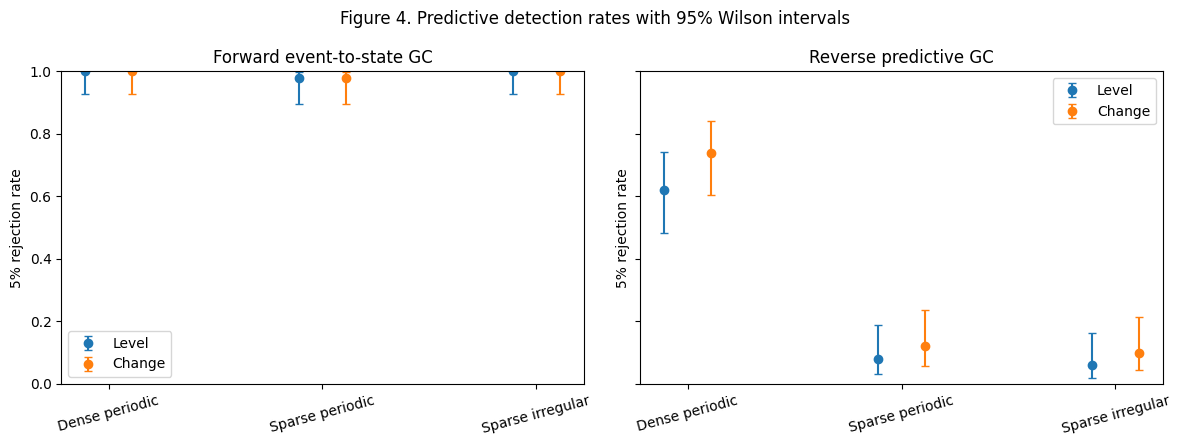

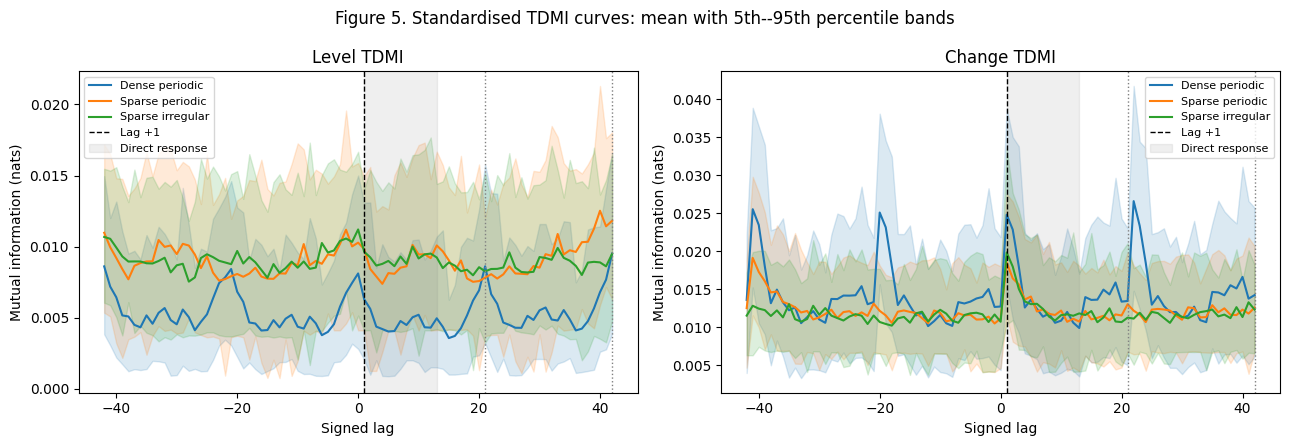

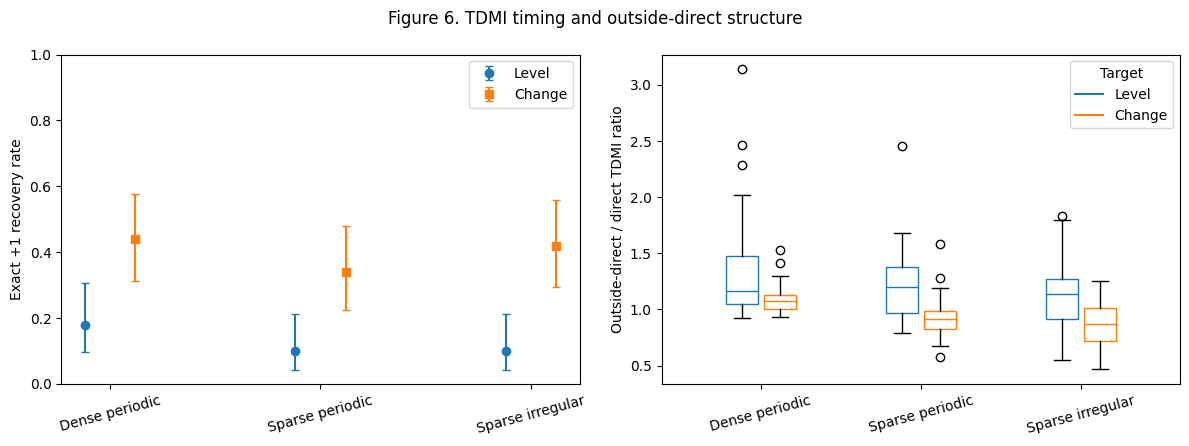

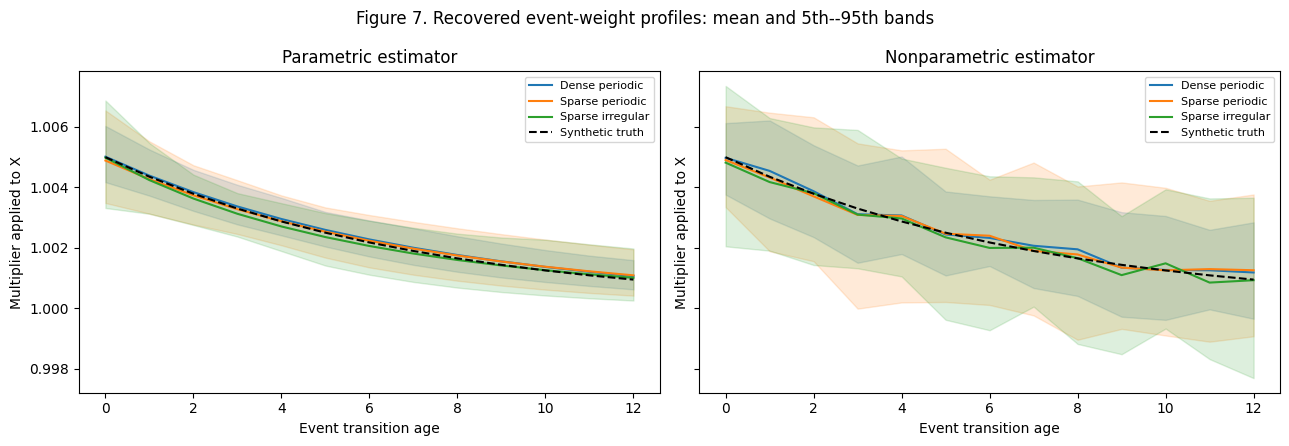

Saved Figures 4--7 at 180 dpi.


In [30]:
from IPython.display import display

figure_files = []
def save_stage4_figure(figure, filename):
    output_path = stage4_figures_dir / filename
    figure.savefig(output_path, dpi=180, bbox_inches='tight')
    display(figure)
    plt.close(figure)
    figure_files.append(filename)

case_labels = [STAGE4_CASE_LABELS[name] for name in STAGE4_CASE_ORDER]
case_positions = np.arange(len(STAGE4_CASE_ORDER))
case_colours = {
    'dense_periodic': '#1f77b4',
    'sparse_periodic': '#ff7f0e',
    'sparse_irregular': '#2ca02c',
}

# Figure 4: forward and reverse predictive detection.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for axis, metrics, title in [
    (axes[0], ('gc_level_detected_5pct', 'gc_change_detected_5pct'), 'Forward event-to-state GC'),
    (axes[1], ('reverse_gc_level_detected_5pct', 'reverse_gc_change_detected_5pct'), 'Reverse predictive GC'),
]:
    for offset, (metric, label) in enumerate(zip(metrics, ('Level', 'Change'))):
        rows = [rate_case_row(metric, case) for case in STAGE4_CASE_ORDER]
        rates = np.array([row.rate for row in rows])
        lower = np.array([row.ci_95_lower for row in rows])
        upper = np.array([row.ci_95_upper for row in rows])
        axis.errorbar(
            case_positions + (offset - 0.5) * 0.22, rates,
            yerr=[rates - lower, upper - rates], fmt='o', capsize=3,
            label=label,
        )
    axis.set_title(title)
    axis.set_xticks(case_positions, case_labels, rotation=15)
    axis.set_ylim(0, 1)
    axis.set_ylabel('5% rejection rate')
    axis.legend()
fig.suptitle('Figure 4. Predictive detection rates with 95% Wilson intervals')
fig.tight_layout()
save_stage4_figure(fig, 'figure_4_forward_reverse_detection.png')

# Figure 5: complete signed-lag TDMI curves.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)
for axis, target in zip(axes, ('level', 'change')):
    for case_name in STAGE4_CASE_ORDER:
        table = stage4_tdmi_curve_summary.loc[
            stage4_tdmi_curve_summary.case_name.eq(case_name)
            & stage4_tdmi_curve_summary.target.eq(target)
        ].sort_values('lag')
        axis.plot(
            table.lag, table['mean'], label=STAGE4_CASE_LABELS[case_name],
            color=case_colours[case_name],
        )
        axis.fill_between(
            table.lag, table.q05, table.q95,
            color=case_colours[case_name], alpha=0.16,
        )
    axis.axvline(1, color='black', linestyle='--', linewidth=1, label='Lag +1')
    axis.axvspan(1, RESPONSE_HORIZON_STEPS + 1, color='grey', alpha=0.12, label='Direct response')
    axis.axvline(21, color='grey', linestyle=':', linewidth=1)
    axis.axvline(42, color='grey', linestyle=':', linewidth=1)
    axis.set_title(f'{target.title()} TDMI')
    axis.set_xlabel('Signed lag')
    axis.set_ylabel('Mutual information (nats)')
    axis.legend(fontsize=8)
fig.suptitle('Figure 5. Standardised TDMI curves: mean with 5th--95th percentile bands')
fig.tight_layout()
save_stage4_figure(fig, 'figure_5_standardised_tdmi_curves.png')

# Figure 6: exact recovery and outside-direct structure.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for target, offset, marker, colour in [
    ('level', -0.12, 'o', '#1f77b4'),
    ('change', 0.12, 's', '#ff7f0e'),
]:
    rows = [rate_case_row(f'tdmi_{target}_exact_plus_1_recovered', case)
            for case in STAGE4_CASE_ORDER]
    rates = np.array([row.rate for row in rows])
    lower = np.array([row.ci_95_lower for row in rows])
    upper = np.array([row.ci_95_upper for row in rows])
    axes[0].errorbar(
        case_positions + offset, rates, yerr=[rates - lower, upper - rates],
        fmt=marker, capsize=3, label=target.title(),
    )
    data = [stage4_seed_case_analysis.loc[
        stage4_seed_case_analysis.case_name.eq(case),
        f'tdmi_{target}_outside_direct_to_direct_ratio',
    ].to_numpy(dtype=float) for case in STAGE4_CASE_ORDER]
    box = axes[1].boxplot(
        data, positions=case_positions + offset, widths=0.2, showfliers=True,
        patch_artist=True, boxprops={'facecolor': 'none', 'edgecolor': colour},
        medianprops={'color': colour},
    )
    axes[1].plot([], [], color=colour, label=target.title())
axes[0].set_xticks(case_positions, case_labels, rotation=15)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('Exact +1 recovery rate')
axes[0].legend()
axes[1].set_xticks(case_positions, case_labels, rotation=15)
axes[1].set_ylabel('Outside-direct / direct TDMI ratio')
axes[1].legend(title='Target')
fig.suptitle('Figure 6. TDMI timing and outside-direct structure')
fig.tight_layout()
save_stage4_figure(fig, 'figure_6_tdmi_timing_outside_direct.png')

# Figure 7: recovered event-weight profiles.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for axis, estimator in zip(axes, ('parametric', 'nonparametric')):
    for case_name in STAGE4_CASE_ORDER:
        table = stage4_profile_age_summary.loc[
            stage4_profile_age_summary.case_name.eq(case_name)
            & stage4_profile_age_summary.estimator.eq(estimator)
        ].sort_values('event_age')
        axis.plot(
            table.event_age, table.estimated_multiplier_mean,
            color=case_colours[case_name], label=STAGE4_CASE_LABELS[case_name],
        )
        axis.fill_between(
            table.event_age, table.estimated_multiplier_q05,
            table.estimated_multiplier_q95,
            color=case_colours[case_name], alpha=0.16,
        )
    truth_profile = stage4_profile_age_summary.loc[
        stage4_profile_age_summary.case_name.eq(STAGE4_CASE_ORDER[0])
        & stage4_profile_age_summary.estimator.eq(estimator)
    ].sort_values('event_age')
    axis.plot(
        truth_profile.event_age, truth_profile.true_multiplier,
        color='black', linestyle='--', linewidth=1.5, label='Synthetic truth',
    )
    axis.set_title(f'{estimator.title()} estimator')
    axis.set_xlabel('Event transition age')
    axis.set_ylabel('Multiplier applied to X')
    axis.legend(fontsize=8)
fig.suptitle('Figure 7. Recovered event-weight profiles: mean and 5th--95th bands')
fig.tight_layout()
save_stage4_figure(fig, 'figure_7_recovered_event_weight_profiles.png')
print('Saved Figures 4--7 at 180 dpi.')

### Figures 8--12

The remaining figures retain profile-error, forecast-gain, calibration, sharpness, and same-seed contrast distributions. Boxplot fliers and negative gains remain visible; the contrast panels show comparison minus reference with a zero reference line.

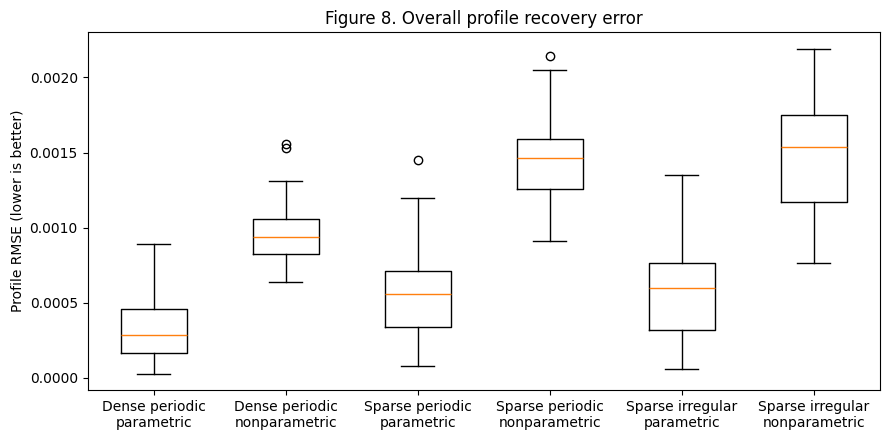

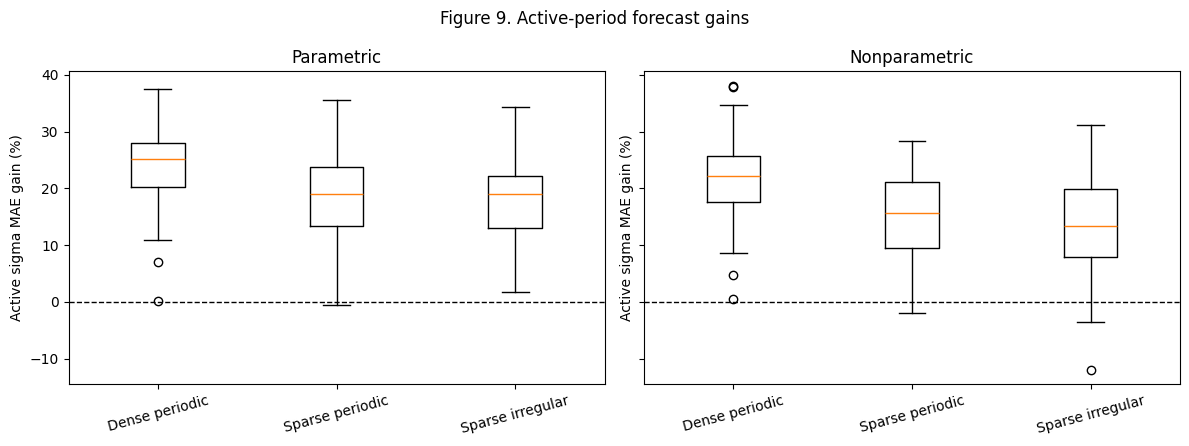

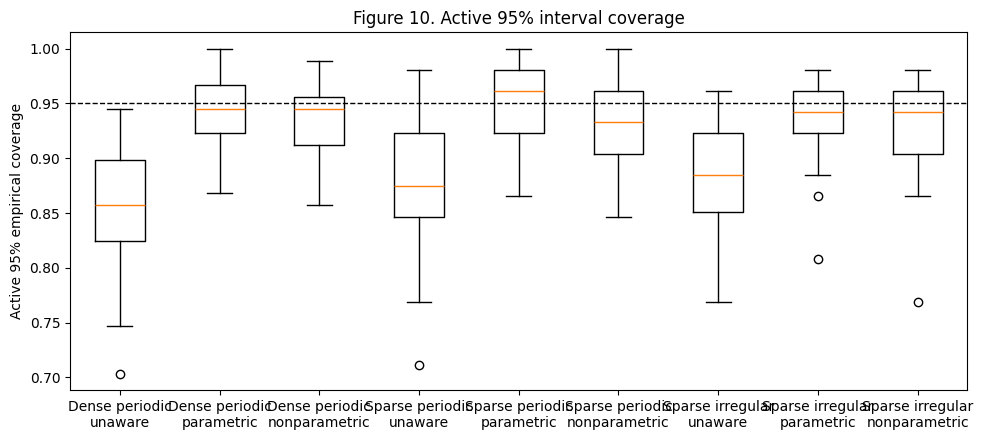

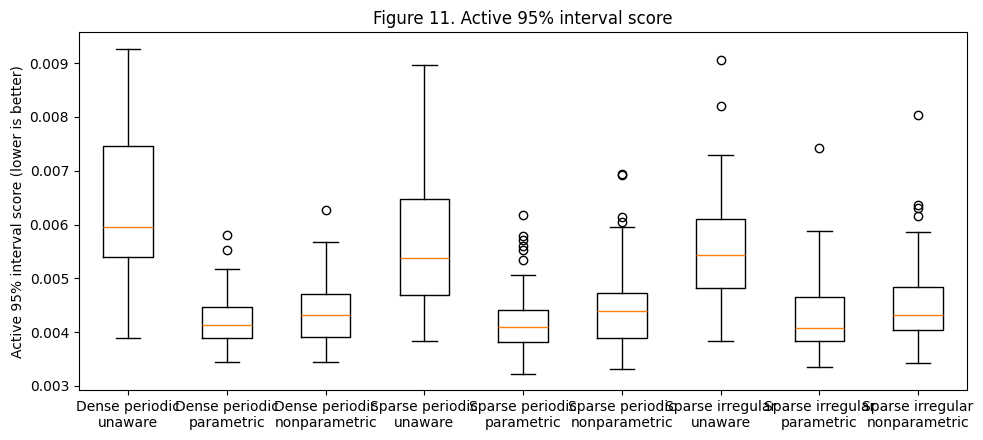

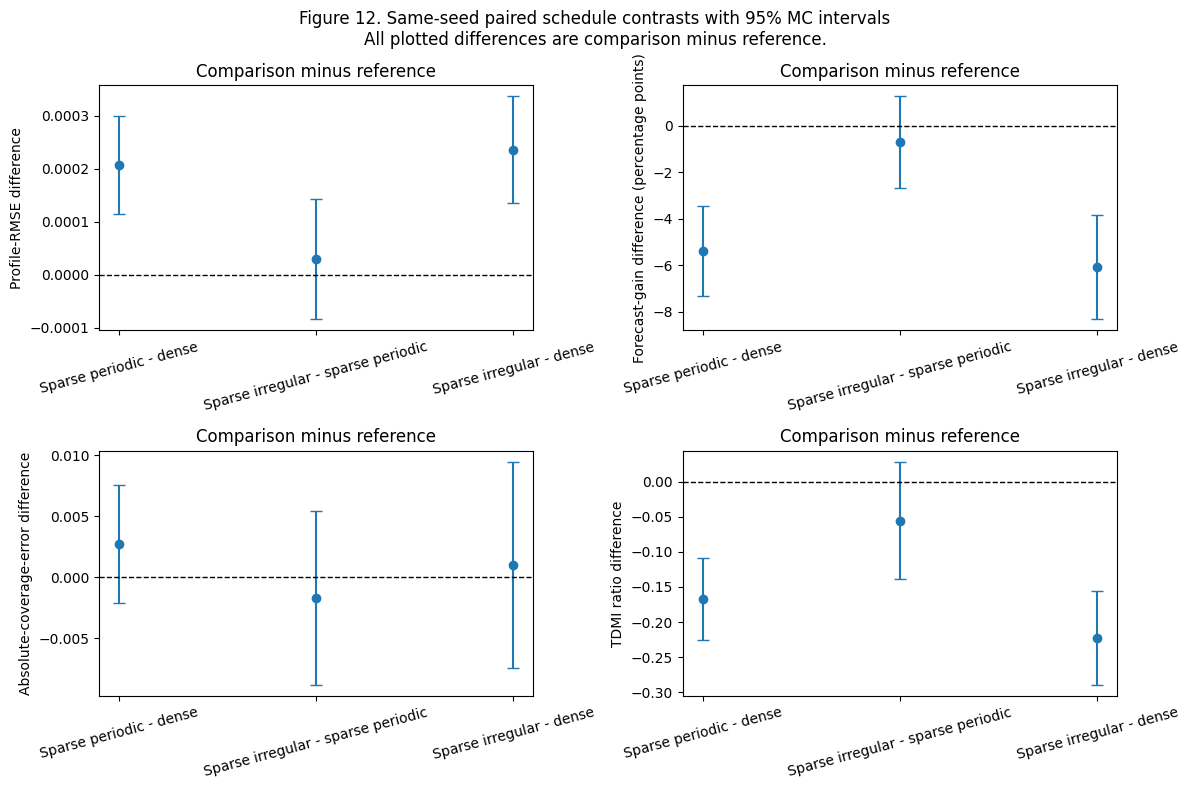

Saved Figures 8--12 at 180 dpi.


In [31]:
# Figure 8: overall profile recovery error.
fig, ax = plt.subplots(figsize=(9, 4.5))
data, labels = [], []
for case_name in STAGE4_CASE_ORDER:
    for estimator in ('parametric', 'nonparametric'):
        data.append(stage4_seed_case_analysis.loc[
            stage4_seed_case_analysis.case_name.eq(case_name),
            f'{estimator}_profile_RMSE',
        ].to_numpy(dtype=float))
        labels.append(f'{STAGE4_CASE_LABELS[case_name]}\n{estimator}')
ax.boxplot(data, tick_labels=labels, showfliers=True)
ax.set_ylabel('Profile RMSE (lower is better)')
ax.set_title('Figure 8. Overall profile recovery error')
fig.tight_layout()
save_stage4_figure(fig, 'figure_8_profile_recovery_error.png')

# Figure 9: active forecast gains.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for axis, estimator in zip(axes, ('parametric', 'nonparametric')):
    data = [stage4_seed_case_analysis.loc[
        stage4_seed_case_analysis.case_name.eq(case),
        f'active_sigma_{estimator}_MAE_gain_pct',
    ].to_numpy(dtype=float) for case in STAGE4_CASE_ORDER]
    axis.boxplot(data, tick_labels=case_labels, showfliers=True)
    axis.axhline(0, color='black', linestyle='--', linewidth=1)
    axis.set_title(estimator.title())
    axis.set_ylabel('Active sigma MAE gain (%)')
    axis.tick_params(axis='x', rotation=15)
fig.suptitle('Figure 9. Active-period forecast gains')
fig.tight_layout()
save_stage4_figure(fig, 'figure_9_active_forecast_gains.png')

# Figure 10: active interval coverage.
fig, ax = plt.subplots(figsize=(10, 4.5))
data, labels = [], []
for case_name in STAGE4_CASE_ORDER:
    for model in ('unaware', 'parametric', 'nonparametric'):
        data.append(stage4_seed_case_analysis.loc[
            stage4_seed_case_analysis.case_name.eq(case_name),
            f'active_95_state_{model}_coverage',
        ].to_numpy(dtype=float))
        labels.append(f'{STAGE4_CASE_LABELS[case_name]}\n{model}')
ax.boxplot(data, tick_labels=labels, showfliers=True)
ax.axhline(0.95, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('Active 95% empirical coverage')
ax.set_title('Figure 10. Active 95% interval coverage')
fig.tight_layout()
save_stage4_figure(fig, 'figure_10_active_95_coverage.png')

# Figure 11: active interval score.
fig, ax = plt.subplots(figsize=(10, 4.5))
data, labels = [], []
for case_name in STAGE4_CASE_ORDER:
    for model in ('unaware', 'parametric', 'nonparametric'):
        data.append(stage4_seed_case_analysis.loc[
            stage4_seed_case_analysis.case_name.eq(case_name),
            f'active_95_state_{model}_interval_score',
        ].to_numpy(dtype=float))
        labels.append(f'{STAGE4_CASE_LABELS[case_name]}\n{model}')
ax.boxplot(data, tick_labels=labels, showfliers=True)
ax.set_ylabel('Active 95% interval score (lower is better)')
ax.set_title('Figure 11. Active 95% interval score')
fig.tight_layout()
save_stage4_figure(fig, 'figure_11_active_95_interval_score.png')

# Figure 12: same-seed paired schedule contrasts.
figure_12_metrics = [
    ('parametric_profile_RMSE', 'Profile-RMSE difference'),
    ('active_sigma_parametric_MAE_gain_pct', 'Forecast-gain difference (percentage points)'),
    ('parametric_absolute_coverage_error', 'Absolute-coverage-error difference'),
    ('tdmi_change_outside_direct_to_direct_ratio', 'TDMI ratio difference'),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for axis, (metric, ylabel) in zip(axes.ravel(), figure_12_metrics):
    rows = [paired_summary_row(name, metric) for name in STAGE4_CONTRASTS]
    means = np.array([row['mean'] for row in rows])
    lower = np.array([row['ci_95_lower'] for row in rows])
    upper = np.array([row['ci_95_upper'] for row in rows])
    positions = np.arange(len(rows))
    axis.errorbar(
        positions, means, yerr=[means - lower, upper - means],
        fmt='o', capsize=4,
    )
    axis.axhline(0, color='black', linestyle='--', linewidth=1)
    axis.set_xticks(
        positions,
        [
            'Sparse periodic - dense',
            'Sparse irregular - sparse periodic',
            'Sparse irregular - dense',
        ],
        rotation=15,
    )
    axis.set_ylabel(ylabel)
    axis.set_title('Comparison minus reference')
fig.suptitle('Figure 12. Same-seed paired schedule contrasts with 95% MC intervals\nAll plotted differences are comparison minus reference.')
fig.tight_layout()
save_stage4_figure(fig, 'figure_12_same_seed_paired_contrasts.png')

assert len(figure_files) == 9
print('Saved Figures 8--12 at 180 dpi.')

## 34. Question-level evidence table

The evidence table links the pre-specified scientific questions to case summaries and same-seed paired contrasts. It records what the tables show without hard-coding a favourable conclusion or treating a nonzero interval as economic importance.

In [32]:
def format_case_summary(metric, case_name):
    registry_row = stage4_metric_registry.loc[
        stage4_metric_registry.metric.eq(metric)
    ].iloc[0]
    if registry_row.value_type == 'binary':
        row = rate_case_row(metric, case_name)
        return f"rate={row.rate:.3f} [{row.ci_95_lower:.3f}, {row.ci_95_upper:.3f}]"
    row = numeric_case_row(metric, case_name)
    return f"mean={row['mean']:.6g}; median={row['median']:.6g}"


def contrast_evidence_row(question, contrast_name, metric, limit):
    contrast = STAGE4_CONTRASTS[contrast_name]
    paired = paired_summary_row(contrast_name, metric)
    direction = stage4_metric_registry.loc[
        stage4_metric_registry.metric.eq(metric), 'favourable_direction'
    ].iat[0]
    return {
        'question': question,
        'primary_contrast': contrast_name,
        'metric': metric,
        'reference_case': contrast['reference_case'],
        'comparison_case': contrast['comparison_case'],
        'reference_summary': format_case_summary(metric, contrast['reference_case']),
        'comparison_summary': format_case_summary(metric, contrast['comparison_case']),
        'mean_paired_difference': paired['mean'],
        'ci_95_lower': paired['ci_95_lower'],
        'ci_95_upper': paired['ci_95_upper'],
        'median_paired_difference': paired['median'],
        'interval_excludes_zero': paired['interval_excludes_zero'],
        'favourable_direction': direction,
        'interpretive_limit': limit,
    }

evidence_specs = [
    (
        'Does forward GC remain reliable?',
        'sparse_irregular_minus_sparse_periodic',
        'gc_change_detected_5pct',
        'Rejection frequency is predictive, not structural causal accuracy.',
    ),
    (
        'Does reverse predictive rejection weaken under irregular timing?',
        'sparse_irregular_minus_sparse_periodic',
        'reverse_gc_change_detected_5pct',
        'Reverse GC reflects event-cycle predictability, not structural state-to-event causality.',
    ),
    (
        'Do outside-direct TDMI peaks weaken?',
        'sparse_irregular_minus_sparse_periodic',
        'tdmi_change_outside_direct_to_direct_ratio',
        'Outside-direct structure is not labelled an alias without a demonstrated periodic relationship.',
    ),
    (
        'Does exact +1 lag recovery improve?',
        'sparse_irregular_minus_sparse_periodic',
        'tdmi_change_exact_plus_1_recovered',
        'TDMI is a dependence diagnostic, not interventionist proof.',
    ),
    (
        'How does reduced event count affect profile recovery?',
        'sparse_periodic_minus_dense_periodic',
        'parametric_profile_RMSE',
        'This contrast changes both event count and event frequency.',
    ),
    (
        'How does reduced event count affect profile recovery?',
        'sparse_periodic_minus_dense_periodic',
        'nonparametric_profile_RMSE',
        'This contrast changes both event count and event frequency.',
    ),
    (
        'How much forecast improvement depends on predictable timing?',
        'sparse_irregular_minus_sparse_periodic',
        'active_sigma_parametric_MAE_gain_pct',
        'Negative gains remain in the paired distribution.',
    ),
    (
        'How much forecast improvement depends on predictable timing?',
        'sparse_irregular_minus_sparse_periodic',
        'active_sigma_nonparametric_MAE_gain_pct',
        'Negative gains remain in the paired distribution.',
    ),
    (
        'Are coverage and interval scores stable?',
        'sparse_irregular_minus_sparse_periodic',
        'parametric_absolute_coverage_error',
        'Coverage error and sharpness should be interpreted jointly.',
    ),
    (
        'Are coverage and interval scores stable?',
        'sparse_irregular_minus_sparse_periodic',
        'active_95_state_parametric_interval_score',
        'Interval score is lower-is-better but not a complete uncertainty measure.',
    ),
]
evidence_rows = [contrast_evidence_row(*spec) for spec in evidence_specs]

for metric in (
    'parametric_profile_RMSE', 'nonparametric_profile_RMSE',
    'active_sigma_parametric_MAE_gain_pct',
    'active_sigma_nonparametric_MAE_gain_pct',
    'tdmi_change_outside_direct_to_direct_ratio',
):
    reference_row = numeric_case_row(metric, 'sparse_periodic')
    comparison_row = numeric_case_row(metric, 'sparse_irregular')
    for statistic in ('standard_deviation', 'q05_q95_width'):
        evidence_rows.append({
            'question': 'Does irregular timing increase Monte Carlo dispersion?',
            'primary_contrast': 'sparse_irregular_minus_sparse_periodic',
            'metric': f'{metric}:{statistic}',
            'reference_case': 'sparse_periodic',
            'comparison_case': 'sparse_irregular',
            'reference_summary': f'{statistic}={reference_row[statistic]:.6g}',
            'comparison_summary': f'{statistic}={comparison_row[statistic]:.6g}',
            'mean_paired_difference': np.nan,
            'ci_95_lower': np.nan,
            'ci_95_upper': np.nan,
            'median_paired_difference': np.nan,
            'interval_excludes_zero': np.nan,
            'favourable_direction': 'descriptive',
            'interpretive_limit': (
                'Larger cross-seed dispersion is descriptive evidence, not proof '
                'of a universally more uncertain process.'
            ),
        })
stage4_question_evidence = pd.DataFrame(evidence_rows)

selected_contrast_metrics = [
    'gc_change_partial_r_squared',
    'reverse_gc_change_partial_R_squared',
    'tdmi_change_outside_direct_to_direct_ratio',
    'tdmi_change_exact_plus_1_recovered',
    'parametric_profile_RMSE',
    'nonparametric_profile_RMSE',
    'active_sigma_parametric_MAE_gain_pct',
    'active_sigma_nonparametric_MAE_gain_pct',
    'parametric_absolute_coverage_error',
    'nonparametric_absolute_coverage_error',
    'active_95_state_parametric_interval_score',
    'active_95_state_nonparametric_interval_score',
]
stage4_key_contrasts = stage4_paired_contrast_summary.loc[
    stage4_paired_contrast_summary.metric.isin(selected_contrast_metrics)
].copy()
stage4_key_contrasts['contrast_name'] = pd.Categorical(
    stage4_key_contrasts['contrast_name'],
    categories=list(STAGE4_CONTRASTS), ordered=True,
)
stage4_key_contrasts = stage4_key_contrasts.sort_values(
    ['contrast_name', 'metric']
).reset_index(drop=True)

stage4_checkpoint_files = {
    'stage4_seed_case_analysis.csv': stage4_seed_case_analysis,
    'stage4_metric_registry.csv': stage4_metric_registry,
    'stage4_case_numeric_summary.csv': stage4_case_numeric_summary,
    'stage4_case_rate_summary.csv': stage4_case_rate_summary,
    'stage4_paired_contrasts_raw.csv': stage4_paired_contrasts_raw,
    'stage4_paired_contrast_summary.csv': stage4_paired_contrast_summary,
    'stage4_tdmi_curve_summary.csv': stage4_tdmi_curve_summary,
    'stage4_tdmi_lag_category_summary.csv': stage4_tdmi_lag_category_summary,
    'stage4_profile_age_summary.csv': stage4_profile_age_summary,
    'stage4_question_evidence.csv': stage4_question_evidence,
}
for filename, table in stage4_checkpoint_files.items():
    table.to_csv(results_dir_10 / filename, index=False)

stage4_manifest = {
    'stage_name': 'Notebook 10 Stage 4 schedule aggregation',
    'checkpoint_version': 1,
    'source_stage3_checkpoint_version': 1,
    'case_order': list(STAGE4_CASE_ORDER),
    'case_labels': STAGE4_CASE_LABELS,
    'contrasts': STAGE4_CONTRASTS,
    'number_of_complete_seeds': int(len(complete_seeds)),
    'numeric_interval_method': 'two-sided 95% Student-t interval for MC mean',
    'rate_interval_method': '95% Wilson interval',
    'nominal_interval_coverage': 0.95,
    'figure_files': figure_files,
}
(results_dir_10 / 'stage4_manifest.json').write_text(
    json.dumps(stage4_manifest, indent=2), encoding='utf-8'
)

assert len(complete_seeds) == 50
assert len(stage4_seed_case_analysis) == 150
assert stage4_seed_case_analysis.groupby('market_seed', observed=True).size().eq(3).all()
assert not stage4_seed_case_analysis.duplicated(['market_seed', 'case_name']).any()
assert stage4_paired_contrasts_raw.groupby(['contrast_name', 'metric']).size().eq(50).all()
assert stage4_profile_age_summary.filter(like='_count').eq(50).all().all()
assert stage4_tdmi_curve_summary['count'].eq(50).all()
for rate_table in (
    stage4_case_rate_summary,
    stage4_tdmi_lag_category_summary,
):
    assert rate_table[['ci_95_lower', 'ci_95_upper']].apply(
        lambda column: column.between(0, 1).all()
    ).all()
for numeric_summary in (
    stage4_case_numeric_summary,
    stage4_paired_contrast_summary,
):
    assert (numeric_summary.ci_95_lower <= numeric_summary['mean']).all()
    assert (numeric_summary['mean'] <= numeric_summary.ci_95_upper).all()
for table in [
    stage4_seed_case_analysis, stage4_case_numeric_summary,
    stage4_case_rate_summary, stage4_paired_contrasts_raw,
    stage4_paired_contrast_summary, stage4_tdmi_curve_summary,
    stage4_tdmi_lag_category_summary, stage4_profile_age_summary,
]:
    numeric_values = table.select_dtypes(include=[np.number]).to_numpy(dtype=float)
    assert not np.isinf(numeric_values).any()
def assert_no_callable_cells(table, table_name):
    callable_mask = table.map(callable)
    assert not callable_mask.any().any(), (
        f'{table_name} contains a method or other callable instead of a displayed value.'
    )


display_tables = {
    'stage4_detection_display': stage4_detection_display,
    'stage4_tdmi_display': stage4_tdmi_display,
    'stage4_recovery_display': stage4_recovery_display,
    'stage4_forecast_display': stage4_forecast_display,
    'stage4_calibration_display': stage4_calibration_display,
}
for table_name, table in display_tables.items():
    assert_no_callable_cells(table, table_name)
    metric_columns = [
        column for column in table.columns
        if column not in {'case_name', 'case_label', 'model'}
    ]
    for column in metric_columns:
        assert pd.api.types.is_numeric_dtype(table[column]), (
            f'{table_name}.{column} is not numeric.'
        )

expected_stage4_files = set(stage4_checkpoint_files).union({'stage4_manifest.json'})
assert expected_stage4_files.issubset({path.name for path in results_dir_10.iterdir()})
assert all((stage4_figures_dir / filename).exists() for filename in figure_files)

display(stage4_detection_display)
display(stage4_tdmi_display)
display(stage4_recovery_display)
display(stage4_forecast_display)
display(stage4_calibration_display)
display(stage4_key_contrasts)
print('Stage 4 aggregate tables, figures and checkpoint validations passed.')

,case_name,case_label,forward_GC_level_detection_rate,forward_GC_change_detection_rate,reverse_GC_level_rejection_rate,reverse_GC_change_rejection_rate,conditional_event_history_median_partial_R_squared
0,dense_periodic,Dense periodic,1.00,1.00,0.62,0.74,0.173451
1,sparse_periodic,Sparse periodic,0.98,0.98,0.08,0.12,0.118194
2,sparse_irregular,Sparse irregular,1.00,1.00,0.06,0.10,0.124674


,case_name,case_label,level_exact_plus_1_recovery_rate,change_exact_plus_1_recovery_rate,level_at_plus_1_median,level_outside_direct_to_direct_ratio_median,level_global_nonzero_peak_lag_median,change_at_plus_1_median,change_outside_direct_to_direct_ratio_median,change_global_nonzero_peak_lag_median
0,dense_periodic,Dense periodic,0.18,0.44,0.005051,1.163583,-22.0,0.023820,1.075782,1.5
1,sparse_periodic,Sparse periodic,0.10,0.34,0.010941,1.201414,13.5,0.018085,0.912024,-1.0
2,sparse_irregular,Sparse irregular,0.10,0.42,0.010920,1.138791,-2.5,0.019104,0.866557,2.0


,case_name,case_label,median_absolute_A_error,median_absolute_lambda_error,median_parametric_profile_RMSE,median_nonparametric_profile_RMSE
0,dense_periodic,Dense periodic,0.000756,4.998349,0.000289,0.000939
1,sparse_periodic,Sparse periodic,0.001212,8.299854,0.000555,0.001463
2,sparse_irregular,Sparse irregular,0.001312,15.125456,0.000602,0.001538


,case_name,case_label,median_parametric_active_sigma_MAE_gain_pct,parametric_positive_gain_rate,median_nonparametric_active_sigma_MAE_gain_pct,nonparametric_positive_gain_rate
0,dense_periodic,Dense periodic,25.187507,1.00,22.131774,1.00
1,sparse_periodic,Sparse periodic,19.004867,0.98,15.722658,0.98
2,sparse_irregular,Sparse irregular,18.943356,1.00,13.420914,0.92


,case_name,case_label,model,mean_active_95_coverage,mean_absolute_coverage_error,median_average_width,median_interval_score
0,dense_periodic,Dense periodic,unaware,0.854066,0.095934,0.003472,0.005952
1,dense_periodic,Dense periodic,parametric,0.947033,0.025912,0.003480,0.004134
2,dense_periodic,Dense periodic,nonparametric,0.936923,0.026901,0.003481,0.004314
3,sparse_periodic,Sparse periodic,unaware,0.876154,0.076462,0.003462,0.005380
4,sparse_periodic,Sparse periodic,parametric,0.950000,0.028615,0.003472,0.004090
5,sparse_periodic,Sparse periodic,nonparametric,0.931154,0.036846,0.003472,0.004384
6,sparse_irregular,Sparse irregular,unaware,0.886538,0.064846,0.003462,0.005440
7,sparse_irregular,Sparse irregular,parametric,0.939231,0.026923,0.003472,0.004085
8,sparse_irregular,Sparse irregular,nonparametric,0.929231,0.033077,0.003472,0.004326


,contrast_name,reference_case,comparison_case,scientific_role,metric,favourable_direction,units,count,mean,standard_deviation,...,median,q05,q25,q75,q95,q05_q95_width,fraction_above_zero,fraction_below_zero,fraction_equal_zero,interval_excludes_zero
0,sparse_periodic_minus_dense_periodic,dense_periodic,sparse_periodic,Effect of reducing event frequency and event c...,active_95_state_nonparametric_interval_score,lower,powered-state or sigma units,50,1.486397e-04,0.000517,...,0.000123,-0.000609,-0.000146,0.000459,0.001145,0.001753,0.60,0.40,0.00,True
1,sparse_periodic_minus_dense_periodic,dense_periodic,sparse_periodic,Effect of reducing event frequency and event c...,active_95_state_parametric_interval_score,lower,powered-state or sigma units,50,6.401156e-07,0.000357,...,-0.000018,-0.000631,-0.000172,0.000154,0.000557,0.001188,0.48,0.52,0.00,False
2,sparse_periodic_minus_dense_periodic,dense_periodic,sparse_periodic,Effect of reducing event frequency and event c...,active_sigma_nonparametric_MAE_gain_pct,higher,percentage points,50,-6.548255e+00,7.547587,...,-6.112035,-17.359119,-10.365620,-2.169939,5.099139,22.458258,0.16,0.84,0.00,True
3,sparse_periodic_minus_dense_periodic,dense_periodic,sparse_periodic,Effect of reducing event frequency and event c...,active_sigma_parametric_MAE_gain_pct,higher,percentage points,50,-5.385690e+00,6.877969,...,-4.176210,-16.121044,-11.045618,-0.736846,5.636563,21.757607,0.24,0.76,0.00,True
4,sparse_periodic_minus_dense_periodic,dense_periodic,sparse_periodic,Effect of reducing event frequency and event c...,gc_change_partial_r_squared,higher,partial R-squared,50,-3.041225e-02,0.021789,...,-0.027169,-0.067028,-0.045382,-0.016661,0.001157,0.068185,0.08,0.92,0.00,True
5,sparse_periodic_minus_dense_periodic,dense_periodic,sparse_periodic,Effect of reducing event frequency and event c...,nonparametric_absolute_coverage_error,lower,probability,50,9.945055e-03,0.025039,...,0.010989,-0.028984,-0.005495,0.024725,0.048269,0.077253,0.62,0.34,0.04,True
6,sparse_periodic_minus_dense_periodic,dense_periodic,sparse_periodic,Effect of reducing event frequency and event c...,nonparametric_profile_RMSE,lower,event-weight multiplier units,50,4.835465e-04,0.000239,...,0.000474,0.000088,0.000386,0.000678,0.000819,0.000731,0.98,0.02,0.00,True
7,sparse_periodic_minus_dense_periodic,dense_periodic,sparse_periodic,Effect of reducing event frequency and event c...,parametric_absolute_coverage_error,lower,probability,50,2.703297e-03,0.017056,...,0.002747,-0.027115,-0.008242,0.013049,0.026236,0.053352,0.54,0.40,0.06,False
8,sparse_periodic_minus_dense_periodic,dense_periodic,sparse_periodic,Effect of reducing event frequency and event c...,parametric_profile_RMSE,lower,event-weight multiplier units,50,2.067994e-04,0.000325,...,0.000248,-0.000284,-0.000014,0.000422,0.000704,0.000988,0.74,0.26,0.00,True
9,sparse_periodic_minus_dense_periodic,dense_periodic,sparse_periodic,Effect of reducing event frequency and event c...,reverse_gc_change_partial_R_squared,descriptive,partial R-squared,50,-2.729224e-02,0.016403,...,-0.027245,-0.053716,-0.037798,-0.016395,-0.001605,0.052111,0.04,0.96,0.00,True


Stage 4 aggregate tables, figures and checkpoint validations passed.


## 35. Stage 4 status

Stage 4 used only the loaded Stage 3 checkpoints and analysed 50 complete paired seeds. Every contrast is same-seed and oriented as comparison minus reference. Sparse periodic versus dense periodic changes both event frequency and event count; sparse irregular versus sparse periodic isolates timing irregularity more cleanly. Negative forecast gains, reverse predictive rejections, TDMI boundary peaks, and calibration errors remain visible in the saved tables and figures. GC and TDMI remain predictive or dependence diagnostics rather than interventionist proof.

Stage 4 aggregation is complete and retained as an auditable checkpoint layer.

## 36. Stage 5 interpretation conventions

Stage 5 uses only the loaded Stage 3 and Stage 4 checkpoint tables. Schedule comparisons use same-seed paired summaries, with the difference always defined as comparison minus reference. A 95% Monte Carlo interval describes uncertainty in the mean paired difference across the frozen seeds; GC, TDMI, and reverse GC remain predictive or dependence diagnostics rather than interventionist causal identification.

In [33]:
assert RUN_STAGE3_REPEATED_EXPERIMENT is False
assert checkpoint_loading_mode_passed
assert stage3_failure_log.empty
assert stage3_seed_completion['paired_triplet_complete'].all()
assert len(stage3_seed_completion) == 50
assert len(stage4_seed_case_analysis) == 150


def stage5_case_value(metric, case_name):
    registry_row = stage4_metric_registry.loc[
        stage4_metric_registry.metric.eq(metric)
    ].iloc[0]
    if registry_row.value_type == 'binary':
        return float(rate_case_row(metric, case_name)['rate'])
    return float(numeric_case_row(metric, case_name)['mean'])


def stage5_paired_row(contrast_name, metric):
    return paired_summary_row(contrast_name, metric)


def stage5_evidence_classification(paired_row):
    if bool(paired_row['interval_excludes_zero']):
        return 'clear paired evidence'
    if abs(float(paired_row['mean'])) <= STAGE4_EQUALITY_TOLERANCE:
        return 'no systematic paired difference resolved'
    return 'directional but unresolved'


def stage5_interval_text(paired_row):
    return (
        'The Monte Carlo interval excludes zero.'
        if bool(paired_row['interval_excludes_zero'])
        else 'The Monte Carlo interval includes zero.'
    )

print('Stage 5 synthesis uses loaded checkpoint tables only.')

Stage 5 synthesis uses loaded checkpoint tables only.


## 37. Final question-by-question findings

The final evidence table reads case means or rates from the Stage 4 summaries and paired effects from the corresponding same-seed contrast summary. It does not infer a paired effect by comparing independent case medians.

In [34]:
evidence_specs = [
    ('F1a', 'Does forward GC remain reliable?', 'sparse_periodic_minus_dense_periodic', 'gc_level_detected_5pct', 'Forward level-GC detection remains a predictive reliability diagnostic.', 'A high rejection rate is not perfect causal recovery.'),
    ('F1b', 'Does forward GC remain reliable?', 'sparse_periodic_minus_dense_periodic', 'gc_change_detected_5pct', 'Forward change-GC detection remains a predictive reliability diagnostic.', 'A high rejection rate is not perfect causal recovery.'),
    ('F1c', 'Does forward GC remain reliable?', 'sparse_periodic_minus_dense_periodic', 'gc_change_partial_r_squared', 'This contrasts the forward change-GC effect size under sparse versus dense schedules.', 'Sparse periodic minus dense changes event count, frequency and active-transition count together.'),
    ('F1d', 'Does forward GC remain reliable?', 'sparse_irregular_minus_sparse_periodic', 'gc_change_partial_r_squared', 'This is the matched-count comparison for timing irregularity in forward change-GC effect size.', 'GC is predictive dependence rather than interventionist identification.'),
    ('F2a', 'Does reverse predictive rejection weaken under sparse schedules?', 'sparse_periodic_minus_dense_periodic', 'reverse_gc_level_detected_5pct', 'This describes reverse predictive level-GC rejection.', 'It does not imply that volatility causes scheduled events.'),
    ('F2b', 'Does reverse predictive rejection weaken under sparse schedules?', 'sparse_periodic_minus_dense_periodic', 'reverse_gc_change_detected_5pct', 'This describes reverse predictive change-GC rejection.', 'It does not imply that volatility causes scheduled events.'),
    ('F2c', 'Does reverse predictive rejection weaken under sparse schedules?', 'sparse_periodic_minus_dense_periodic', 'reverse_gc_change_partial_R_squared', 'This summarizes reverse predictive change-GC strength.', 'Dense deterministic repetition can create misleading reverse predictive structure.'),
    ('F2d', 'Does reverse predictive rejection weaken under irregular timing?', 'sparse_irregular_minus_sparse_periodic', 'reverse_gc_change_partial_R_squared', 'This is the matched-count comparison for reverse predictive change-GC.', 'It is a reverse predictive diagnostic, not structural causality.'),
    ('F3a', 'Do outside-direct TDMI peaks weaken?', 'sparse_periodic_minus_dense_periodic', 'tdmi_change_outside_direct_to_direct_ratio', 'This compares change-TDMI outside-direct structure as events become sparser.', 'Outside-direct structure is not automatically labelled a periodic alias.'),
    ('F3b', 'Do outside-direct TDMI peaks weaken?', 'sparse_irregular_minus_sparse_periodic', 'tdmi_change_outside_direct_to_direct_ratio', 'This compares change-TDMI outside-direct structure under matched sparse timing.', 'TDMI is lagged dependence, not causal identification.'),
    ('F3c', 'Do outside-direct TDMI peaks weaken?', 'sparse_irregular_minus_sparse_periodic', 'tdmi_level_outside_direct_to_direct_ratio', 'This compares level-TDMI outside-direct structure under matched sparse timing.', 'TDMI is lagged dependence, not causal identification.'),
    ('F4a', 'Does exact (+1) TDMI recovery improve?', 'sparse_irregular_minus_sparse_periodic', 'tdmi_level_exact_plus_1_recovered', 'This compares exact +1 level-TDMI recovery under matched sparse timing.', 'A detected dependence peak need not locate the exact structural lag.'),
    ('F4b', 'Does exact (+1) TDMI recovery improve?', 'sparse_irregular_minus_sparse_periodic', 'tdmi_change_exact_plus_1_recovered', 'This compares exact +1 change-TDMI recovery under matched sparse timing.', 'A detected dependence peak need not locate the exact structural lag.'),
    ('F5a', 'How does event scarcity affect profile recovery?', 'sparse_periodic_minus_dense_periodic', 'parametric_profile_RMSE', 'This compares parametric profile recovery as events become sparser.', 'The contrast combines lower frequency and fewer events.'),
    ('F5b', 'How does event scarcity affect profile recovery?', 'sparse_periodic_minus_dense_periodic', 'nonparametric_profile_RMSE', 'This compares non-parametric profile recovery as events become sparser.', 'The contrast combines lower frequency and fewer events.'),
    ('F5c', 'Does irregular timing alter profile recovery?', 'sparse_irregular_minus_sparse_periodic', 'parametric_profile_RMSE', 'This is the matched-count timing comparison for parametric profile recovery.', 'Synthetic truth remains post-fit evaluation only.'),
    ('F5d', 'Does irregular timing alter profile recovery?', 'sparse_irregular_minus_sparse_periodic', 'nonparametric_profile_RMSE', 'This is the matched-count timing comparison for non-parametric profile recovery.', 'Synthetic truth remains post-fit evaluation only.'),
    ('F5e', 'How accurately are amplitude and decay recovered?', 'sparse_periodic_minus_dense_periodic', 'A_absolute_error', 'This compares absolute amplitude recovery error.', 'Amplitude and decay are evaluated only after fitting.'),
    ('F5f', 'How accurately are amplitude and decay recovered?', 'sparse_periodic_minus_dense_periodic', 'lambda_absolute_error', 'This compares absolute decay-rate recovery error.', 'Amplitude and decay are evaluated only after fitting.'),
    ('F6a', 'How much forecast improvement depends on schedule?', 'sparse_periodic_minus_dense_periodic', 'active_sigma_parametric_MAE_gain_pct', 'This compares parametric active-period forecast gain as events become sparser.', 'Negative individual gains remain in the distribution.'),
    ('F6b', 'How much forecast improvement depends on schedule?', 'sparse_periodic_minus_dense_periodic', 'active_sigma_nonparametric_MAE_gain_pct', 'This compares non-parametric active-period forecast gain as events become sparser.', 'Negative individual gains remain in the distribution.'),
    ('F6c', 'How much forecast improvement depends on predictable timing?', 'sparse_irregular_minus_sparse_periodic', 'active_sigma_parametric_MAE_gain_pct', 'This is the matched-count timing comparison for parametric forecast gain.', 'It cannot establish that periodicity is required for forecast improvement.'),
    ('F6d', 'How much forecast improvement depends on predictable timing?', 'sparse_irregular_minus_sparse_periodic', 'active_sigma_nonparametric_MAE_gain_pct', 'This is the matched-count timing comparison for non-parametric forecast gain.', 'It cannot establish that periodicity is required for forecast improvement.'),
    ('F6e', 'How often are event-aware gains positive?', 'sparse_irregular_minus_sparse_periodic', 'parametric_positive_MAE_gain', 'This compares the rate of positive parametric gains.', 'The rate is descriptive of the frozen Monte Carlo seeds.'),
    ('F6f', 'How often are event-aware gains positive?', 'sparse_irregular_minus_sparse_periodic', 'nonparametric_positive_MAE_gain', 'This compares the rate of positive non-parametric gains.', 'The rate is descriptive of the frozen Monte Carlo seeds.'),
    ('F8a', 'Are coverage and interval scores stable?', 'sparse_irregular_minus_sparse_periodic', 'parametric_absolute_coverage_error', 'This compares parametric active-interval coverage error under matched sparse timing.', 'Coverage and sharpness are interpreted jointly.'),
    ('F8b', 'Are coverage and interval scores stable?', 'sparse_irregular_minus_sparse_periodic', 'nonparametric_absolute_coverage_error', 'This compares non-parametric active-interval coverage error under matched sparse timing.', 'Coverage and sharpness are interpreted jointly.'),
    ('F8c', 'Are coverage and interval scores stable?', 'sparse_irregular_minus_sparse_periodic', 'active_95_state_parametric_interval_score', 'This compares parametric active interval score under matched sparse timing.', 'A narrower interval is not automatically better.'),
    ('F8d', 'Are coverage and interval scores stable?', 'sparse_irregular_minus_sparse_periodic', 'active_95_state_nonparametric_interval_score', 'This compares non-parametric active interval score under matched sparse timing.', 'A narrower interval is not automatically better.'),
]
evidence_rows = []
for finding_id, question, contrast_name, metric, interpretation, qualification in evidence_specs:
    contrast = STAGE4_CONTRASTS[contrast_name]
    paired = stage5_paired_row(contrast_name, metric)
    evidence_rows.append({
        'finding_id': finding_id,
        'scientific_question': question,
        'primary_contrast': contrast_name,
        'primary_metric': metric,
        'reference_case': contrast['reference_case'],
        'comparison_case': contrast['comparison_case'],
        'reference_value': stage5_case_value(metric, contrast['reference_case']),
        'comparison_value': stage5_case_value(metric, contrast['comparison_case']),
        'mean_paired_difference': float(paired['mean']),
        'ci_95_lower': float(paired['ci_95_lower']),
        'ci_95_upper': float(paired['ci_95_upper']),
        'interval_excludes_zero': bool(paired['interval_excludes_zero']),
        'evidence_classification': stage5_evidence_classification(paired),
        'scientific_interpretation': interpretation + ' ' + stage5_interval_text(paired),
        'qualification': qualification,
    })
selected_dispersion_metrics = [
    'parametric_profile_RMSE',
    'nonparametric_profile_RMSE',
    'active_sigma_parametric_MAE_gain_pct',
    'active_sigma_nonparametric_MAE_gain_pct',
    'tdmi_change_outside_direct_to_direct_ratio',
]
dispersion_rows = []
for metric in selected_dispersion_metrics:
    rows = {
        case_name: numeric_case_row(metric, case_name)
        for case_name in STAGE4_CASE_ORDER
    }
    dispersion_rows.append({
        'metric': metric,
        'dense_standard_deviation': rows['dense_periodic']['standard_deviation'],
        'sparse_periodic_standard_deviation': rows['sparse_periodic']['standard_deviation'],
        'sparse_irregular_standard_deviation': rows['sparse_irregular']['standard_deviation'],
        'irregular_minus_periodic_standard_deviation': (
            rows['sparse_irregular']['standard_deviation']
            - rows['sparse_periodic']['standard_deviation']
        ),
        'dense_q05_q95_width': rows['dense_periodic']['q05_q95_width'],
        'sparse_periodic_q05_q95_width': rows['sparse_periodic']['q05_q95_width'],
        'sparse_irregular_q05_q95_width': rows['sparse_irregular']['q05_q95_width'],
        'irregular_minus_periodic_q05_q95_width': (
            rows['sparse_irregular']['q05_q95_width']
            - rows['sparse_periodic']['q05_q95_width']
        ),
    })
stage5_dispersion_comparison = pd.DataFrame(dispersion_rows)

for finding_id, metric in zip(
    ('F7a', 'F7b', 'F7c', 'F7d', 'F7e'),
    selected_dispersion_metrics,
):
    row = stage5_dispersion_comparison.loc[
        stage5_dispersion_comparison.metric.eq(metric)
    ].iloc[0]
    reference_value = float(row['sparse_periodic_standard_deviation'])
    comparison_value = float(row['sparse_irregular_standard_deviation'])
    direction = 'increased' if comparison_value > reference_value else 'decreased'
    evidence_rows.append({
        'finding_id': finding_id,
        'scientific_question': 'Does irregular timing increase Monte Carlo dispersion?',
        'primary_contrast': pd.NA,
        'primary_metric': metric,
        'reference_case': 'sparse_periodic',
        'comparison_case': 'sparse_irregular',
        'reference_value': reference_value,
        'comparison_value': comparison_value,
        'mean_paired_difference': pd.NA,
        'ci_95_lower': pd.NA,
        'ci_95_upper': pd.NA,
        'interval_excludes_zero': pd.NA,
        'evidence_classification': 'descriptive case-level evidence',
        'scientific_interpretation': (
            f'Cross-seed standard deviation {direction} from '
            f'{reference_value:.6g} to {comparison_value:.6g}.'
        ),
        'qualification': (
            'This compares cross-seed dispersion descriptively and is not a '
            'same-seed paired mean difference.'
        ),
    })
stage5_final_evidence = pd.DataFrame(evidence_rows)

display(stage5_final_evidence)
display(stage5_dispersion_comparison)

,finding_id,scientific_question,primary_contrast,primary_metric,reference_case,comparison_case,reference_value,comparison_value,mean_paired_difference,ci_95_lower,ci_95_upper,interval_excludes_zero,evidence_classification,scientific_interpretation,qualification
0,F1a,Does forward GC remain reliable?,sparse_periodic_minus_dense_periodic,gc_level_detected_5pct,dense_periodic,sparse_periodic,1.000000,0.980000,-0.02,-0.060192,0.020192,False,directional but unresolved,Forward level-GC detection remains a predictiv...,A high rejection rate is not perfect causal re...
1,F1b,Does forward GC remain reliable?,sparse_periodic_minus_dense_periodic,gc_change_detected_5pct,dense_periodic,sparse_periodic,1.000000,0.980000,-0.02,-0.060192,0.020192,False,directional but unresolved,Forward change-GC detection remains a predicti...,A high rejection rate is not perfect causal re...
2,F1c,Does forward GC remain reliable?,sparse_periodic_minus_dense_periodic,gc_change_partial_r_squared,dense_periodic,sparse_periodic,0.132628,0.102215,-0.030412,-0.036605,-0.02422,True,clear paired evidence,This contrasts the forward change-GC effect si...,Sparse periodic minus dense changes event coun...
3,F1d,Does forward GC remain reliable?,sparse_irregular_minus_sparse_periodic,gc_change_partial_r_squared,sparse_periodic,sparse_irregular,0.102215,0.102463,0.000248,-0.009439,0.009934,False,directional but unresolved,This is the matched-count comparison for timin...,GC is predictive dependence rather than interv...
4,F2a,Does reverse predictive rejection weaken under...,sparse_periodic_minus_dense_periodic,reverse_gc_level_detected_5pct,dense_periodic,sparse_periodic,0.620000,0.080000,-0.54,-0.694171,-0.385829,True,clear paired evidence,This describes reverse predictive level-GC rej...,It does not imply that volatility causes sched...
5,F2b,Does reverse predictive rejection weaken under...,sparse_periodic_minus_dense_periodic,reverse_gc_change_detected_5pct,dense_periodic,sparse_periodic,0.740000,0.120000,-0.62,-0.770711,-0.469289,True,clear paired evidence,This describes reverse predictive change-GC re...,It does not imply that volatility causes sched...
6,F2c,Does reverse predictive rejection weaken under...,sparse_periodic_minus_dense_periodic,reverse_gc_change_partial_R_squared,dense_periodic,sparse_periodic,0.057149,0.029856,-0.027292,-0.031954,-0.02263,True,clear paired evidence,This summarizes reverse predictive change-GC s...,Dense deterministic repetition can create misl...
7,F2d,Does reverse predictive rejection weaken under...,sparse_irregular_minus_sparse_periodic,reverse_gc_change_partial_R_squared,sparse_periodic,sparse_irregular,0.029856,0.032045,0.002188,-0.00274,0.007117,False,directional but unresolved,This is the matched-count comparison for rever...,"It is a reverse predictive diagnostic, not str..."
8,F3a,Do outside-direct TDMI peaks weaken?,sparse_periodic_minus_dense_periodic,tdmi_change_outside_direct_to_direct_ratio,dense_periodic,sparse_periodic,1.091148,0.923954,-0.167194,-0.22537,-0.109018,True,clear paired evidence,This compares change-TDMI outside-direct struc...,Outside-direct structure is not automatically ...
9,F3b,Do outside-direct TDMI peaks weaken?,sparse_irregular_minus_sparse_periodic,tdmi_change_outside_direct_to_direct_ratio,sparse_periodic,sparse_irregular,0.923954,0.868549,-0.055405,-0.139154,0.028344,False,directional but unresolved,This compares change-TDMI outside-direct struc...,"TDMI is lagged dependence, not causal identifi..."


,metric,dense_standard_deviation,sparse_periodic_standard_deviation,sparse_irregular_standard_deviation,irregular_minus_periodic_standard_deviation,dense_q05_q95_width,sparse_periodic_q05_q95_width,sparse_irregular_q05_q95_width,irregular_minus_periodic_q05_q95_width
0,parametric_profile_RMSE,0.000216,0.000276,0.000309,0.000032,0.000720,0.000793,0.001002,0.000208
1,nonparametric_profile_RMSE,0.000200,0.000280,0.000325,0.000045,0.000564,0.000976,0.000907,-0.000070
2,active_sigma_parametric_MAE_gain_pct,7.163071,7.368483,7.481015,0.112532,22.984320,20.842321,25.138956,4.296635
3,active_sigma_nonparametric_MAE_gain_pct,7.225374,7.722670,8.803373,1.080703,24.158636,23.681649,26.266742,2.585092
4,tdmi_change_outside_direct_to_direct_ratio,0.118867,0.166867,0.193274,0.026407,0.346021,0.484083,0.654199,0.170116


## 38. Estimator comparison across schedules

Within each schedule, the two estimators are compared on the same market seed. Positive advantages are defined consistently to favour the parametric estimator, but the paired interval is inspected before making any estimator conclusion.

In [35]:
estimator_advantage_definitions = {
    'profile_RMSE_advantage': (
        'nonparametric_profile_RMSE', 'parametric_profile_RMSE',
        'Positive values favour the parametric estimator.',
    ),
    'MAE_gain_advantage_pct': (
        'active_sigma_parametric_MAE_gain_pct',
        'active_sigma_nonparametric_MAE_gain_pct',
        'Positive values favour the parametric estimator.',
    ),
    'coverage_error_advantage': (
        'nonparametric_absolute_coverage_error',
        'parametric_absolute_coverage_error',
        'Positive values favour the parametric estimator.',
    ),
    'interval_score_advantage': (
        'active_95_state_nonparametric_interval_score',
        'active_95_state_parametric_interval_score',
        'Positive values favour the parametric estimator.',
    ),
}
estimator_raw_rows = []
for case_name in STAGE4_CASE_ORDER:
    case_table = stage4_seed_case_analysis.loc[
        stage4_seed_case_analysis.case_name.eq(case_name)
    ].set_index('market_seed')
    for advantage_metric, (left_metric, right_metric, definition) in (
        estimator_advantage_definitions.items()
    ):
        for market_seed, row in case_table.iterrows():
            estimator_raw_rows.append({
                'market_seed': int(market_seed),
                'case_name': case_name,
                'case_label': STAGE4_CASE_LABELS[case_name],
                'advantage_metric': advantage_metric,
                'left_metric': left_metric,
                'right_metric': right_metric,
                'parametric_advantage': float(
                    row[left_metric] - row[right_metric]
                ),
                'interpretation': definition,
            })
stage5_estimator_contrasts_raw = pd.DataFrame(estimator_raw_rows)

estimator_summary_rows = []
for (case_name, advantage_metric), group in stage5_estimator_contrasts_raw.groupby(
    ['case_name', 'advantage_metric'], sort=False,
):
    estimator_summary_rows.append({
        'case_name': case_name,
        'case_label': STAGE4_CASE_LABELS[case_name],
        'advantage_metric': advantage_metric,
        'interpretation': group.interpretation.iat[0],
        **summarise_paired_difference(group.parametric_advantage),
    })
stage5_estimator_contrast_summary = pd.DataFrame(estimator_summary_rows)
assert stage5_estimator_contrast_summary['count'].eq(50).all()

estimator_display_rows = []
for case_name in STAGE4_CASE_ORDER:
    row = {'case_name': case_name, 'case_label': STAGE4_CASE_LABELS[case_name]}
    for advantage_metric in estimator_advantage_definitions:
        summary = stage5_estimator_contrast_summary.loc[
            stage5_estimator_contrast_summary.case_name.eq(case_name)
            & stage5_estimator_contrast_summary.advantage_metric.eq(advantage_metric)
        ].iloc[0]
        row[f'{advantage_metric}_mean'] = summary['mean']
        row[f'{advantage_metric}_ci_95_lower'] = summary['ci_95_lower']
        row[f'{advantage_metric}_ci_95_upper'] = summary['ci_95_upper']
    estimator_display_rows.append(row)
stage5_estimator_comparison_display = pd.DataFrame(estimator_display_rows)
display(stage5_estimator_comparison_display)

,case_name,case_label,profile_RMSE_advantage_mean,profile_RMSE_advantage_ci_95_lower,profile_RMSE_advantage_ci_95_upper,MAE_gain_advantage_pct_mean,MAE_gain_advantage_pct_ci_95_lower,MAE_gain_advantage_pct_ci_95_upper,coverage_error_advantage_mean,coverage_error_advantage_ci_95_lower,coverage_error_advantage_ci_95_upper,interval_score_advantage_mean,interval_score_advantage_ci_95_lower,interval_score_advantage_ci_95_upper
0,dense_periodic,Dense periodic,0.000625,0.000564,0.000686,2.102048,1.587076,2.617020,0.000989,-0.003567,0.005546,0.000163,0.000095,0.000231
1,sparse_periodic,Sparse periodic,0.000902,0.000824,0.000979,3.264613,1.839793,4.689433,0.008231,0.000352,0.016110,0.000311,0.000182,0.000440
2,sparse_irregular,Sparse irregular,0.000911,0.000799,0.001023,4.552025,3.105049,5.999001,0.006154,0.001693,0.010614,0.000217,0.000126,0.000308


## 39. Limitations and scope

This schedule experiment establishes how the frozen pipeline behaves under three controlled calendars, not interventionist market causality. Only one irregular calendar was frozen. It preserves event count and average frequency, together with the first and last event locations, but not every higher-order property of the periodic schedule. Sparse periodic versus dense periodic changes event count, frequency, and active-transition count simultaneously; the chronological split also produces slightly different total training and test rows, although the sparse schedules have matched active test-event counts.

The synthetic model has one event type, constant event amplitude and decay, and non-overlapping responses. GC is linear and TDMI is a finite-sample binned estimator. Fifty paired shock seeds quantify Monte Carlo variation but do not span every shock or calendar realization. The event indicator is known in advance by design; unscheduled empirical events would require a different forecasting information set. These are therefore synthetic predictive findings, while still establishing that the pipeline remains operational under sparse and irregular scheduled events.

## 40. Notebook 10 final synthesis

The headline table uses the compact Stage 4 case summaries together with same-seed paired intervals. The prose below is generated from those tables so that its numerical statements remain tied to the stored Monte Carlo evidence.

In [36]:
from IPython.display import Markdown


def stage5_format_paired(contrast_name, metric):
    paired = stage5_paired_row(contrast_name, metric)
    mean = float(paired['mean'])
    lower = float(paired['ci_95_lower'])
    upper = float(paired['ci_95_upper'])
    registry = stage4_metric_registry.loc[
        stage4_metric_registry.metric.eq(metric)
    ].iloc[0]
    if registry.value_type == 'binary':
        return f'{100 * mean:.2f} pp [{100 * lower:.2f}, {100 * upper:.2f}]'
    if registry.units == 'percentage points':
        return f'{mean:.2f} pp [{lower:.2f}, {upper:.2f}]'
    if metric in {
        'parametric_profile_RMSE',
        'nonparametric_profile_RMSE',
        'active_95_state_parametric_interval_score',
        'active_95_state_nonparametric_interval_score',
    }:
        return f'{mean:.6f} [{lower:.6f}, {upper:.6f}]'
    if 'partial_r_squared' in metric.lower():
        return f'{mean:.4f} [{lower:.4f}, {upper:.4f}]'
    if 'coverage' in metric:
        return f'{mean:.4f} [{lower:.4f}, {upper:.4f}]'
    return f'{mean:.3f} [{lower:.3f}, {upper:.3f}]'


def stage5_headline_row(area, metric, statistic, formatter, interpretation):
    values = []
    for case_name in STAGE4_CASE_ORDER:
        if statistic == 'rate':
            values.append(formatter(stage5_case_value(metric, case_name)))
        else:
            values.append(formatter(float(numeric_case_row(metric, case_name)[statistic])))
    return {
        'result_area': area,
        'dense_periodic': values[0],
        'sparse_periodic': values[1],
        'sparse_irregular': values[2],
        'main_paired_result': (
            'Sparse periodic - dense: '
            + stage5_format_paired('sparse_periodic_minus_dense_periodic', metric)
            + '; sparse irregular - sparse periodic: '
            + stage5_format_paired('sparse_irregular_minus_sparse_periodic', metric)
        ),
        'interpretation': interpretation,
    }

pct = lambda value: f'{100 * value:.2f}%'
profile = lambda value: f'{value:.6f}'
gain = lambda value: f'{value:.2f} pp'
coverage = lambda value: f'{value:.3f}'
score = lambda value: f'{value:.6f}'
stage5_headline_results = pd.DataFrame([
    stage5_headline_row('Forward GC change detection', 'gc_change_detected_5pct', 'rate', pct, 'Predictive detection remains high across schedules.'),
    stage5_headline_row('Reverse GC change rejection', 'reverse_gc_change_detected_5pct', 'rate', pct, 'Dense periodic repetition has stronger reverse predictive rejection.'),
    stage5_headline_row('Change-TDMI exact +1 recovery', 'tdmi_change_exact_plus_1_recovered', 'rate', pct, 'Exact-lag recovery is imperfect under every schedule.'),
    stage5_headline_row('Parametric profile RMSE', 'parametric_profile_RMSE', 'mean', profile, 'Lower values indicate better profile recovery.'),
    stage5_headline_row('Non-parametric profile RMSE', 'nonparametric_profile_RMSE', 'mean', profile, 'Lower values indicate better profile recovery.'),
    stage5_headline_row('Parametric active MAE gain', 'active_sigma_parametric_MAE_gain_pct', 'median', gain, 'Positive gains favour event-aware forecasting.'),
    stage5_headline_row('Non-parametric active MAE gain', 'active_sigma_nonparametric_MAE_gain_pct', 'median', gain, 'Positive gains favour event-aware forecasting.'),
    stage5_headline_row('Parametric active 95% coverage', 'active_95_state_parametric_coverage', 'mean', coverage, 'Coverage is evaluated jointly with interval score.'),
    stage5_headline_row('Parametric interval score', 'active_95_state_parametric_interval_score', 'mean', score, 'Lower interval scores are better conditional on calibration.'),
])

profile_rows = stage5_headline_results.result_area.isin([
    'Parametric profile RMSE',
    'Non-parametric profile RMSE',
])
score_rows = stage5_headline_results.result_area.eq('Parametric interval score')
rate_rows = stage5_headline_results.result_area.isin([
    'Forward GC change detection',
    'Reverse GC change rejection',
    'Change-TDMI exact +1 recovery',
])
assert stage5_headline_results.loc[
    profile_rows, 'main_paired_result'
].str.contains(r'\d+\.\d{6}').all()
assert stage5_headline_results.loc[
    score_rows, 'main_paired_result'
].str.contains(r'\d+\.\d{6}').all()
assert stage5_headline_results.loc[
    rate_rows, 'main_paired_result'
].str.contains('pp').all()

profile_advantages = stage5_estimator_contrast_summary.loc[stage5_estimator_contrast_summary.advantage_metric.eq('profile_RMSE_advantage')]
forecast_advantages = stage5_estimator_contrast_summary.loc[stage5_estimator_contrast_summary.advantage_metric.eq('MAE_gain_advantage_pct')]
coverage_advantages = stage5_estimator_contrast_summary.loc[stage5_estimator_contrast_summary.advantage_metric.eq('coverage_error_advantage')]
score_advantages = stage5_estimator_contrast_summary.loc[stage5_estimator_contrast_summary.advantage_metric.eq('interval_score_advantage')]

forward_level_rates = [stage5_case_value('gc_level_detected_5pct', case) for case in STAGE4_CASE_ORDER]
forward_change_rates = [stage5_case_value('gc_change_detected_5pct', case) for case in STAGE4_CASE_ORDER]
reverse_level_rates = [stage5_case_value('reverse_gc_level_detected_5pct', case) for case in STAGE4_CASE_ORDER]
reverse_change_rates = [stage5_case_value('reverse_gc_change_detected_5pct', case) for case in STAGE4_CASE_ORDER]
level_tdmi_rates = [stage5_case_value('tdmi_level_exact_plus_1_recovered', case) for case in STAGE4_CASE_ORDER]
change_tdmi_rates = [stage5_case_value('tdmi_change_exact_plus_1_recovered', case) for case in STAGE4_CASE_ORDER]
parametric_gains = [float(numeric_case_row('active_sigma_parametric_MAE_gain_pct', case)['median']) for case in STAGE4_CASE_ORDER]
nonparametric_gains = [float(numeric_case_row('active_sigma_nonparametric_MAE_gain_pct', case)['median']) for case in STAGE4_CASE_ORDER]
parametric_coverages = [float(numeric_case_row('active_95_state_parametric_coverage', case)['mean']) for case in STAGE4_CASE_ORDER]
nonparametric_coverages = [float(numeric_case_row('active_95_state_nonparametric_coverage', case)['mean']) for case in STAGE4_CASE_ORDER]

forward_sparse = stage5_paired_row('sparse_periodic_minus_dense_periodic', 'gc_change_partial_r_squared')
forward_irregular = stage5_paired_row('sparse_irregular_minus_sparse_periodic', 'gc_change_partial_r_squared')
reverse_sparse = stage5_paired_row('sparse_periodic_minus_dense_periodic', 'reverse_gc_change_partial_R_squared')
reverse_irregular = stage5_paired_row('sparse_irregular_minus_sparse_periodic', 'reverse_gc_change_partial_R_squared')
tdmi_sparse = stage5_paired_row('sparse_periodic_minus_dense_periodic', 'tdmi_change_outside_direct_to_direct_ratio')
tdmi_irregular = stage5_paired_row('sparse_irregular_minus_sparse_periodic', 'tdmi_change_outside_direct_to_direct_ratio')
exact_change_irregular = stage5_paired_row('sparse_irregular_minus_sparse_periodic', 'tdmi_change_exact_plus_1_recovered')
amplitude_errors = [float(numeric_case_row('A_absolute_error', case)['mean']) for case in STAGE4_CASE_ORDER]
decay_errors = [float(numeric_case_row('lambda_absolute_error', case)['mean']) for case in STAGE4_CASE_ORDER]
dispersion_changes = stage5_dispersion_comparison[[
    'irregular_minus_periodic_standard_deviation',
    'irregular_minus_periodic_q05_q95_width',
]].to_numpy(dtype=float).ravel()
if (dispersion_changes > 0).any() and (dispersion_changes < 0).any():
    dispersion_statement = 'Irregular timing produces mixed changes in dispersion.'
elif (dispersion_changes > 0).all():
    dispersion_statement = 'Dispersion increases for selected metrics but not systematically.'
else:
    dispersion_statement = 'No uniform increase in Monte Carlo dispersion is observed.'

findings_markdown = f"""## Notebook 10 scientific findings

### Calendar robustness and forward predictive detection

Forward event-to-state predictive dependence remains detectable under all three schedules: level-GC detection ranges from {min(forward_level_rates):.0%} to {max(forward_level_rates):.0%}, and change-GC detection ranges from {min(forward_change_rates):.0%} to {max(forward_change_rates):.0%}. The sparse-periodic minus dense change-GC partial R-squared difference is {stage5_format_paired('sparse_periodic_minus_dense_periodic', 'gc_change_partial_r_squared')}; {stage5_interval_text(forward_sparse)} The matched sparse-irregular minus sparse-periodic difference is {stage5_format_paired('sparse_irregular_minus_sparse_periodic', 'gc_change_partial_r_squared')}; {stage5_interval_text(forward_irregular)} Event scarcity reduces the forward effect magnitude relative to the dense benchmark, while the repeated experiment does not resolve an additional timing-irregularity effect.

### Reverse predictive structure and dense periodic timing

Reverse predictive rejection is much more common under dense periodic timing: level and change rates are {reverse_level_rates[0]:.0%} and {reverse_change_rates[0]:.0%}, versus {reverse_level_rates[1]:.0%}/{reverse_change_rates[1]:.0%} for sparse periodic and {reverse_level_rates[2]:.0%}/{reverse_change_rates[2]:.0%} for sparse irregular. The dense-to-sparse reverse change-GC partial R-squared difference is {stage5_format_paired('sparse_periodic_minus_dense_periodic', 'reverse_gc_change_partial_R_squared')}; {stage5_interval_text(reverse_sparse)} The matched irregularity difference is {stage5_format_paired('sparse_irregular_minus_sparse_periodic', 'reverse_gc_change_partial_R_squared')}; {stage5_interval_text(reverse_irregular)} The dense periodic design is associated with substantially stronger reverse predictive rejection. Because the dense-to-sparse comparison also changes event count, event frequency and effective sample size, the experiment cannot attribute this difference to deterministic timing alone. This does not imply that volatility causes scheduled events.

### TDMI timing and outside-direct dependence

The change-TDMI outside-direct/direct ratio falls from dense to sparse periodic by {stage5_format_paired('sparse_periodic_minus_dense_periodic', 'tdmi_change_outside_direct_to_direct_ratio')}; {stage5_interval_text(tdmi_sparse)} The sparse-irregular minus sparse-periodic difference is {stage5_format_paired('sparse_irregular_minus_sparse_periodic', 'tdmi_change_outside_direct_to_direct_ratio')}; {stage5_interval_text(tdmi_irregular)} Exact +1 recovery remains imperfect: level rates range from {min(level_tdmi_rates):.0%} to {max(level_tdmi_rates):.0%}, while change rates range from {min(change_tdmi_rates):.0%} to {max(change_tdmi_rates):.0%}. The matched change-recovery difference is {stage5_format_paired('sparse_irregular_minus_sparse_periodic', 'tdmi_change_exact_plus_1_recovered')}; {stage5_interval_text(exact_change_irregular)} TDMI is useful as a dependence and lag-screening diagnostic, but its largest peak is not a consistently reliable estimator of the exact structural +1 lag in this event-volatility model.

### Event-profile recovery

Reducing event count worsens recovery for both estimators: sparse-periodic minus dense profile-RMSE differences exclude zero for both methods, while the matched irregular-minus-sparse intervals include zero. Event scarcity is therefore the main identified source of weaker recovery. Within their respective units, mean absolute amplitude error moves from {amplitude_errors[0]:.6f} to {amplitude_errors[2]:.6f}, while mean absolute decay-rate error rises from {decay_errors[0]:.2f} to {decay_errors[2]:.2f} per year, indicating sharper deterioration in decay recovery. Parametric profile RMSE is lower than non-parametric profile RMSE in every schedule, and the within-case parametric profile-RMSE advantage intervals exclude zero in {(profile_advantages.interval_excludes_zero).sum()} of {len(profile_advantages)} schedules.

### Forecast performance

Event-aware forecasts remain beneficial under every schedule. Median parametric active-period MAE gains are {parametric_gains[0]:.2f}%, {parametric_gains[1]:.2f}%, and {parametric_gains[2]:.2f}%; corresponding non-parametric medians are {nonparametric_gains[0]:.2f}%, {nonparametric_gains[1]:.2f}%, and {nonparametric_gains[2]:.2f}%. Dense-to-sparse gain reductions have intervals excluding zero; matched irregular-minus-sparse differences include zero. The experiment does not show that predictable periodic timing is required for forecast improvement. Within-case parametric gain-advantage intervals exclude zero in {(forecast_advantages.interval_excludes_zero).sum()} of {len(forecast_advantages)} schedules.

### Interval calibration

Event-aware intervals improve substantially over the event-unaware baseline in the retained calibration tables. Mean parametric active 95% coverage is {parametric_coverages[0]:.3f}, {parametric_coverages[1]:.3f}, and {parametric_coverages[2]:.3f}; non-parametric coverage is slightly lower at {nonparametric_coverages[0]:.3f}, {nonparametric_coverages[1]:.3f}, and {nonparametric_coverages[2]:.3f}. The matched sparse-irregular versus sparse-periodic coverage-error and interval-score comparisons include zero, so calibration is broadly stable to timing irregularity. Within-case parametric advantages have intervals excluding zero in {(coverage_advantages.interval_excludes_zero).sum()} of {len(coverage_advantages)} schedules for coverage error (the dense interval includes zero) and {(score_advantages.interval_excludes_zero).sum()} of {len(score_advantages)} schedules for interval score.

### Overall interpretation

The methods are not merely exploiting the dense deterministic calendar: forward event-to-state predictive dependence remains detectable under sparse irregular timing, event-aware forecasts remain beneficial, calibration remains broadly stable, and the frozen pipeline uses neither future events nor simulator truth when fitting or forecasting. However, the dense calendar improves effective sample size, profile recovery, forecast-gain magnitude, and forward-GC effect size; it is also associated with stronger reverse predictive rejection and outside-direct TDMI structure. At matched sparse event count and average frequency, the repeated experiment does not resolve additional changes in forward GC, reverse GC, exact +1 TDMI recovery, profile RMSE, parametric forecast gains, or calibration. The strongest differences therefore arise from event scarcity rather than timing irregularity alone. {dispersion_statement}

Binary forward-GC rejection remains reliable when the calendar is sparse and irregular. The reverse-direction results nevertheless show that dense scheduled repetition can accompany misleading predictive structure. Since the matched sparse-periodic and sparse-irregular comparison does not resolve an additional timing effect, periodicity cannot be identified as the sole source of the reverse relationship. GC rejection alone is therefore insufficient for identifying the physical direction of the event mechanism."""

display(stage5_headline_results)
display(Markdown(findings_markdown))

stage5_checkpoint_tables = {
    'stage5_final_evidence.csv': stage5_final_evidence,
    'stage5_dispersion_comparison.csv': stage5_dispersion_comparison,
    'stage5_estimator_contrasts_raw.csv': stage5_estimator_contrasts_raw,
    'stage5_estimator_contrast_summary.csv': stage5_estimator_contrast_summary,
    'stage5_headline_results.csv': stage5_headline_results,
}
for filename, table in stage5_checkpoint_tables.items():
    table.to_csv(results_dir_10 / filename, index=False)
stage5_manifest = {
    'stage_name': 'Notebook 10 Stage 5 final synthesis',
    'checkpoint_version': 1,
    'source_stage3_checkpoint_version': 1,
    'source_stage4_checkpoint_version': 1,
    'number_of_complete_seeds': 50,
    'number_of_schedule_cases': len(STAGE4_CASE_ORDER),
    'number_of_schedule_contrasts': len(STAGE4_CONTRASTS),
    'number_of_estimator_contrasts': len(estimator_advantage_definitions),
    'final_notebook_name': '10_event_frequency_and_schedule_robustness.ipynb',
    'stage3_execution_switch': bool(RUN_STAGE3_REPEATED_EXPERIMENT),
    'stage3_failure_count': int(len(stage3_failure_log)),
    'figure_files': figure_files,
    'final_checkpoint_files': list(stage5_checkpoint_tables) + ['stage5_manifest.json'],
    'notebook_status': 'complete and frozen',
}
(results_dir_10 / 'stage5_manifest.json').write_text(json.dumps(stage5_manifest, indent=2), encoding='utf-8')

assert stage5_estimator_contrast_summary['count'].eq(50).all()
paired_evidence_mask = stage5_final_evidence['primary_contrast'].notna()
descriptive_evidence_mask = (
    stage5_final_evidence['evidence_classification']
    == 'descriptive case-level evidence'
)
assert stage5_final_evidence.loc[
    paired_evidence_mask, 'mean_paired_difference'
].notna().all()
assert stage5_final_evidence.loc[
    paired_evidence_mask, ['ci_95_lower', 'ci_95_upper']
].notna().all().all()
assert stage5_final_evidence.loc[
    descriptive_evidence_mask, 'mean_paired_difference'
].isna().all()
assert stage5_final_evidence.loc[
    descriptive_evidence_mask, ['ci_95_lower', 'ci_95_upper']
].isna().all().all()
assert np.isfinite(stage5_final_evidence[[
    'reference_value', 'comparison_value'
]].to_numpy(dtype=float)).all()
paired_evidence = stage5_final_evidence.loc[paired_evidence_mask]
assert np.isfinite(paired_evidence[[
    'mean_paired_difference', 'ci_95_lower', 'ci_95_upper'
]].to_numpy(dtype=float)).all()
assert (paired_evidence.ci_95_lower <= paired_evidence.mean_paired_difference).all()
assert (paired_evidence.mean_paired_difference <= paired_evidence.ci_95_upper).all()
assert stage5_manifest['notebook_status'] == 'complete and frozen'
assert all((stage4_figures_dir / filename).exists() for filename in figure_files)
assert all((results_dir_10 / filename).exists() for filename in stage5_manifest['final_checkpoint_files'])
assert stage4_metric_registry.loc[stage4_metric_registry.metric.eq('A_error'), 'units'].iat[0] == 'event-weight multiplier units'
assert stage4_metric_registry.loc[stage4_metric_registry.metric.eq('lambda_error'), 'units'].iat[0] == 'per year'
assert stage4_metric_registry.loc[stage4_metric_registry.metric.eq('active_sigma_parametric_MAE_gain_pct'), 'units'].iat[0] == 'percentage points'
assert stage4_metric_registry.loc[stage4_metric_registry.metric.eq('active_95_state_parametric_coverage'), 'units'].iat[0] == 'probability'
print('Stage 5 final synthesis checkpoints and validations passed.')

,result_area,dense_periodic,sparse_periodic,sparse_irregular,main_paired_result,interpretation
0,Forward GC change detection,100.00%,98.00%,100.00%,"Sparse periodic - dense: -2.00 pp [-6.02, 2.02...",Predictive detection remains high across sched...
1,Reverse GC change rejection,74.00%,12.00%,10.00%,"Sparse periodic - dense: -62.00 pp [-77.07, -4...",Dense periodic repetition has stronger reverse...
2,Change-TDMI exact +1 recovery,44.00%,34.00%,42.00%,"Sparse periodic - dense: -10.00 pp [-29.26, 9....",Exact-lag recovery is imperfect under every sc...
3,Parametric profile RMSE,0.000341,0.000548,0.000577,"Sparse periodic - dense: 0.000207 [0.000115, 0...",Lower values indicate better profile recovery.
4,Non-parametric profile RMSE,0.000966,0.001450,0.001487,"Sparse periodic - dense: 0.000484 [0.000416, 0...",Lower values indicate better profile recovery.
5,Parametric active MAE gain,25.19 pp,19.00 pp,18.94 pp,"Sparse periodic - dense: -5.39 pp [-7.34, -3.4...",Positive gains favour event-aware forecasting.
6,Non-parametric active MAE gain,22.13 pp,15.72 pp,13.42 pp,"Sparse periodic - dense: -6.55 pp [-8.69, -4.4...",Positive gains favour event-aware forecasting.
7,Parametric active 95% coverage,0.947,0.950,0.939,"Sparse periodic - dense: 0.0030 [-0.0032, 0.00...",Coverage is evaluated jointly with interval sc...
8,Parametric interval score,0.004231,0.004232,0.004313,"Sparse periodic - dense: 0.000001 [-0.000101, ...",Lower interval scores are better conditional o...


## Notebook 10 scientific findings

### Calendar robustness and forward predictive detection

Forward event-to-state predictive dependence remains detectable under all three schedules: level-GC detection ranges from 98% to 100%, and change-GC detection ranges from 98% to 100%. The sparse-periodic minus dense change-GC partial R-squared difference is -0.0304 [-0.0366, -0.0242]; The Monte Carlo interval excludes zero. The matched sparse-irregular minus sparse-periodic difference is 0.0002 [-0.0094, 0.0099]; The Monte Carlo interval includes zero. Event scarcity reduces the forward effect magnitude relative to the dense benchmark, while the repeated experiment does not resolve an additional timing-irregularity effect.

### Reverse predictive structure and dense periodic timing

Reverse predictive rejection is much more common under dense periodic timing: level and change rates are 62% and 74%, versus 8%/12% for sparse periodic and 6%/10% for sparse irregular. The dense-to-sparse reverse change-GC partial R-squared difference is -0.0273 [-0.0320, -0.0226]; The Monte Carlo interval excludes zero. The matched irregularity difference is 0.0022 [-0.0027, 0.0071]; The Monte Carlo interval includes zero. The dense periodic design is associated with substantially stronger reverse predictive rejection. Because the dense-to-sparse comparison also changes event count, event frequency and effective sample size, the experiment cannot attribute this difference to deterministic timing alone. This does not imply that volatility causes scheduled events.

### TDMI timing and outside-direct dependence

The change-TDMI outside-direct/direct ratio falls from dense to sparse periodic by -0.167 [-0.225, -0.109]; The Monte Carlo interval excludes zero. The sparse-irregular minus sparse-periodic difference is -0.055 [-0.139, 0.028]; The Monte Carlo interval includes zero. Exact +1 recovery remains imperfect: level rates range from 10% to 18%, while change rates range from 34% to 44%. The matched change-recovery difference is 8.00 pp [-11.76, 27.76]; The Monte Carlo interval includes zero. TDMI is useful as a dependence and lag-screening diagnostic, but its largest peak is not a consistently reliable estimator of the exact structural +1 lag in this event-volatility model.

### Event-profile recovery

Reducing event count worsens recovery for both estimators: sparse-periodic minus dense profile-RMSE differences exclude zero for both methods, while the matched irregular-minus-sparse intervals include zero. Event scarcity is therefore the main identified source of weaker recovery. Within their respective units, mean absolute amplitude error moves from 0.000910 to 0.001778, while mean absolute decay-rate error rises from 5.91 to 15.69 per year, indicating sharper deterioration in decay recovery. Parametric profile RMSE is lower than non-parametric profile RMSE in every schedule, and the within-case parametric profile-RMSE advantage intervals exclude zero in 3 of 3 schedules.

### Forecast performance

Event-aware forecasts remain beneficial under every schedule. Median parametric active-period MAE gains are 25.19%, 19.00%, and 18.94%; corresponding non-parametric medians are 22.13%, 15.72%, and 13.42%. Dense-to-sparse gain reductions have intervals excluding zero; matched irregular-minus-sparse differences include zero. The experiment does not show that predictable periodic timing is required for forecast improvement. Within-case parametric gain-advantage intervals exclude zero in 3 of 3 schedules.

### Interval calibration

Event-aware intervals improve substantially over the event-unaware baseline in the retained calibration tables. Mean parametric active 95% coverage is 0.947, 0.950, and 0.939; non-parametric coverage is slightly lower at 0.937, 0.931, and 0.929. The matched sparse-irregular versus sparse-periodic coverage-error and interval-score comparisons include zero, so calibration is broadly stable to timing irregularity. Within-case parametric advantages have intervals excluding zero in 2 of 3 schedules for coverage error (the dense interval includes zero) and 3 of 3 schedules for interval score.

### Overall interpretation

The methods are not merely exploiting the dense deterministic calendar: forward event-to-state predictive dependence remains detectable under sparse irregular timing, event-aware forecasts remain beneficial, calibration remains broadly stable, and the frozen pipeline uses neither future events nor simulator truth when fitting or forecasting. However, the dense calendar improves effective sample size, profile recovery, forecast-gain magnitude, and forward-GC effect size; it is also associated with stronger reverse predictive rejection and outside-direct TDMI structure. At matched sparse event count and average frequency, the repeated experiment does not resolve additional changes in forward GC, reverse GC, exact +1 TDMI recovery, profile RMSE, parametric forecast gains, or calibration. The strongest differences therefore arise from event scarcity rather than timing irregularity alone. Irregular timing produces mixed changes in dispersion.

Binary forward-GC rejection remains reliable when the calendar is sparse and irregular. The reverse-direction results nevertheless show that dense scheduled repetition can accompany misleading predictive structure. Since the matched sparse-periodic and sparse-irregular comparison does not resolve an additional timing effect, periodicity cannot be identified as the sole source of the reverse relationship. GC rejection alone is therefore insufficient for identifying the physical direction of the event mechanism.

Stage 5 final synthesis checkpoints and validations passed.

## 41. Final Notebook 10 checkpoint

Notebook 10 is complete and frozen. All 150 preflights and 150 pipelines succeeded, fifty complete common-shock triplets were analysed, and no pipeline failures were recorded. Dense, sparse-periodic, and sparse-irregular schedules were compared using forward and reverse GC, TDMI, profile recovery, forecasting, and calibration. Same-seed Monte Carlo uncertainty was reported throughout. Synthetic truth was used only for post-fit evaluation; negative gains, reverse rejections, TDMI boundary structure, and calibration errors remain visible in the retained tables and figures.

The next notebook is `11_dependence_and_causality_comparison.ipynb`. It is not started here.